In [8]:
!pip install plotly

In [9]:
# import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
df =pd.read_excel("/content/drive/MyDrive/Coffee Shop Sales.xlsx")

In [12]:
df

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,44927,0.295961,2,5,Lower Manhattan,32,3.00,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,44927,0.297870,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,44927,0.301435,2,5,Lower Manhattan,59,4.50,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,44927,0.305833,1,5,Lower Manhattan,22,2.00,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,44927,0.307419,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
...,...,...,...,...,...,...,...,...,...,...,...
149111,149452,45107,0.846308,2,8,Hell's Kitchen,44,2.50,Tea,Brewed herbal tea,Peppermint Rg
149112,149453,45107,0.850810,2,8,Hell's Kitchen,49,3.00,Tea,Brewed Black tea,English Breakfast Lg
149113,149454,45107,0.855255,1,8,Hell's Kitchen,45,3.00,Tea,Brewed herbal tea,Peppermint Lg
149114,149455,45107,0.873137,1,8,Hell's Kitchen,40,3.75,Coffee,Barista Espresso,Cappuccino


In [13]:
print(df.columns.tolist())
print(df["store_location"].unique())
print(df["store_location"].nunique())

['transaction_id', 'transaction_date', 'transaction_time', 'transaction_qty', 'store_id', 'store_location', 'product_id', 'unit_price', 'product_category', 'product_type', 'product_detail']
['Lower Manhattan' "Hell's Kitchen" 'Astoria']
3


In [14]:
df.head() #displays first 5 rows of dataset

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,44927,0.295961,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,44927,0.297870,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,44927,0.301435,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,44927,0.305833,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,44927,0.307419,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [15]:
df.shape # (row size, column size)

(149116, 11)

In [16]:
df.columns

Index(['transaction_id', 'transaction_date', 'transaction_time',
       'transaction_qty', 'store_id', 'store_location', 'product_id',
       'unit_price', 'product_category', 'product_type', 'product_detail'],
      dtype='object')

In [17]:
df.dtypes

,0
transaction_id,int64
transaction_date,int64
transaction_time,float64
transaction_qty,int64
store_id,int64
store_location,object
product_id,int64
unit_price,float64
product_category,object
product_type,object


In [18]:
df.info() #describe the rows , columns along with datatypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transaction_id    149116 non-null  int64  
 1   transaction_date  149116 non-null  int64  
 2   transaction_time  149116 non-null  float64
 3   transaction_qty   149116 non-null  int64  
 4   store_id          149116 non-null  int64  
 5   store_location    149116 non-null  object 
 6   product_id        149116 non-null  int64  
 7   unit_price        149116 non-null  float64
 8   product_category  149116 non-null  object 
 9   product_type      149116 non-null  object 
 10  product_detail    149116 non-null  object 
dtypes: float64(2), int64(5), object(4)
memory usage: 12.5+ MB


In [19]:
df.describe #describe the statistics std, min, percentiles, max , mean , median etc..

<bound method NDFrame.describe of         transaction_id  transaction_date  transaction_time  transaction_qty  \
0                    1             44927          0.295961                2   
1                    2             44927          0.297870                2   
2                    3             44927          0.301435                2   
3                    4             44927          0.305833                1   
4                    5             44927          0.307419                2   
...                ...               ...               ...              ...   
149111          149452             45107          0.846308                2   
149112          149453             45107          0.850810                2   
149113          149454             45107          0.855255                1   
149114          149455             45107          0.873137                1   
149115          149456             45107          0.873137                2   

        store_id   store_location  product_id  unit_price    product_category  \
0              5  Lower Manhattan          32        3.00              Coffee   
1              5  Lower Manhattan          57        3.10                 Tea   
2              5  Lower Manhattan          59        4.50  Drinking Chocolate   
3              5  Lower Manhattan          22        2.00              Coffee   
4              5  Lower Manhattan          57        3.10                 Tea   
...          ...              ...         ...         ...                 ...   
149111         8   Hell's Kitchen          44        2.50                 Tea   
149112         8   Hell's Kitchen          49        3.00                 Tea   
149113         8   Hell's Kitchen          45        3.00                 Tea   
149114         8   Hell's Kitchen          40        3.75              Coffee   
149115         8   Hell's Kitchen          64        0.80            Flavours   

                 product_type               product_detail  
0       Gourmet brewed coffee                  Ethiopia Rg  
1             Brewed Chai tea     Spicy Eye Opener Chai Lg  
2               Hot chocolate            Dark chocolate Lg  
3                 Drip coffee  Our Old Time Diner Blend Sm  
4             Brewed Chai tea     Spicy Eye Opener Chai Lg  
...                       ...                          ...  
149111      Brewed herbal tea                Peppermint Rg  
149112       Brewed Black tea         English Breakfast Lg  
149113      Brewed herbal tea                Peppermint Lg  
149114       Barista Espresso                   Cappuccino  
149115          Regular syrup               Hazelnut syrup  

[149116 rows x 11 columns]>

In [20]:
df.isnull().sum() # check missing values

,0
transaction_id,0
transaction_date,0
transaction_time,0
transaction_qty,0
store_id,0
store_location,0
product_id,0
unit_price,0
product_category,0
product_type,0


In [21]:
df.duplicated().sum() # check duplicates

np.int64(0)

In [22]:
numeric_df= df.select_dtypes(include='number').columns
print(numeric_df)                                # display numeric datatypes

Index(['transaction_id', 'transaction_date', 'transaction_time',
       'transaction_qty', 'store_id', 'product_id', 'unit_price'],
      dtype='object')


In [23]:
df

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,44927,0.295961,2,5,Lower Manhattan,32,3.00,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,44927,0.297870,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,44927,0.301435,2,5,Lower Manhattan,59,4.50,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,44927,0.305833,1,5,Lower Manhattan,22,2.00,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,44927,0.307419,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
...,...,...,...,...,...,...,...,...,...,...,...
149111,149452,45107,0.846308,2,8,Hell's Kitchen,44,2.50,Tea,Brewed herbal tea,Peppermint Rg
149112,149453,45107,0.850810,2,8,Hell's Kitchen,49,3.00,Tea,Brewed Black tea,English Breakfast Lg
149113,149454,45107,0.855255,1,8,Hell's Kitchen,45,3.00,Tea,Brewed herbal tea,Peppermint Lg
149114,149455,45107,0.873137,1,8,Hell's Kitchen,40,3.75,Coffee,Barista Espresso,Cappuccino


In [24]:
object_df= df.select_dtypes(include='object').columns
print(object_df)                                      #display object type columns

Index(['store_location', 'product_category', 'product_type', 'product_detail'], dtype='object')


In [25]:
print(df.columns)

Index(['transaction_id', 'transaction_date', 'transaction_time',
       'transaction_qty', 'store_id', 'store_location', 'product_id',
       'unit_price', 'product_category', 'product_type', 'product_detail'],
      dtype='object')


In [26]:
df.columns[df.columns.duplicated()]

Index([], dtype='object')

In [27]:
type(df['transaction_time'])

pandas.core.series.Series

In [28]:
print(df.columns)

Index(['transaction_id', 'transaction_date', 'transaction_time',
       'transaction_qty', 'store_id', 'store_location', 'product_id',
       'unit_price', 'product_category', 'product_type', 'product_detail'],
      dtype='object')


In [29]:
#convert transaction_date object to datetime format
df['transaction_date'] = pd.to_datetime(df['transaction_date'],origin='1899-12-30',unit='D')

In [30]:
df['transaction_time'] = pd.to_timedelta(
    df['transaction_time'],
    unit='D'
)

# Extract hour and minute
df['hour'] = df['transaction_time'].dt.components['hours']
df['minute'] = df['transaction_time'].dt.components['minutes']

df[['transaction_date', 'transaction_time', 'hour', 'minute']].head()

,transaction_date,transaction_time,hour,minute
0,2023-01-01,0 days 07:06:10.999999995,7,6
1,2023-01-01,0 days 07:08:56.000000002,7,8
2,2023-01-01,0 days 07:14:04.000000001,7,14
3,2023-01-01,0 days 07:20:23.999999997,7,20
4,2023-01-01,0 days 07:22:41.000000001,7,22


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype          
---  ------            --------------   -----          
 0   transaction_id    149116 non-null  int64          
 1   transaction_date  149116 non-null  datetime64[ns] 
 2   transaction_time  149116 non-null  timedelta64[ns]
 3   transaction_qty   149116 non-null  int64          
 4   store_id          149116 non-null  int64          
 5   store_location    149116 non-null  object         
 6   product_id        149116 non-null  int64          
 7   unit_price        149116 non-null  float64        
 8   product_category  149116 non-null  object         
 9   product_type      149116 non-null  object         
 10  product_detail    149116 non-null  object         
 11  hour              149116 non-null  int64          
 12  minute            149116 non-null  int64          
dtypes: datetime64[ns](1), float64(1), int64(6), 

In [32]:
df

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,hour,minute
0,1,2023-01-01,0 days 07:06:10.999999995,2,5,Lower Manhattan,32,3.00,Coffee,Gourmet brewed coffee,Ethiopia Rg,7,6
1,2,2023-01-01,0 days 07:08:56.000000002,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,7,8
2,3,2023-01-01,0 days 07:14:04.000000001,2,5,Lower Manhattan,59,4.50,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,7,14
3,4,2023-01-01,0 days 07:20:23.999999997,1,5,Lower Manhattan,22,2.00,Coffee,Drip coffee,Our Old Time Diner Blend Sm,7,20
4,5,2023-01-01,0 days 07:22:41.000000001,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,7,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...
149111,149452,2023-06-30,0 days 20:18:41.000000002,2,8,Hell's Kitchen,44,2.50,Tea,Brewed herbal tea,Peppermint Rg,20,18
149112,149453,2023-06-30,0 days 20:25:10.000000001,2,8,Hell's Kitchen,49,3.00,Tea,Brewed Black tea,English Breakfast Lg,20,25
149113,149454,2023-06-30,0 days 20:31:33.999999997,1,8,Hell's Kitchen,45,3.00,Tea,Brewed herbal tea,Peppermint Lg,20,31
149114,149455,2023-06-30,0 days 20:57:19.000000002,1,8,Hell's Kitchen,40,3.75,Coffee,Barista Espresso,Cappuccino,20,57


In [33]:
df['hour'] = df['transaction_time'].dt.components['hours']
df['minute'] = df['transaction_time'].dt.components['minutes']

In [34]:
print(df['transaction_time'].head(10))
print(df['transaction_time'].dtype)

0   0 days 07:06:10.999999995
1   0 days 07:08:56.000000002
2   0 days 07:14:04.000000001
3   0 days 07:20:23.999999997
4   0 days 07:22:41.000000001
5   0 days 07:22:41.000000001
6   0 days 07:25:48.999999999
7   0 days 07:33:34.000000004
8   0 days 07:39:13.000000003
9   0 days 07:39:33.999999998
Name: transaction_time, dtype: timedelta64[ns]
timedelta64[ns]


In [35]:
df[['transaction_time','hour','minute']].head()

,transaction_time,hour,minute
0,0 days 07:06:10.999999995,7,6
1,0 days 07:08:56.000000002,7,8
2,0 days 07:14:04.000000001,7,14
3,0 days 07:20:23.999999997,7,20
4,0 days 07:22:41.000000001,7,22


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype          
---  ------            --------------   -----          
 0   transaction_id    149116 non-null  int64          
 1   transaction_date  149116 non-null  datetime64[ns] 
 2   transaction_time  149116 non-null  timedelta64[ns]
 3   transaction_qty   149116 non-null  int64          
 4   store_id          149116 non-null  int64          
 5   store_location    149116 non-null  object         
 6   product_id        149116 non-null  int64          
 7   unit_price        149116 non-null  float64        
 8   product_category  149116 non-null  object         
 9   product_type      149116 non-null  object         
 10  product_detail    149116 non-null  object         
 11  hour              149116 non-null  int64          
 12  minute            149116 non-null  int64          
dtypes: datetime64[ns](1), float64(1), int64(6), 

In [37]:
df

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,hour,minute
0,1,2023-01-01,0 days 07:06:10.999999995,2,5,Lower Manhattan,32,3.00,Coffee,Gourmet brewed coffee,Ethiopia Rg,7,6
1,2,2023-01-01,0 days 07:08:56.000000002,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,7,8
2,3,2023-01-01,0 days 07:14:04.000000001,2,5,Lower Manhattan,59,4.50,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,7,14
3,4,2023-01-01,0 days 07:20:23.999999997,1,5,Lower Manhattan,22,2.00,Coffee,Drip coffee,Our Old Time Diner Blend Sm,7,20
4,5,2023-01-01,0 days 07:22:41.000000001,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,7,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...
149111,149452,2023-06-30,0 days 20:18:41.000000002,2,8,Hell's Kitchen,44,2.50,Tea,Brewed herbal tea,Peppermint Rg,20,18
149112,149453,2023-06-30,0 days 20:25:10.000000001,2,8,Hell's Kitchen,49,3.00,Tea,Brewed Black tea,English Breakfast Lg,20,25
149113,149454,2023-06-30,0 days 20:31:33.999999997,1,8,Hell's Kitchen,45,3.00,Tea,Brewed herbal tea,Peppermint Lg,20,31
149114,149455,2023-06-30,0 days 20:57:19.000000002,1,8,Hell's Kitchen,40,3.75,Coffee,Barista Espresso,Cappuccino,20,57


In [38]:
df['revenue'] = df['transaction_qty'] * df['unit_price']

In [39]:
print(df['revenue']) # to get the total amount earned for each transaction

0         6.00
1         6.20
2         9.00
3         2.00
4         6.20
          ... 
149111    5.00
149112    6.00
149113    3.00
149114    3.75
149115    1.60
Name: revenue, Length: 149116, dtype: float64


In [40]:
df.columns

Index(['transaction_id', 'transaction_date', 'transaction_time',
       'transaction_qty', 'store_id', 'store_location', 'product_id',
       'unit_price', 'product_category', 'product_type', 'product_detail',
       'hour', 'minute', 'revenue'],
      dtype='object')

In [41]:
df['product_category'].unique() #to get unique products

array(['Coffee', 'Tea', 'Drinking Chocolate', 'Bakery', 'Flavours',
       'Loose Tea', 'Coffee beans', 'Packaged Chocolate', 'Branded'],
      dtype=object)

In [42]:
df['store_location'].unique() # number of stores

array(['Lower Manhattan', "Hell's Kitchen", 'Astoria'], dtype=object)

In [43]:
df['store_id'].nunique()

3

In [44]:
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,hour,minute,revenue
0,1,2023-01-01,0 days 07:06:10.999999995,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,7,6,6.0
1,2,2023-01-01,0 days 07:08:56.000000002,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,7,8,6.2
2,3,2023-01-01,0 days 07:14:04.000000001,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,7,14,9.0
3,4,2023-01-01,0 days 07:20:23.999999997,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,7,20,2.0
4,5,2023-01-01,0 days 07:22:41.000000001,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,7,22,6.2


In [45]:
df.describe()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,product_id,unit_price,hour,minute,revenue
count,149116.000000,149116,149116,149116.000000,149116.000000,149116.000000,149116.000000,149116.000000,149116.000000,149116.000000
mean,74737.371872,2023-04-15 11:50:32.173609984,0 days 12:14:15.815794414,1.438276,5.342063,47.918607,3.382219,11.735629,29.626780,4.686367
min,1.000000,2023-01-01 00:00:00,0 days 06:00:00,1.000000,3.000000,1.000000,0.800000,6.000000,0.000000,0.800000
25%,37335.750000,2023-03-06 00:00:00,0 days 09:05:10.499999997,1.000000,3.000000,33.000000,2.500000,9.000000,15.000000,3.000000
50%,74727.500000,2023-04-24 00:00:00,0 days 11:15:28.000000002,1.000000,5.000000,47.000000,3.000000,11.000000,30.000000,3.750000
75%,112094.250000,2023-05-30 00:00:00,0 days 15:25:56.999999997,2.000000,8.000000,60.000000,3.750000,15.000000,45.000000,6.000000
max,149456.000000,2023-06-30 00:00:00,0 days 20:59:31.999999997,8.000000,8.000000,87.000000,45.000000,20.000000,59.000000,360.000000
std,43153.600016,NaN,0 days 03:45:57.901686173,0.542509,2.074241,17.930020,2.658723,3.764597,17.291544,4.227099


In [46]:
object_df

Index(['store_location', 'product_category', 'product_type', 'product_detail'], dtype='object')

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype          
---  ------            --------------   -----          
 0   transaction_id    149116 non-null  int64          
 1   transaction_date  149116 non-null  datetime64[ns] 
 2   transaction_time  149116 non-null  timedelta64[ns]
 3   transaction_qty   149116 non-null  int64          
 4   store_id          149116 non-null  int64          
 5   store_location    149116 non-null  object         
 6   product_id        149116 non-null  int64          
 7   unit_price        149116 non-null  float64        
 8   product_category  149116 non-null  object         
 9   product_type      149116 non-null  object         
 10  product_detail    149116 non-null  object         
 11  hour              149116 non-null  int64          
 12  minute            149116 non-null  int64          
 13  revenue           149116 non-null  float64  

In [48]:
df.select_dtypes(include='object').columns

Index(['store_location', 'product_category', 'product_type', 'product_detail'], dtype='object')

In [49]:
#EDA
#total revenue
total_revenue = df['revenue'].sum()
print("Total revenue:", total_revenue)

Total revenue: 698812.3300000002


In [50]:
#STORE BASED ANALYSIS
#store wise revenue
store_revenue = df.groupby('store_location')['revenue'].sum()
print(store_revenue) # revenue calculated for the store locations

store_location
Astoria            232243.91
Hell's Kitchen     236511.17
Lower Manhattan    230057.25
Name: revenue, dtype: float64


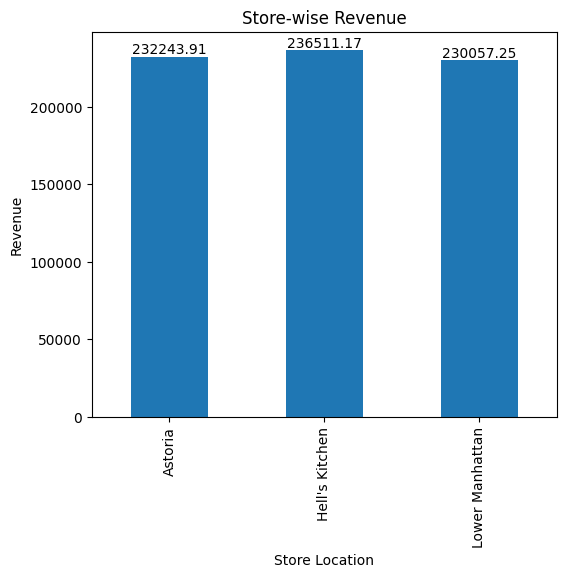

In [51]:
# plot store-wise revenue using bar chart
ax=store_revenue.plot(kind='bar',figsize=(6,5))
plt.title('Store-wise Revenue')
plt.xlabel('Store Location')
plt.ylabel('Revenue')
for container in ax.containers:
  ax.bar_label(container,fmt='%.2f')
plt.show()

In [52]:
#max strore revenue
print(store_revenue.idxmax(), store_revenue.max())


Hell's Kitchen 236511.17


In [53]:
#Total Quantity sold
total_quantity = df['transaction_qty'].sum()
print("Total Quantity:" ,total_quantity)

Total Quantity: 214470


In [54]:
store_quantity = df.groupby('store_location')['transaction_qty'].sum()
print(store_quantity)

store_location
Astoria            70991
Hell's Kitchen     71737
Lower Manhattan    71742
Name: transaction_qty, dtype: int64


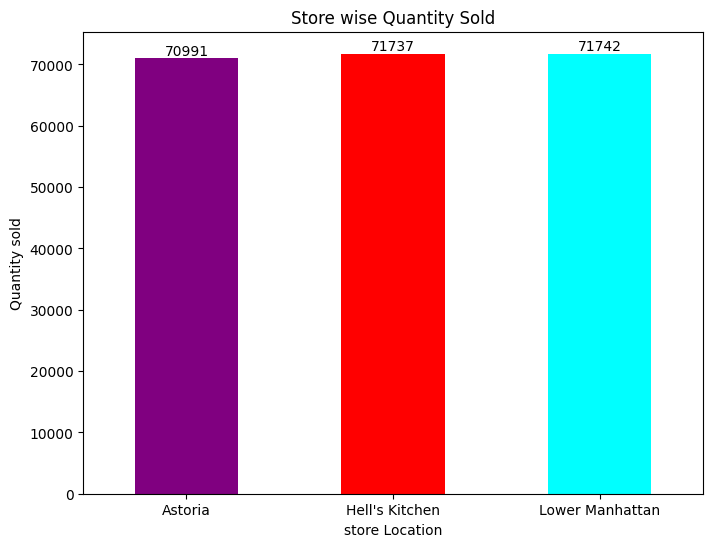

In [55]:
storewise_quantity=store_quantity.plot(kind='bar',figsize=(8,6),color=['purple','red','cyan'])
plt.title('Store wise Quantity Sold')
plt.xlabel('store Location')
plt.ylabel('Quantity sold')
plt.xticks(rotation=0)
for container in storewise_quantity.containers:
  storewise_quantity.bar_label(container)
plt.show()

In [56]:
#store-wise quantity sold and revenue earned
store_wise_revenue = df.groupby('store_location')[['transaction_qty','revenue',]].sum()
print(store_wise_revenue)

                 transaction_qty    revenue
store_location                             
Astoria                    70991  232243.91
Hell's Kitchen             71737  236511.17
Lower Manhattan            71742  230057.25


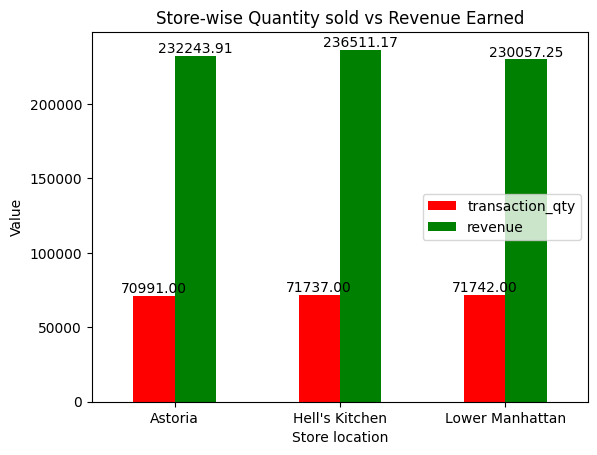

In [57]:
#plot store-wise quantity sold and earned revenue
store_summary = store_wise_revenue.plot(kind='bar',color=['red','Green'])
plt.title('Store-wise Quantity sold vs Revenue Earned')
plt.xlabel('Store location')
plt.ylabel('Value')
plt.xticks(rotation=0)
for container in store_summary.containers:
  store_summary.bar_label(container,fmt='%.2f')
plt.show()

In [58]:
#highest revenue store
print("highest quantity sold:",store_quantity.idxmax(),store_quantity.max())


highest quantity sold: Lower Manhattan 71742


In [59]:
print('Lowest quantity sold:',store_quantity.idxmin(),store_quantity.min())

Lowest quantity sold: Astoria 70991


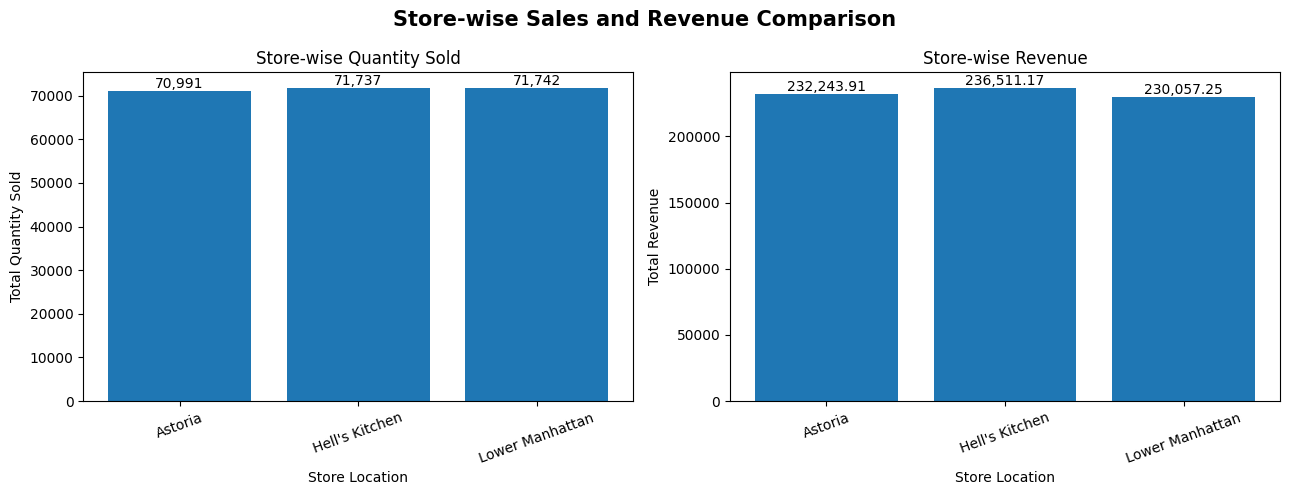

In [60]:
import matplotlib.pyplot as plt

# Store-wise aggregation
storewise_summary = df.groupby("store_location").agg(
    transaction_qty=("transaction_qty", "sum"),
    revenue=("revenue", "sum")
).reset_index()

# Create two clear comparison graphs
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Quantity comparison
bars1 = axes[0].bar(
    storewise_summary["store_location"],
    storewise_summary["transaction_qty"]
)

axes[0].set_title("Store-wise Quantity Sold")
axes[0].set_xlabel("Store Location")
axes[0].set_ylabel("Total Quantity Sold")
axes[0].tick_params(axis="x", rotation=20)

for bar in bars1:
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():,.0f}",
        ha="center",
        va="bottom"
    )

# Revenue comparison
bars2 = axes[1].bar(
    storewise_summary["store_location"],
    storewise_summary["revenue"]
)

axes[1].set_title("Store-wise Revenue")
axes[1].set_xlabel("Store Location")
axes[1].set_ylabel("Total Revenue")
axes[1].tick_params(axis="x", rotation=20)

for bar in bars2:
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():,.2f}",
        ha="center",
        va="bottom"
    )

plt.suptitle(
    "Store-wise Sales and Revenue Comparison",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [61]:
#PRODUCT BASED ANALYSIS

In [62]:
#product category-wise sales
category_sales = df.groupby('product_category')['transaction_qty'].sum().sort_values(ascending=False)
print(category_sales) # calculating transaction_qty sold for each category

product_category
Coffee                89250
Tea                   69737
Bakery                23214
Drinking Chocolate    17457
Flavours              10511
Coffee beans           1828
Loose Tea              1210
Branded                 776
Packaged Chocolate      487
Name: transaction_qty, dtype: int64


In [63]:
print("Highest selling product category:",category_sales.idxmax(),category_sales.max())

Highest selling product category: Coffee 89250


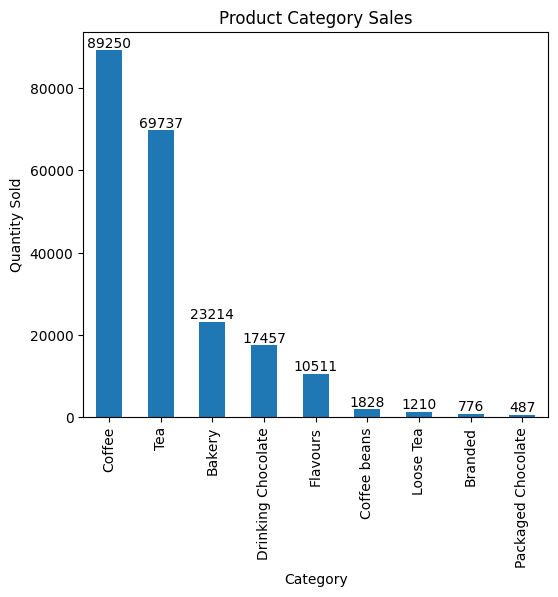

In [64]:
#plot category_sales using bar chart
c_sales = category_sales.plot(kind='bar',figsize=(6,5))
plt.title('Product Category Sales')
plt.xlabel('Category')
plt.ylabel('Quantity Sold')
for container in c_sales.containers:
  c_sales.bar_label(container)
plt.show()

In [65]:
#product type-wise sales
type_sales = df.groupby('product_type')['transaction_qty'].sum().sort_values(ascending=False)
print(type_sales)

product_type
Brewed Chai tea          26250
Gourmet brewed coffee    25973
Barista Espresso         24943
Brewed Black tea         17462
Hot chocolate            17457
Brewed herbal tea        17328
Organic brewed coffee    13012
Drip coffee              12891
Premium brewed coffee    12431
Scone                    10465
Brewed Green tea          8697
Regular syrup             7606
Pastry                    6961
Biscotti                  5788
Sugar free syrup          2905
Housewares                 555
Chai tea                   443
Organic Beans              420
Premium Beans              406
Gourmet Beans              366
Espresso Beans             319
Herbal tea                 305
Black tea                  303
Drinking Chocolate         266
Clothing                   221
Organic Chocolate          221
House blend Beans          183
Green tea                  159
Green beans                134
Name: transaction_qty, dtype: int64


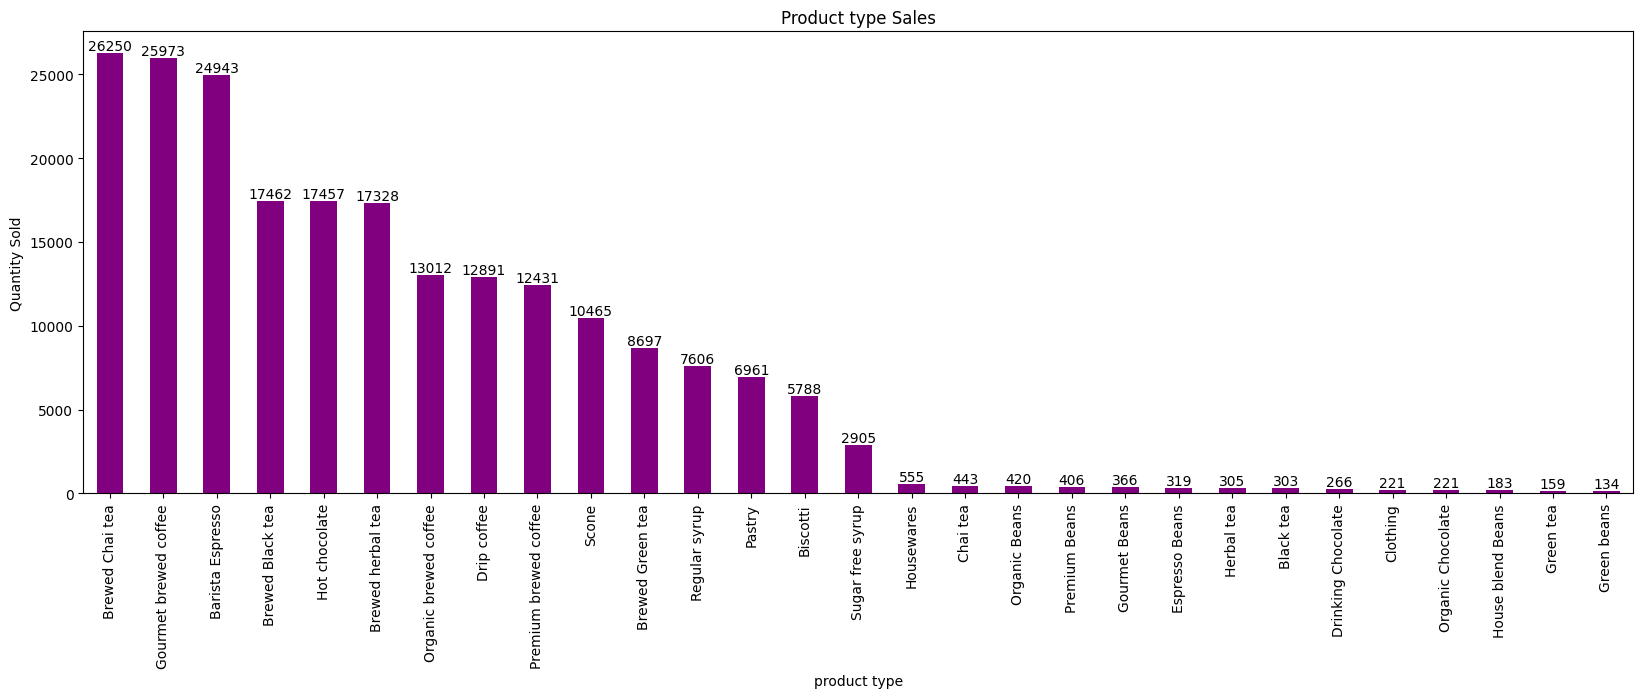

In [66]:
#bar chart product type sales
producttype_sales = type_sales.plot(kind='bar',figsize=(20,6),color='purple')
plt.title('Product type Sales')
plt.xlabel('product type')
plt.ylabel('Quantity Sold')
for container in producttype_sales.containers:
  producttype_sales.bar_label(container)
plt.show()

In [67]:
#product detail wise sales
detail_sales = df.groupby('product_detail')['transaction_qty'].sum().sort_values(ascending=False)
print(detail_sales)


product_detail
Earl Grey Rg                    4708
Dark chocolate Lg               4668
Morning Sunrise Chai Rg         4643
Latte                           4602
Peppermint Rg                   4564
                                ... 
Jamacian Coffee River            146
Earl Grey                        142
Guatemalan Sustainably Grown     134
Spicy Eye Opener Chai            122
Dark chocolate                   118
Name: transaction_qty, Length: 80, dtype: int64


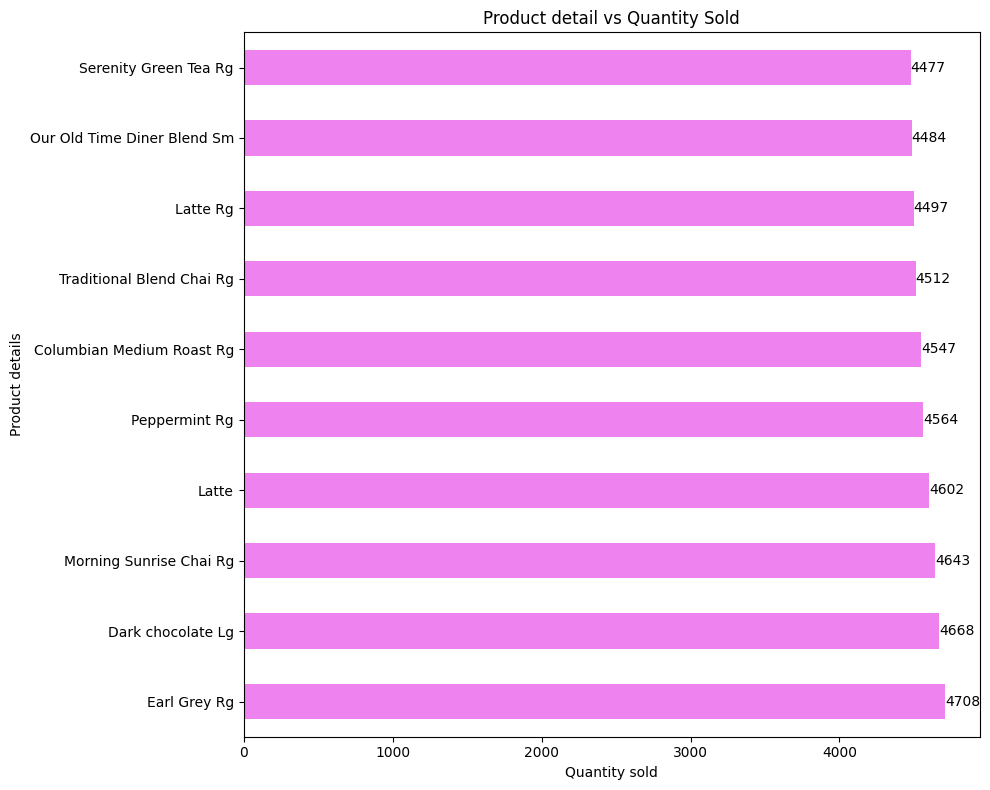

In [68]:
productdetail_sales = detail_sales.head(10).plot(kind='barh',figsize=(10,8),color='violet')
plt.title('Product detail vs Quantity Sold')
plt.xlabel('Quantity sold')
plt.ylabel('Product details')
for container in productdetail_sales.containers:
  productdetail_sales.bar_label(container,fmt='%.0f')
plt.tight_layout()
plt.show()

In [69]:
#productsummary analysis
product_summary = df.groupby(['product_category','product_type','product_detail'])['transaction_qty'].sum().reset_index().sort_values(by='transaction_qty',ascending=False)
print(product_summary.head(10))

      product_category           product_type               product_detail  \
65                 Tea       Brewed Black tea                 Earl Grey Rg   
45  Drinking Chocolate          Hot chocolate            Dark chocolate Lg   
69                 Tea        Brewed Chai tea      Morning Sunrise Chai Rg   
17              Coffee       Barista Espresso                        Latte   
79                 Tea      Brewed herbal tea                Peppermint Rg   
24              Coffee  Gourmet brewed coffee    Columbian Medium Roast Rg   
73                 Tea        Brewed Chai tea    Traditional Blend Chai Rg   
18              Coffee       Barista Espresso                     Latte Rg   
22              Coffee            Drip coffee  Our Old Time Diner Blend Sm   
75                 Tea       Brewed Green tea        Serenity Green Tea Rg   

    transaction_qty  
65             4708  
45             4668  
69             4643  
17             4602  
79             4564  
24       

/tmp/ipykernel_1345/4284178745.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top10['Category_Type']=top10['product_category'] + " | " + top10['product_type']


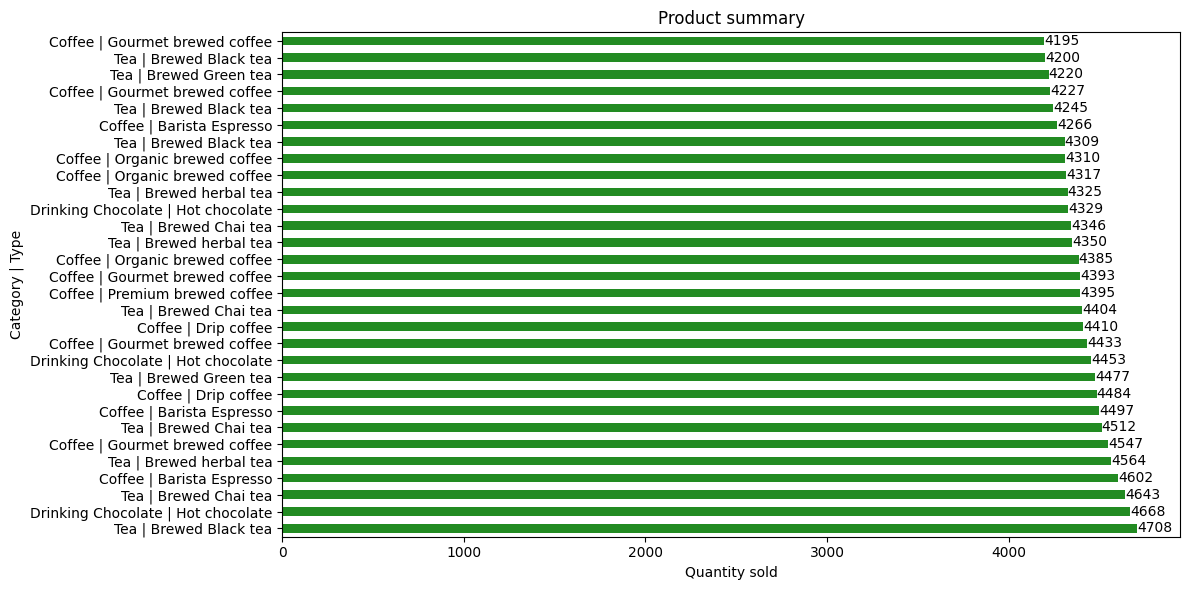

In [70]:
#plot the product summary analysis
top10 = product_summary.head(30)
top10['Category_Type']=top10['product_category'] + " | " + top10['product_type']
productSummary_analysis = top10.plot(x='Category_Type',y='transaction_qty',kind='barh',figsize=(12,6),color='forestgreen',legend=False)
plt.title('Product summary')
plt.xlabel('Quantity sold')
plt.ylabel('Category | Type')
for container in productSummary_analysis.containers:
  productSummary_analysis.bar_label(container,fmt='%.0f')
plt.tight_layout()
plt.show()

In [71]:
#store product summary
store_product_summary = (df.groupby(['store_location','product_category','product_type','product_detail'])['transaction_qty'].sum().reset_index())
print(store_product_summary)


      store_location product_category       product_type  \
0            Astoria           Bakery           Biscotti   
1            Astoria           Bakery           Biscotti   
2            Astoria           Bakery           Biscotti   
3            Astoria           Bakery             Pastry   
4            Astoria           Bakery             Pastry   
..               ...              ...                ...   
234  Lower Manhattan              Tea   Brewed Green tea   
235  Lower Manhattan              Tea  Brewed herbal tea   
236  Lower Manhattan              Tea  Brewed herbal tea   
237  Lower Manhattan              Tea  Brewed herbal tea   
238  Lower Manhattan              Tea  Brewed herbal tea   

              product_detail  transaction_qty  
0    Chocolate Chip Biscotti              652  
1            Ginger Biscotti              639  
2          Hazelnut Biscotti              664  
3           Almond Croissant              623  
4        Chocolate Croissant           

In [72]:
print(store_product_summary.idxmax(),store_product_summary.max())

store_location      159
product_category     63
product_type         51
product_detail       72
transaction_qty      98
dtype: int64 store_location                Lower Manhattan
product_category                          Tea
product_type                 Sugar free syrup
product_detail      Traditional Blend Chai Rg
transaction_qty                          1854
dtype: object


In [73]:
#get the top selling product of each store
top_product_each_store = store_product_summary.loc[store_product_summary.groupby('store_location')['transaction_qty'].idxmax()]
print(top_product_each_store)

      store_location    product_category       product_type  \
44           Astoria  Drinking Chocolate      Hot chocolate   
98    Hell's Kitchen              Coffee   Barista Espresso   
237  Lower Manhattan                 Tea  Brewed herbal tea   

           product_detail  transaction_qty  
44      Dark chocolate Lg             1755  
98   Ouro Brasileiro shot             1854  
237         Peppermint Lg             1582  


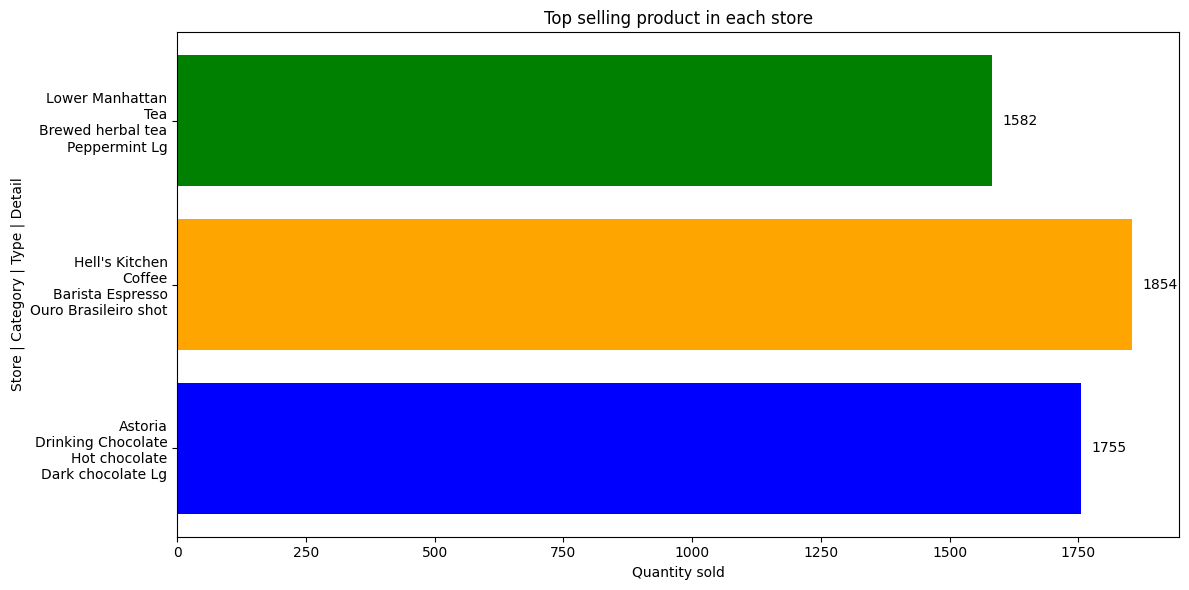

In [74]:
#TOP SELLING PRODUCT IN EACH STORE
labels=(top_product_each_store['store_location'] + '\n' +
top_product_each_store['product_category'] + '\n' +
top_product_each_store['product_type'] + '\n' +
top_product_each_store['product_detail'])
productSummaryStoreWise = plt.figure(figsize=(12,6))
plt.barh(labels,top_product_each_store['transaction_qty'],color=['blue','orange','green'])
plt.title('Top selling product in each store')
plt.xlabel('Quantity sold')
plt.ylabel('Store | Category | Type | Detail')
for i, v in enumerate(top_product_each_store['transaction_qty']):
  plt.text(v+20,i,str(v),va='center')
plt.tight_layout()
plt.show()

In [75]:
#REVENUE GENERATED BY THE TOP SELLING PRODUCT IN EACH STORE
store_product_revenue = (df.groupby(['store_location','product_category','product_type','product_detail'])['revenue'].sum().reset_index())
print(store_product_revenue)

      store_location product_category       product_type  \
0            Astoria           Bakery           Biscotti   
1            Astoria           Bakery           Biscotti   
2            Astoria           Bakery           Biscotti   
3            Astoria           Bakery             Pastry   
4            Astoria           Bakery             Pastry   
..               ...              ...                ...   
234  Lower Manhattan              Tea   Brewed Green tea   
235  Lower Manhattan              Tea  Brewed herbal tea   
236  Lower Manhattan              Tea  Brewed herbal tea   
237  Lower Manhattan              Tea  Brewed herbal tea   
238  Lower Manhattan              Tea  Brewed herbal tea   

              product_detail  revenue  
0    Chocolate Chip Biscotti  2282.00  
1            Ginger Biscotti  2236.50  
2          Hazelnut Biscotti  2158.00  
3           Almond Croissant  2336.25  
4        Chocolate Croissant  3836.25  
..                       ...      ...  

In [76]:
top_revenue_product = store_product_revenue.loc[store_product_revenue.groupby('store_location')['revenue'].idxmax()]
print(top_revenue_product)

      store_location    product_category   product_type     product_detail  \
44           Astoria  Drinking Chocolate  Hot chocolate  Dark chocolate Lg   
122   Hell's Kitchen        Coffee beans  Premium Beans          Civet Cat   
204  Lower Manhattan  Drinking Chocolate  Hot chocolate  Dark chocolate Lg   

     revenue  
44    7897.5  
122   7380.0  
204   6574.5  


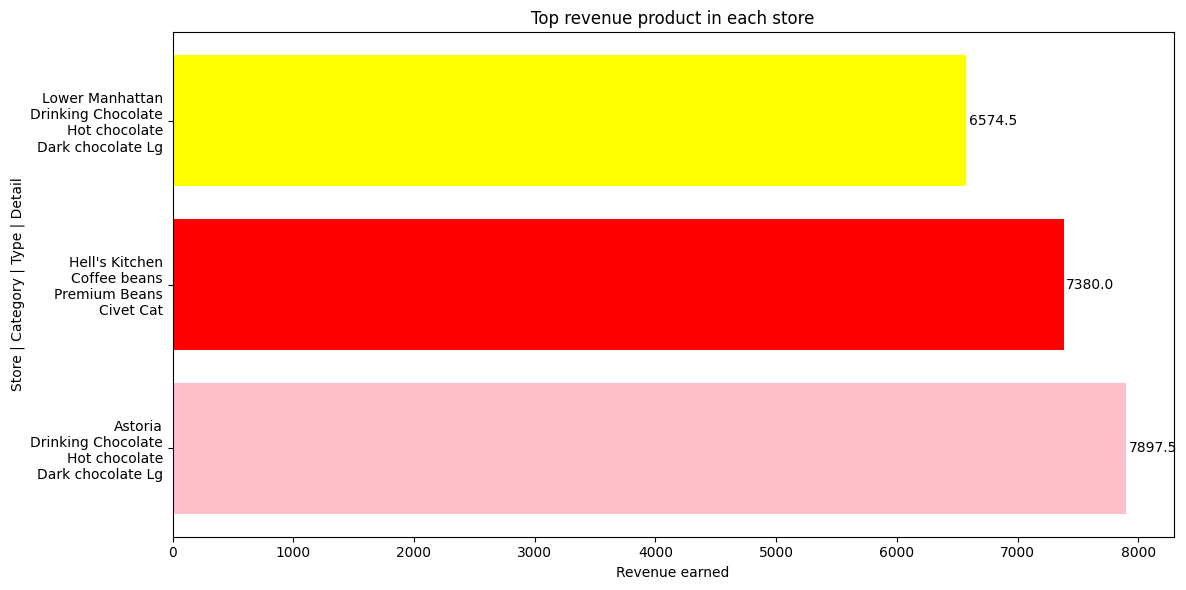

In [77]:
labels=(top_revenue_product['store_location'] + '\n' +
top_revenue_product['product_category'] + '\n' +
top_revenue_product['product_type'] + '\n' +
top_revenue_product['product_detail'])
toprevenueproduct_analysis = plt.figure(figsize=(12,6))
plt.barh(labels,top_revenue_product['revenue'],color=['pink','red','yellow'])
plt.title('Top revenue product in each store')
plt.xlabel('Revenue earned')
plt.ylabel('Store | Category | Type | Detail')
for i, v in enumerate(top_revenue_product['revenue']):
  plt.text(v+20,i,str(v),va='center')
plt.tight_layout()
plt.show()

In [78]:
#store sales
store_sales = df.groupby('store_location')['transaction_qty'].sum()
print(store_sales)

store_location
Astoria            70991
Hell's Kitchen     71737
Lower Manhattan    71742
Name: transaction_qty, dtype: int64


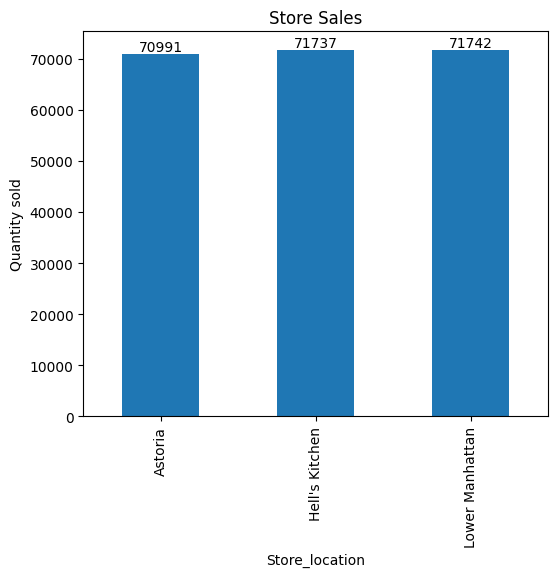

In [79]:
#plot store sales store-wise quantity sold
s_sales = store_sales.plot(kind='bar',figsize=(6,5))
plt.title('Store Sales')
plt.xlabel('Store_location')
plt.ylabel('Quantity sold')
for container in s_sales.containers:
  s_sales.bar_label(container)
plt.show()

In [80]:
#HOURLY SALES BASED ON QUANTITY AND REVENUE
hourly_sales = df.groupby('hour')[['transaction_qty','revenue']].sum()
print(hourly_sales)

      transaction_qty   revenue
hour                           
6                6865  21900.27
7               19449  63526.47
8               25197  82699.87
9               25370  85169.53
10              26733  88742.39
11              14015  46250.14
12              12690  40192.79
13              12443  40377.55
14              12903  41294.64
15              12923  41733.10
16              12888  41143.25
17              12693  40113.81
18              10826  34286.20
19               8599  28456.68
20                876   2925.64


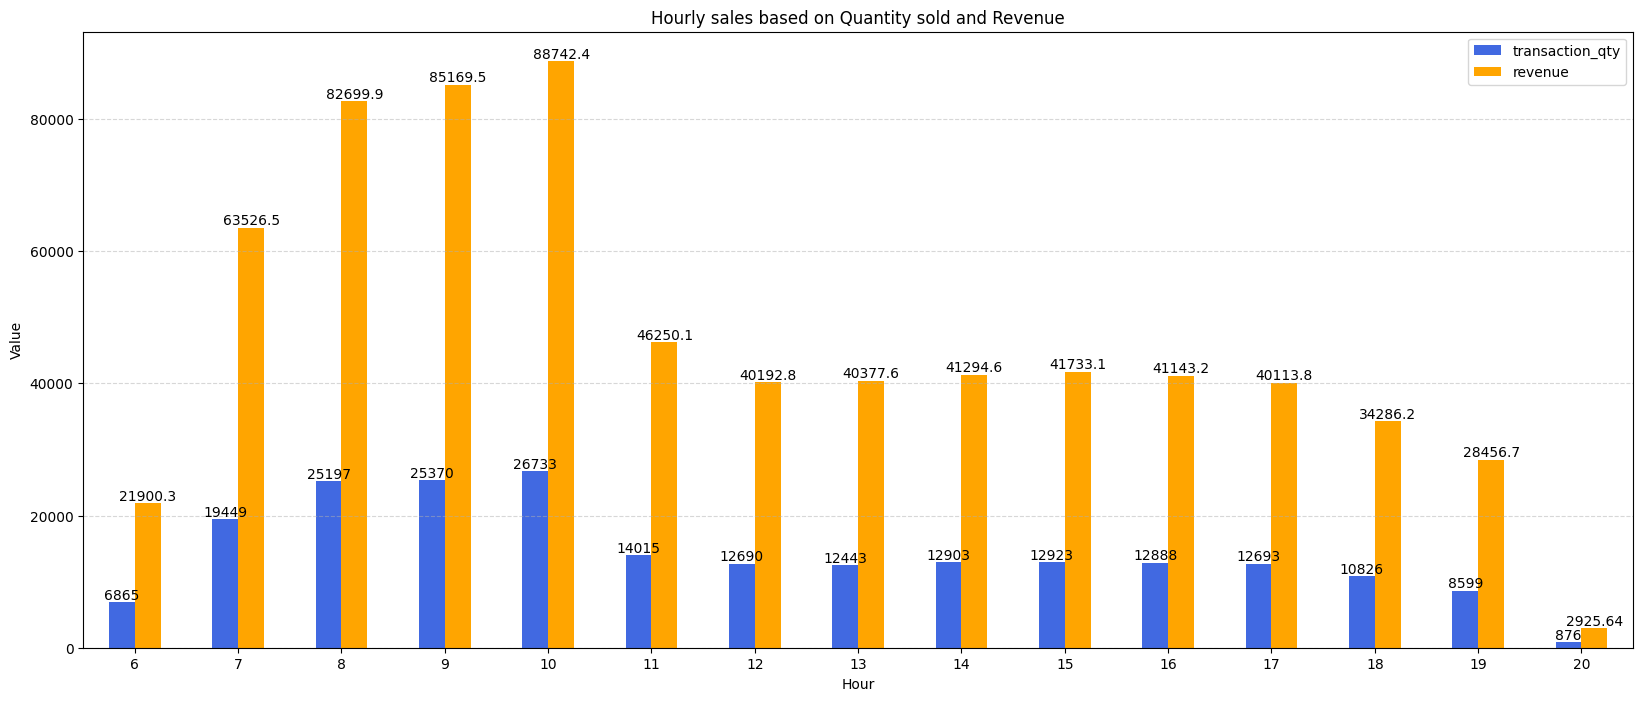

In [81]:
#hourly sales based on transaction_qty and revenue
h=hourly_sales.plot(kind='bar',figsize=(20,8),color=['royalblue','orange'])
plt.title('Hourly sales based on Quantity sold and Revenue')
plt.xlabel('Hour')
plt.ylabel('Value')
plt.xticks(rotation=0)
plt.grid(axis='y',linestyle='--',alpha=0.5)
for container in h.containers:
  h.bar_label(container)
plt.show()

In [82]:
# HOURLY STORE SALES ACROSS STORE LOCATIONS
hourly_store_sales = df.groupby(['hour','store_location'])[['transaction_qty','revenue']].sum()
print(hourly_store_sales)

                      transaction_qty   revenue
hour store_location                            
6    Hell's Kitchen              2349   7531.17
     Lower Manhattan             4516  14369.10
7    Astoria                     5865  19028.80
     Hell's Kitchen              4734  15961.05
     Lower Manhattan             8850  28536.62
8    Astoria                     6756  22805.90
     Hell's Kitchen              9653  31544.44
     Lower Manhattan             8788  28349.53
9    Astoria                     7055  23183.57
     Hell's Kitchen              9393  32874.29
     Lower Manhattan             8922  29111.67
10   Astoria                     7396  24456.12
     Hell's Kitchen              9876  33613.31
     Lower Manhattan             9461  30672.96
11   Astoria                     4884  15468.13
     Hell's Kitchen              5050  17919.04
     Lower Manhattan             4081  12862.97
12   Astoria                     4955  15681.20
     Hell's Kitchen              3544  1

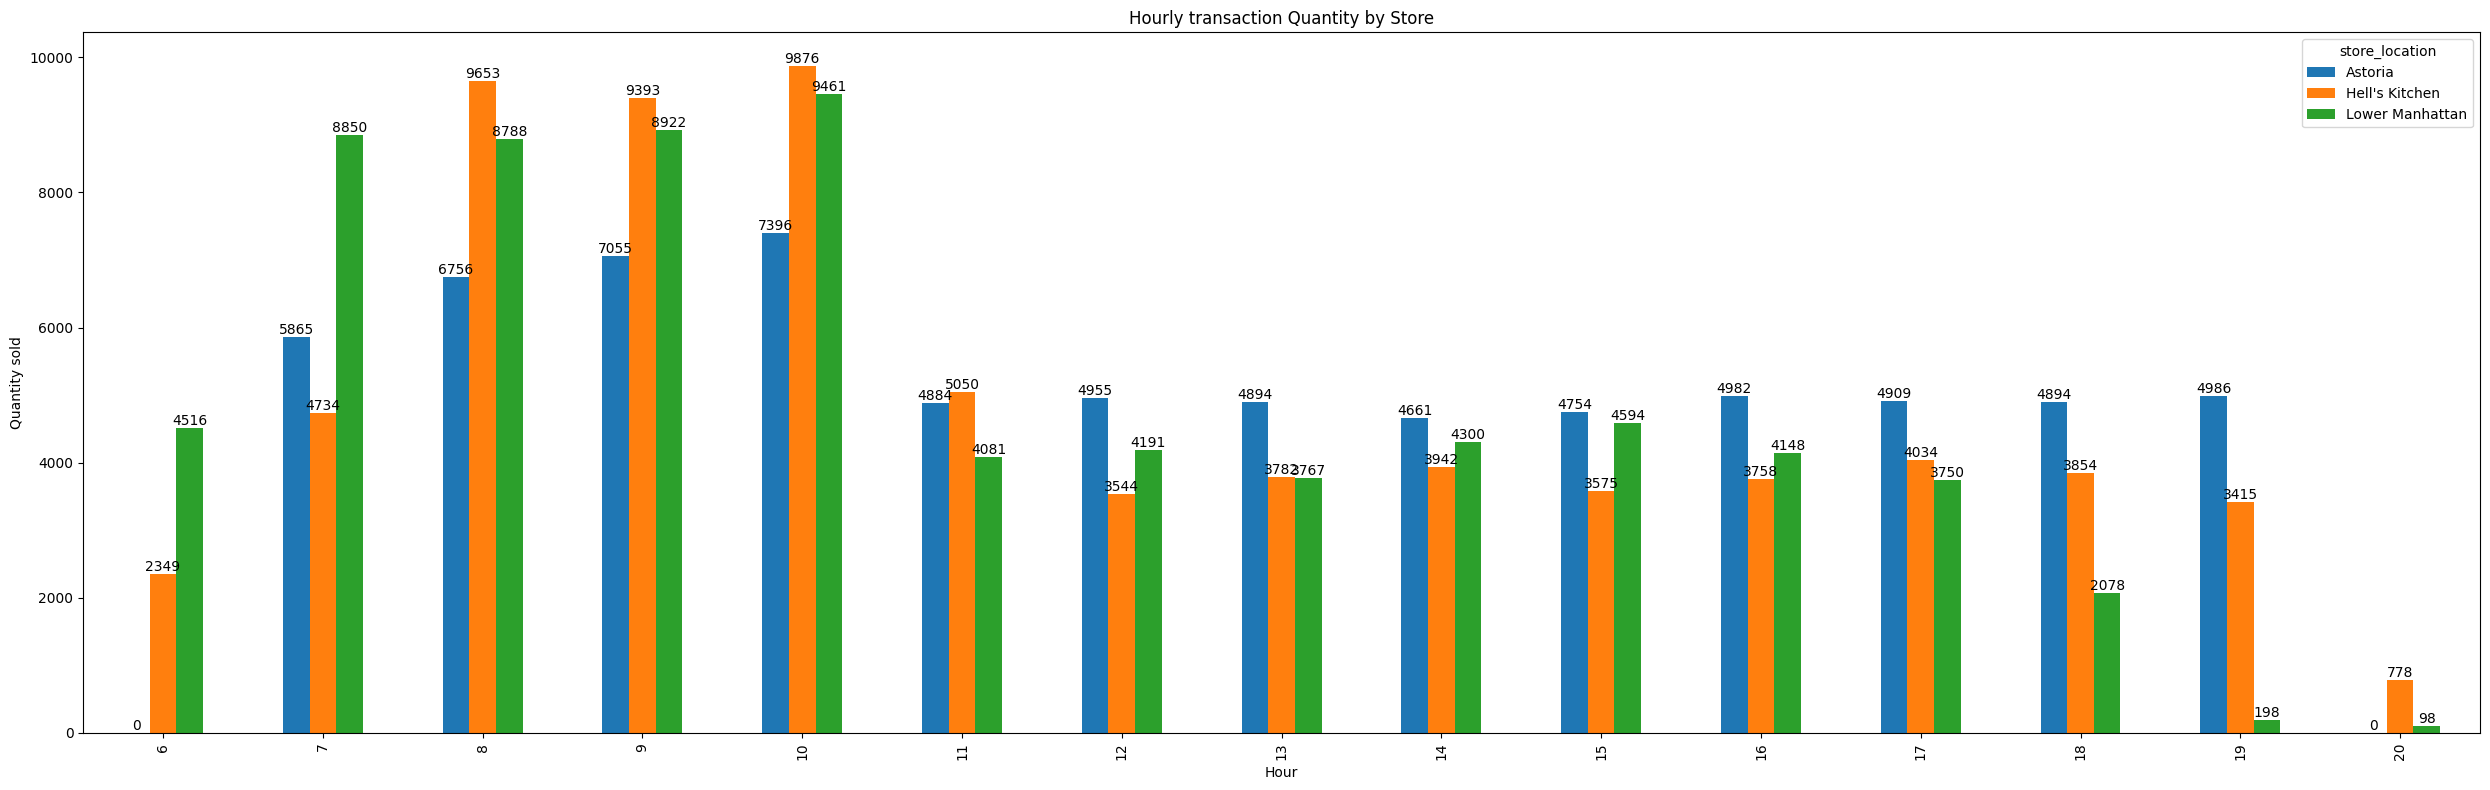

In [83]:
#PLOT HOURLY BASED SALES ACROSS STORE LOCATIONS
#plot hourly trnsaction quantity by store
hourly_store_sales_qty = df.groupby(['hour','store_location'])['transaction_qty'].sum().unstack()
ax=hourly_store_sales_qty.plot(kind='bar',figsize=(25,8))
plt.title('Hourly transaction Quantity by Store')
plt.xlabel('Hour')
plt.ylabel('Quantity sold')
for container in ax.containers:
  ax.bar_label(container,fontsize=10,fontstyle='normal')
plt.tight_layout()
plt.show()

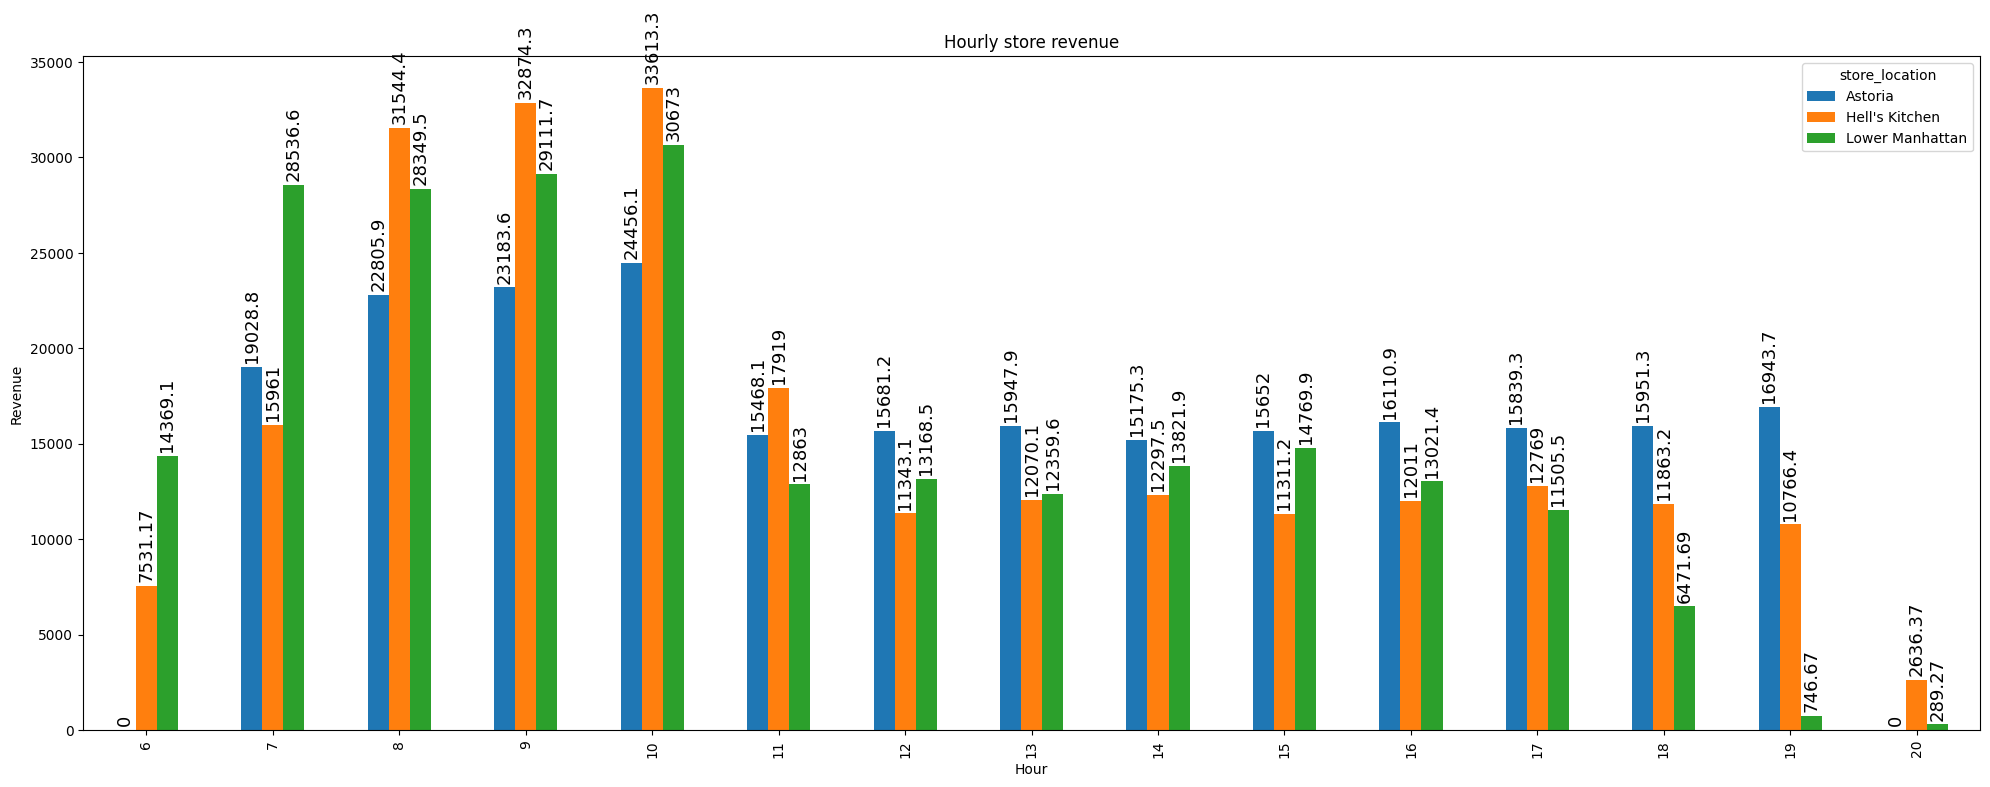

In [84]:
#PLOT HOURLY BASED SALES ACROSS STORE LOCATIONS
#plot hourly trnsaction quantity by revenue
hourly_store_sales_rev = df.groupby(['hour','store_location'])['revenue'].sum().unstack()
ax=hourly_store_sales_rev.plot(kind='bar',figsize=(20,8))
plt.title('Hourly store revenue')
plt.xlabel('Hour')
plt.ylabel('Revenue')
for container in ax.containers:
  ax.bar_label(container,fontsize=13,padding=3,rotation=90)
plt.tight_layout()
plt.show()

In [85]:
#Busiest hour based on transaction qty
busiest_hour_qty = hourly_sales['transaction_qty'].idxmax()
print(busiest_hour_qty)
busiest_data = df[df['hour']==busiest_hour_qty]

10


In [86]:
#Busiest hour based on revenue
busiest_hour_rev = hourly_sales['revenue'].idxmax()
print(busiest_hour_rev)
busiest_data = df[df['hour']==busiest_hour_rev]

10


In [87]:
#Quantity and revenue by store
store_sales = busiest_data.groupby('store_location')[['transaction_qty','revenue']].sum()
print(store_sales)
print('Highest selling store at busiest hour:',store_sales.idxmax())

                 transaction_qty   revenue
store_location                            
Astoria                     7396  24456.12
Hell's Kitchen              9876  33613.31
Lower Manhattan             9461  30672.96
Highest selling store at busiest hour: transaction_qty    Hell's Kitchen
revenue            Hell's Kitchen
dtype: object


In [88]:
#sales by store , category , type and detail during busiest hour
sales_summary= busiest_data.groupby(['store_location','product_category','product_type','product_detail'])[['transaction_qty','revenue']].sum()
print(sales_summary)

                                                                            transaction_qty  \
store_location  product_category product_type      product_detail                             
Astoria         Bakery           Biscotti          Chocolate Chip Biscotti               65   
                                                   Ginger Biscotti                       54   
                                                   Hazelnut Biscotti                     76   
                                 Pastry            Almond Croissant                      70   
                                                   Chocolate Croissant                  135   
...                                                                                     ...   
Lower Manhattan Tea              Brewed Green tea  Serenity Green Tea Rg                191   
                                 Brewed herbal tea Lemon Grass Lg                       158   
                                                  

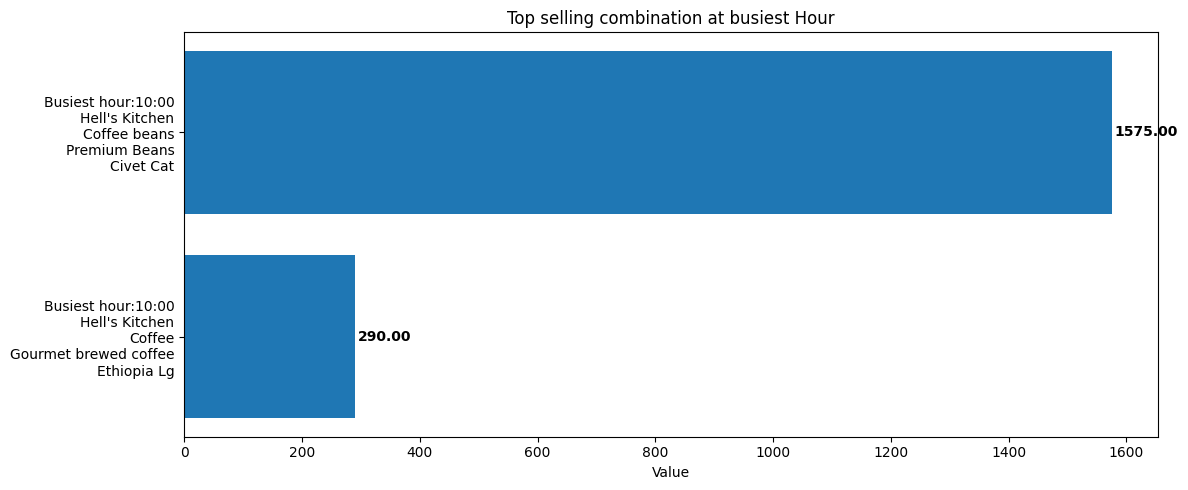

In [89]:
qty_result=sales_summary['transaction_qty'].idxmax()
rev_result=sales_summary['revenue'].idxmax()
max_qty = sales_summary['transaction_qty'].max()
max_rev=sales_summary['revenue'].max()
#plot the Highest quantity sold and revenue earned
labels=["\n".join([f"Busiest hour:{busiest_hour_qty}:00",*map(str,qty_result)]),"\n".join([f"Busiest hour:{busiest_hour_rev}:00",*map(str,rev_result)])]

values=[max_qty,max_rev]
plt.figure(figsize=(12,5))
bars=plt.barh(['Highest Quantity Sold','Highest Revenue'],values)
plt.title('Top selling combination at busiest Hour')
plt.xlabel('Value')
for bar in bars:
  plt.text(bar.get_width() + 5,bar.get_y() + bar.get_height()/2,f'{bar.get_width():.2f}',va='center',fontweight='bold' )
  plt.yticks([0,1],labels)
plt.tight_layout()
plt.show()

In [90]:
#BUSIEST HOUR SALES PLOT USING SUNBURST CHART
#CREATE SUMMARY TABLE
sunburst_data_qty = busiest_data.groupby(['store_location','product_category','product_type','product_detail'])['transaction_qty'].sum().reset_index()
#plot sunburst chart(Quantity sold)

fig=px.sunburst(sunburst_data_qty,path=['store_location','product_category','product_type','product_detail'],
                values='transaction_qty',title='Product Hierarchy at busiest hour(Quantity sold)',
                width=1000,
                height=800)
fig.show()

In [91]:
#CREATE SUMMARY TABLE
sunburst_data_rev = busiest_data.groupby(['store_location','product_category','product_type','product_detail'])['revenue'].sum().reset_index()
#plot sunburst chart(revenue)

fig=px.sunburst(sunburst_data_rev,path=['store_location','product_category','product_type','product_detail'],
                values='revenue',color='store_location',title='Product Hierarchy at busiest hour(revenue)')
fig.update_layout(width=1000,height=800)

fig.show()

                  transaction_qty  revenue
transaction_date                          
2023-01-01                    802  2508.20
2023-01-02                    790  2403.35
2023-01-03                    823  2565.00
2023-01-04                    726  2220.10
2023-01-05                    778  2418.85
                  transaction_qty  revenue
transaction_date                          
2023-06-26                   1837  5875.90
2023-06-27                   1962  5975.65
2023-06-28                   1531  4728.90
2023-06-29                   1429  4450.75
2023-06-30                   1590  5481.32


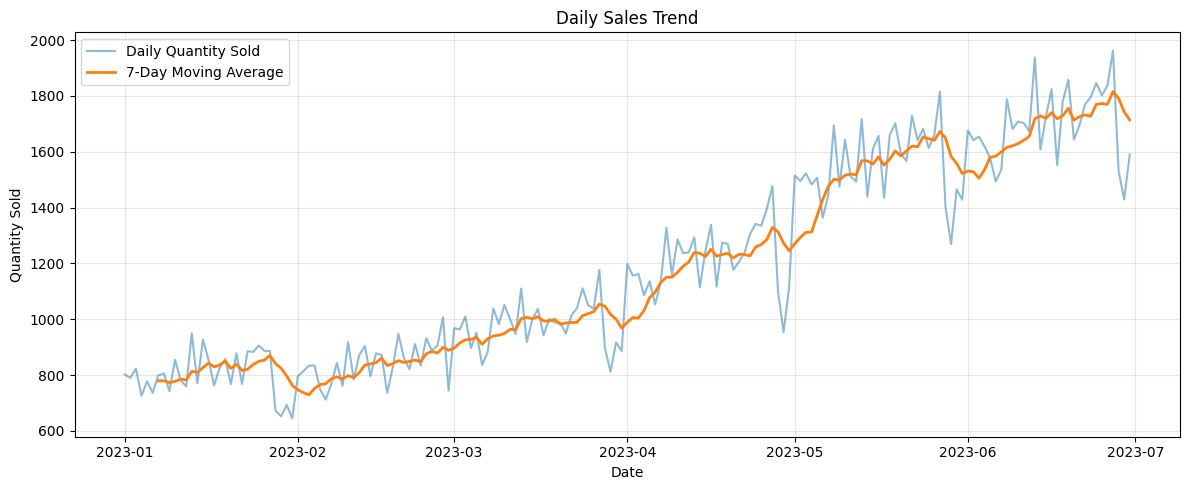

In [92]:
#DAILY SALES TREND
import pandas as pd
import matplotlib.pyplot as plt

# Convert transaction_date to datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Daily quantity sold
daily_sales = df.groupby('transaction_date').agg(transaction_qty =('transaction_qty','sum'),revenue = ('revenue','sum'))
daily_sales = daily_sales.sort_index()
print(daily_sales.head())
print(daily_sales.tail())

# 7-day moving average
daily_sales_avg = daily_sales.rolling(window=7).mean()

# Plot
plt.figure(figsize=(12, 5))

plt.plot(daily_sales.index, daily_sales['transaction_qty'],
         label='Daily Quantity Sold', alpha=0.5)

plt.plot(daily_sales_avg.index, daily_sales_avg['transaction_qty'],
         label='7-Day Moving Average', linewidth=2)

plt.title('Daily Sales Trend')
plt.xlabel('Date')
plt.ylabel('Quantity Sold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [93]:
# Convert transaction date to datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Create daily quantity and revenue
daily_sales = df.groupby('transaction_date').agg(
    transaction_qty=('transaction_qty', 'sum'),
    revenue=('revenue', 'sum')
)

# Make sure dates are sorted
daily_sales = daily_sales.sort_index()

print(daily_sales.head())
print(daily_sales.columns)

                  transaction_qty  revenue
transaction_date                          
2023-01-01                    802  2508.20
2023-01-02                    790  2403.35
2023-01-03                    823  2565.00
2023-01-04                    726  2220.10
2023-01-05                    778  2418.85
Index(['transaction_qty', 'revenue'], dtype='object')


In [94]:
#Best Selling day
print(f"Highest Quantity day:{daily_sales.idxmax()}")
daily_revenue = df.groupby('transaction_date')['revenue'].sum()
print(f"Highest Revenue day:{daily_revenue.idxmax()}")

Highest Quantity day:transaction_qty   2023-06-27
revenue           2023-06-19
dtype: datetime64[ns]
Highest Revenue day:2023-06-19 00:00:00


In [95]:
#Create Weekday Column
df['day_name']=df['transaction_date'].dt.day_name()
df['day_name']

,day_name
0,Sunday
1,Sunday
2,Sunday
3,Sunday
4,Sunday
...,...
149111,Friday
149112,Friday
149113,Friday
149114,Friday


In [96]:
#WEEKDAY SALES
weekday_sales=df.groupby('day_name')[['transaction_qty','revenue']].sum()
print(weekday_sales)

           transaction_qty    revenue
day_name                             
Friday               31207  101373.00
Monday               31231  101677.28
Saturday             29614   96894.48
Sunday               30182   98330.31
Thursday             31162  100767.78
Tuesday              30449   99455.94
Wednesday            30625  100313.54


In [97]:
order =['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekday_sales = weekday_sales.reindex(order)

In [98]:
print(weekday_sales)

           transaction_qty    revenue
day_name                             
Monday               31231  101677.28
Tuesday              30449   99455.94
Wednesday            30625  100313.54
Thursday             31162  100767.78
Friday               31207  101373.00
Saturday             29614   96894.48
Sunday               30182   98330.31


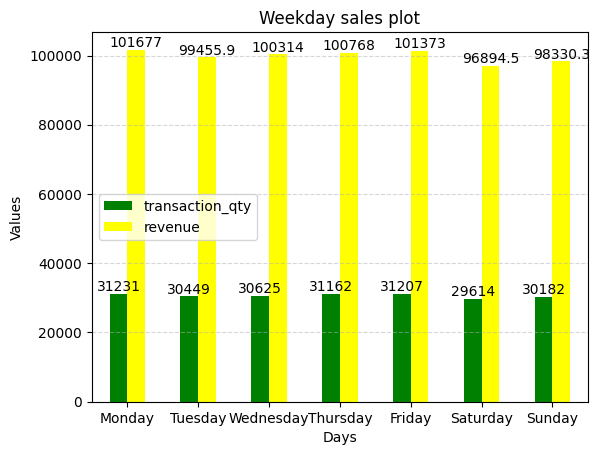

In [99]:
#weekday sales plot
weekday_sales_plot=weekday_sales.plot(kind='bar',color=['green','yellow'])
plt.title('Weekday sales plot')
plt.xlabel('Days')
plt.ylabel('Values')
plt.xticks(rotation=0)
plt.grid(axis='y',linestyle='--',alpha=0.5)
for container in weekday_sales_plot.containers:
  weekday_sales_plot.bar_label(container,fontsize=10)
plt.show()

In [100]:
# CREATE WEEKEND COLUMN
df['day_type']=df['day_name'].apply(lambda x:'Weekend'
if x in ['Saturday','Sunday']
                                       else 'Weekday'
                                       )

In [101]:
df['day_type']

,day_type
0,Weekend
1,Weekend
2,Weekend
3,Weekend
4,Weekend
...,...
149111,Weekday
149112,Weekday
149113,Weekday
149114,Weekday


In [102]:
#COMPARE WEEKEND AND WEEKDAY SALES
day_type_sales = df.groupby('day_type')[['transaction_qty','revenue']].sum()
print(day_type_sales)

          transaction_qty    revenue
day_type                            
Weekday            154674  503587.54
Weekend             59796  195224.79


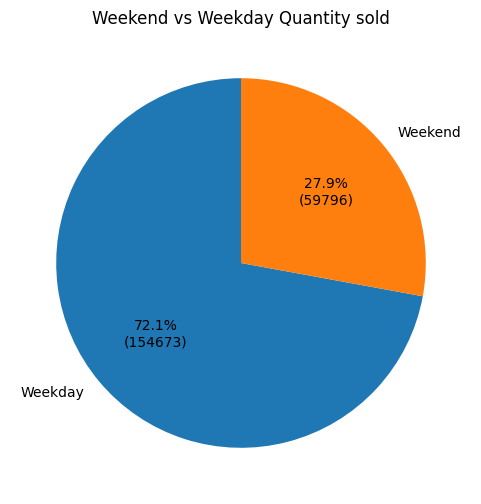

In [103]:
#PIE CHART FOR WEEKDAY SALES AND WEEKEND SALES
values=day_type_sales['transaction_qty']
plt.figure(figsize=(6,6))
plt.pie(values,labels=day_type_sales.index,autopct=lambda p:f'{p:.1f}%\n({int(p/100*values.sum())})',startangle=90)
plt.title("Weekend vs Weekday Quantity sold")
plt.show()

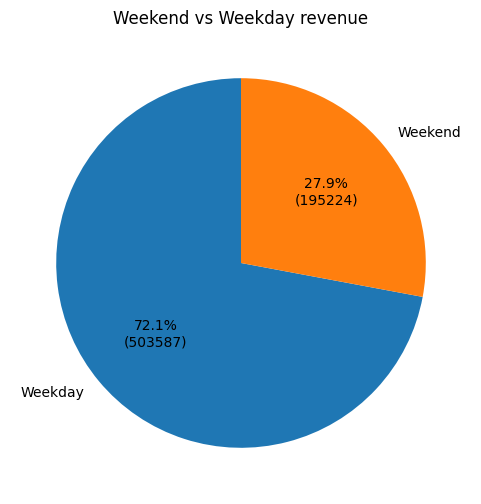

In [104]:
#PIE CHART FOR WEEKDAY SALES AND WEEKEND SALES
values=day_type_sales['revenue']
plt.figure(figsize=(6,6))
plt.pie(values,labels=day_type_sales.index,autopct=lambda p:f'{p:.1f}%\n({int(p/100*values.sum())})',startangle=90)
plt.title("Weekend vs Weekday revenue")
plt.show()

In [105]:
#HIGHEST SELLING STORE ON WEEKDAYS
weekday_highest_store = df[df['day_type']=='Weekday']
store =weekday_highest_store.groupby(['store_location','product_category'])[['transaction_qty','revenue']].sum()
print("weekdays Highest store and product sold based on quantity sold:",store['transaction_qty'].idxmax())
print("weekdays Highest store and product sold based on revenue:",store['revenue'].idxmax())

weekdays Highest store and product sold based on quantity sold: ("Hell's Kitchen", 'Coffee')
weekdays Highest store and product sold based on revenue: ("Hell's Kitchen", 'Coffee')


In [106]:
#HIGHEST SELLING STORE ON WEEKEND
weekend_highest_store = df[df['day_type']=='Weekend']
store =weekend_highest_store.groupby(['store_location','product_category'])[['transaction_qty','revenue']].sum()
print("weekend sales based on quantity sold:",store['transaction_qty'].idxmax())
print("weekend sales based on revenue:",store['revenue'].idxmax())

weekend sales based on quantity sold: ("Hell's Kitchen", 'Coffee')
weekend sales based on revenue: ("Hell's Kitchen", 'Coffee')


In [107]:
#2.PEAK DAY SALES
#peak day sales based on quantity sold
peak_qty_day = daily_sales.idxmax()
peak_qty = daily_sales.max()
print("peak sales day:", peak_qty_day)
print("Quantity sold:", peak_qty)


peak sales day: transaction_qty   2023-06-27
revenue           2023-06-19
dtype: datetime64[ns]
Quantity sold: transaction_qty    1962.00
revenue            6403.91
dtype: float64


In [108]:
#2.peak day sales based on revenue
peak_rev_day = daily_sales.idxmax()
peak_rev = daily_sales.max()
print("peak sales day:", peak_rev_day)
print("Quantity sold:", peak_rev)

peak sales day: transaction_qty   2023-06-27
revenue           2023-06-19
dtype: datetime64[ns]
Quantity sold: transaction_qty    1962.00
revenue            6403.91
dtype: float64


In [109]:
#preparing data for forecasting
#Aggregate sales data
daily_sales.reset_index()

,transaction_date,transaction_qty,revenue
0,2023-01-01,802,2508.20
1,2023-01-02,790,2403.35
2,2023-01-03,823,2565.00
3,2023-01-04,726,2220.10
4,2023-01-05,778,2418.85
...,...,...,...
176,2023-06-26,1837,5875.90
177,2023-06-27,1962,5975.65
178,2023-06-28,1531,4728.90
179,2023-06-29,1429,4450.75


In [110]:
daily_sales.head()

,transaction_qty,revenue
transaction_date,,
2023-01-01,802,2508.20
2023-01-02,790,2403.35
2023-01-03,823,2565.00
2023-01-04,726,2220.10
2023-01-05,778,2418.85


In [111]:
#split into training and testing data
train = daily_sales[:-30]
test=daily_sales[-30:]


In [112]:
print(train.head())

                  transaction_qty  revenue
transaction_date                          
2023-01-01                    802  2508.20
2023-01-02                    790  2403.35
2023-01-03                    823  2565.00
2023-01-04                    726  2220.10
2023-01-05                    778  2418.85


In [113]:
print(daily_sales)

                  transaction_qty  revenue
transaction_date                          
2023-01-01                    802  2508.20
2023-01-02                    790  2403.35
2023-01-03                    823  2565.00
2023-01-04                    726  2220.10
2023-01-05                    778  2418.85
...                           ...      ...
2023-06-26                   1837  5875.90
2023-06-27                   1962  5975.65
2023-06-28                   1531  4728.90
2023-06-29                   1429  4450.75
2023-06-30                   1590  5481.32

[181 rows x 2 columns]


In [114]:
# ============================================
# DAILY SALES - FEATURE ENGINEERING
# ============================================

# Make sure transaction date is datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Create daily quantity AND daily revenue
daily_sales = (
    df.groupby('transaction_date')
      .agg(
          transaction_qty=('transaction_qty', 'sum'),
          revenue=('revenue', 'sum')
      )
      .sort_index()
)

# Time-based features
daily_sales['Day'] = daily_sales.index.day
daily_sales['Month'] = daily_sales.index.month
daily_sales['Weekday'] = daily_sales.index.dayofweek

# Lag features based on quantity
daily_sales['lag_1'] = daily_sales['transaction_qty'].shift(1)
daily_sales['lag_7'] = daily_sales['transaction_qty'].shift(7)
daily_sales['lag_30'] = daily_sales['transaction_qty'].shift(30)

# Rolling features
daily_sales['rolling_3'] = daily_sales['transaction_qty'].rolling(3).mean()
daily_sales['rolling_7'] = daily_sales['transaction_qty'].rolling(7).mean()

# Remove rows created with missing lag/rolling values
daily_sales = daily_sales.dropna()

print(daily_sales.head())
print("\nColumns:")
print(daily_sales.columns)
print("\nShape:")
print(daily_sales.shape)

                  transaction_qty  revenue  Day  Month  Weekday  lag_1  lag_7  \
transaction_date                                                                
2023-01-31                    645  2334.13   31      1        1  693.0  883.0   
2023-02-01                    796  2466.30    1      2        2  645.0  906.0   
2023-02-02                    814  2506.90    2      2        3  796.0  887.0   
2023-02-03                    834  2591.45    3      2        4  814.0  886.0   
2023-02-04                    834  2551.70    4      2        5  834.0  672.0   

                  lag_30   rolling_3   rolling_7  
transaction_date                                  
2023-01-31         802.0  663.333333  763.000000  
2023-02-01         790.0  711.333333  747.285714  
2023-02-02         823.0  751.666667  736.857143  
2023-02-03         726.0  814.666667  729.428571  
2023-02-04         778.0  827.333333  752.571429  

Columns:
Index(['transaction_qty', 'revenue', 'Day', 'Month', 'Weekday', '

In [115]:
train = daily_sales.iloc[:-30].copy()
test = daily_sales.iloc[-30:].copy()
print('Train shape',train.shape)
print('Test shape',test.shape)
print(train.columns)

Train shape (121, 10)
Test shape (30, 10)
Index(['transaction_qty', 'revenue', 'Day', 'Month', 'Weekday', 'lag_1',
       'lag_7', 'lag_30', 'rolling_3', 'rolling_7'],
      dtype='object')


In [116]:
#creating features of day, month for linear regression model
X_train_daily = train[['Day','Month','Weekday','lag_1','lag_7','lag_30','rolling_3','rolling_7']]
Y_train_daily = train['transaction_qty']

x_test_daily = test[['Day','Month','Weekday','lag_1','lag_7','lag_30','rolling_3','rolling_7']]
y_test_daily = test['transaction_qty']

In [117]:
print(train.columns)

Index(['transaction_qty', 'revenue', 'Day', 'Month', 'Weekday', 'lag_1',
       'lag_7', 'lag_30', 'rolling_3', 'rolling_7'],
      dtype='object')


In [118]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error


In [119]:
gb_daily_model = GradientBoostingRegressor(n_estimators=100,learning_rate=0.1,max_depth=3,random_state=42)

In [120]:
gb_daily_model.fit(X_train_daily,Y_train_daily)

GradientBoostingRegressor(random_state=42)

In [121]:
#Predict the sales for test data
daily_pred = gb_daily_model.predict(x_test_daily)
print(daily_pred)

[1635.74706671 1657.04394663 1657.72680854 1682.13202332 1709.58391438
 1622.80835447 1633.78859765 1695.5630741  1699.83452807 1723.41217906
 1734.35850499 1755.7281918  1757.72040666 1743.78343876 1714.35846554
 1725.2794625  1725.29802682 1738.76958738 1751.68065815 1725.30163859
 1757.64936629 1716.63325418 1720.75723156 1748.20541981 1705.50865501
 1723.37370043 1785.02786664 1667.52592835 1583.76392275 1523.55872118]


In [122]:
#compare actual sales vs predicted sales
comparision = test[['transaction_qty']].copy()
comparision['Predicted_Qty'] = daily_pred
print(comparision.head(10))

                  transaction_qty  Predicted_Qty
transaction_date                                
2023-06-01                   1676    1635.747067
2023-06-02                   1642    1657.043947
2023-06-03                   1654    1657.726809
2023-06-04                   1619    1682.132023
2023-06-05                   1577    1709.583914
2023-06-06                   1494    1622.808354
2023-06-07                   1536    1633.788598
2023-06-08                   1788    1695.563074
2023-06-09                   1682    1699.834528
2023-06-10                   1708    1723.412179


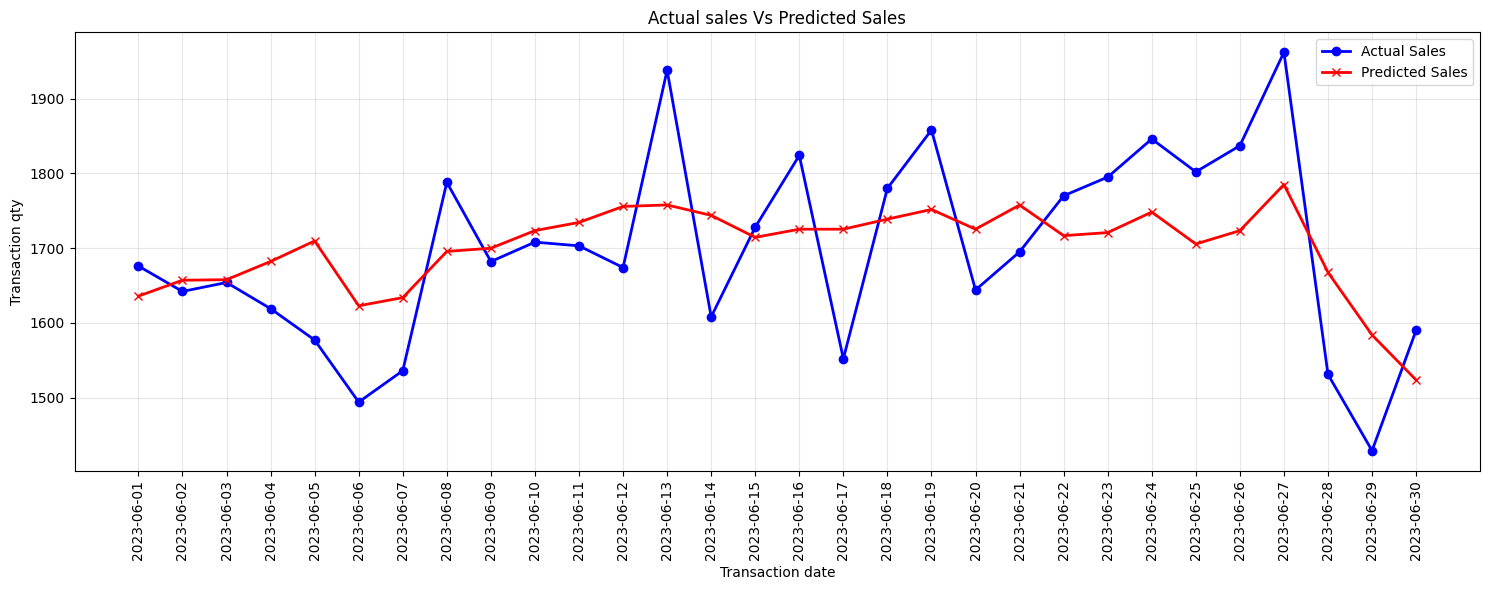

In [123]:
#plot the actual sales vs predicted sales
plt.figure(figsize=(15,6))
plt.plot(test.index,y_test_daily,color='blue',marker='o',linewidth=2,label='Actual Sales')
plt.plot(test.index,daily_pred,color='red',marker='x',linewidth=2,label='Predicted Sales')
plt.title('Actual sales Vs Predicted Sales')
plt.xlabel('Transaction date')
plt.ylabel('Transaction qty')
plt.xticks(test.index,rotation=90)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [124]:
#model evaluation for quantity using gradient
from sklearn.metrics import r2_score
gb_mae = mean_absolute_error(y_test_daily,daily_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test_daily,daily_pred))
gb_mape=mean_absolute_percentage_error(y_test_daily,daily_pred)*100
gb_R2 = r2_score(y_test_daily,daily_pred)
print(f"MAE : {gb_mae:.2f}")
print(f"RMSE: {gb_rmse:.2f}")
print(f"MAPE: {gb_mape:.2f}")
print(f"R2: {gb_R2:.2f}")

MAE : 86.12
RMSE: 99.88
MAPE: 5.11
R2: 0.39


In [125]:
#forecast accuracy(%) based on qty
forecast_accuracy_qty = 100 - gb_mape
print("Forecast accuracy:",forecast_accuracy_qty,"%")

Forecast accuracy: 94.88586492263231 %


In [126]:
#Peak error rate
actual_peak = y_test_daily.idxmax()
predicted_peak = test.index[np.argmax(daily_pred)]
print("Actual peak day:",actual_peak)
print("Predicted peak day:",predicted_peak)

Actual peak day: 2023-06-27 00:00:00
Predicted peak day: 2023-06-27 00:00:00


In [127]:
#Percentage peak error for qty
actual_peak_qty = y_test_daily.max()
predicted_peak_qty = daily_pred.max()
peak_error_rate = abs(actual_peak_qty - predicted_peak_qty)/actual_peak_qty*100
print(f"Peak Error Rate:{peak_error_rate:.2f}%")

Peak Error Rate:9.02%


In [128]:
#Peak demand capture rate
peak_threshold = y_test_daily.quantile(0.90)
print(peak_threshold)
actual_peak_rate = y_test_daily >= peak_threshold
print("Actual peak rate:",actual_peak_rate.sum())
predicted_peak_rate =  daily_pred >= peak_threshold
print("predicted peak rate:",predicted_peak_rate.sum())
print("Maximum Actual:",y_test_daily.max())
print("Maximum Predicted:",daily_pred.max())
capture_rate = (actual_peak_rate & predicted_peak_rate).sum() / actual_peak_rate.sum() * 100
print("Peak Demand Capture Rate",capture_rate,"%")

1847.2
Actual peak rate: 3
predicted peak rate: 0
Maximum Actual: 1962
Maximum Predicted: 1785.0278666424845
Peak Demand Capture Rate 0.0 %


In [129]:
print(daily_sales)

                  transaction_qty  revenue  Day  Month  Weekday   lag_1  \
transaction_date                                                          
2023-01-31                    645  2334.13   31      1        1   693.0   
2023-02-01                    796  2466.30    1      2        2   645.0   
2023-02-02                    814  2506.90    2      2        3   796.0   
2023-02-03                    834  2591.45    3      2        4   814.0   
2023-02-04                    834  2551.70    4      2        5   834.0   
...                           ...      ...  ...    ...      ...     ...   
2023-06-26                   1837  5875.90   26      6        0  1802.0   
2023-06-27                   1962  5975.65   27      6        1  1837.0   
2023-06-28                   1531  4728.90   28      6        2  1962.0   
2023-06-29                   1429  4450.75   29      6        3  1531.0   
2023-06-30                   1590  5481.32   30      6        4  1429.0   

                   lag_7

In [130]:

train = daily_sales.iloc[:-30].copy()
test = daily_sales.iloc[-30:].copy()

print("Train shape:", train.shape)
print("Test shape:", test.shape)

print("\nTrain columns:")
print(train.columns.tolist())

print("\nTest columns:")
print(test.columns.tolist())

Train shape: (121, 10)
Test shape: (30, 10)

Train columns:
['transaction_qty', 'revenue', 'Day', 'Month', 'Weekday', 'lag_1', 'lag_7', 'lag_30', 'rolling_3', 'rolling_7']

Test columns:
['transaction_qty', 'revenue', 'Day', 'Month', 'Weekday', 'lag_1', 'lag_7', 'lag_30', 'rolling_3', 'rolling_7']


In [131]:
#predict revenue
X_train_rev = train[['Day','Month','Weekday','lag_1','lag_7','lag_30','rolling_3','rolling_7']]
Y_train_rev = train['revenue']

x_test_rev = test[['Day','Month','Weekday','lag_1','lag_7','lag_30','rolling_3','rolling_7']]
y_test_rev = test['revenue']

In [132]:
#Forecasting machine learning model(Gradient Boosting regression) for revenue
revenue_gbr = GradientBoostingRegressor(random_state=42)
revenue_gbr.fit(X_train_rev,Y_train_rev)

GradientBoostingRegressor(random_state=42)

In [133]:
#Predict revenue
y_pred_rev = revenue_gbr.predict(x_test_rev)
print(y_pred_rev)


[5179.67620903 5308.10247712 5381.77444574 5353.69615585 5655.3252901
 5503.3599151  5304.65589504 5571.12673435 5546.66248958 5527.57615094
 5450.9386628  5667.2989709  5509.15155815 5491.69826236 5391.29941473
 5458.04032936 5567.58165324 5555.22971027 5594.23394588 5439.89593579
 5495.36773858 5389.05663414 5378.59406602 5481.73312499 5516.62785529
 5519.60256666 5499.12254328 5198.51723308 5222.73498684 5161.4897397 ]


In [134]:
#compare actual revenue with predicted revenue
comparision_rev = test[['revenue']].copy()
comparision_rev['Predicted_Revenue'] = y_pred_rev
print(comparision_rev.head(10))

                  revenue  Predicted_Revenue
transaction_date                            
2023-06-01        5227.00        5179.676209
2023-06-02        5056.50        5308.102477
2023-06-03        5166.65        5381.774446
2023-06-04        4985.15        5353.696156
2023-06-05        4911.15        5655.325290
2023-06-06        4598.90        5503.359915
2023-06-07        4883.10        5304.655895
2023-06-08        6151.59        5571.126734
2023-06-09        5867.16        5546.662490
2023-06-10        5626.75        5527.576151


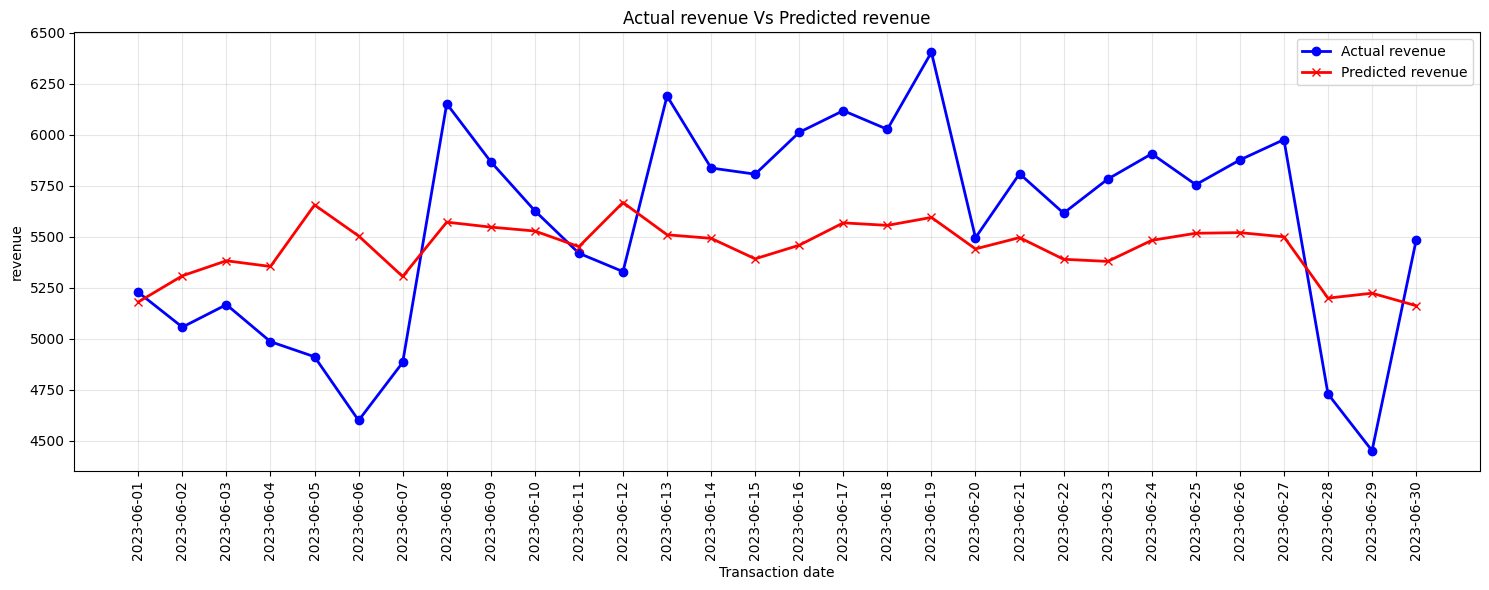

In [135]:
#plot the actual revenue vs predicted revenue
plt.figure(figsize=(15,6))
plt.plot(test.index,y_test_rev,color='blue',marker='o',linewidth=2,label='Actual revenue')
plt.plot(test.index,y_pred_rev,color='red',marker='x',linewidth=2,label='Predicted revenue')
plt.title('Actual revenue Vs Predicted revenue')
plt.xlabel('Transaction date')
plt.ylabel('revenue')
plt.xticks(test.index,rotation=90)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [136]:
# GRADIENT MODEL FOR REVENUE
gbr_rev_mae = mean_absolute_error(y_test_rev,y_pred_rev)
gbr_rev_rmse = np.sqrt(mean_squared_error(y_test_rev,y_pred_rev))
gbr_rev_mape=mean_absolute_percentage_error(y_test_rev,y_pred_rev)*100
gbr_rev_R2 = r2_score(y_test_rev,y_pred_rev)
print(f"MAE : {gbr_rev_mae:.2f}")
print(f"RMSE: {gbr_rev_rmse:.2f}")
print(f"MAPE:", round(gbr_rev_mape,2),"%")
print('R2:',gbr_rev_R2)

MAE : 406.72
RMSE: 462.84
MAPE: 7.44 %
R2: 0.15713895256834998


In [137]:
#NAIVE MODEL FOR REVENUE
# Previous day's revenue as prediction
naive_pred_rev = test['revenue'].shift(1)

# First prediction uses last value from training set
naive_pred_rev.iloc[0] = train['revenue'].iloc[-1]

naive_rev_mae = mean_absolute_error(y_test_rev, naive_pred_rev)
naive_rev_rmse = np.sqrt(mean_squared_error(y_test_rev, naive_pred_rev))
naive_rev_mape = mean_absolute_percentage_error(y_test_rev, naive_pred_rev) * 100
naive_rev_R2 = r2_score(y_test_rev,naive_pred_rev)

print("Naive Revenue Forecast")
print("MAE :", naive_rev_mae)
print("RMSE:", naive_rev_rmse)
print("MAPE:", naive_rev_mape)
print('R2:',naive_rev_R2)

Naive Revenue Forecast
MAE : 347.5363333333333
RMSE: 488.8585239003202
MAPE: 6.336938485465655
R2: 0.05970082001939769


In [138]:
#MOVING AVERAGE 3 MODEL FOR REVENUE
moving_pred_rev3 = test['rolling_3']

moving3_rev_mae = mean_absolute_error(y_test_rev, moving_pred_rev3)
moving3_rev_rmse = np.sqrt(mean_squared_error(y_test_rev, moving_pred_rev3))
moving3_rev_mape = mean_absolute_percentage_error(y_test_rev, moving_pred_rev3) * 100
moving3_rev_R2 = r2_score(y_test_rev,moving_pred_rev3)


print("3-Day Moving Average Revenue")
print("MAE :", moving3_rev_mae)
print("RMSE:", moving3_rev_rmse)
print("MAPE:", moving3_rev_mape)
print('R2:',moving3_rev_R2)

3-Day Moving Average Revenue
MAE : 3854.662666666666
RMSE: 3882.370631865326
MAPE: 69.27300150636466
R2: -58.30532078938079


In [139]:
#MOVING AVERAGE 7 MODEL FOR REVENUE
moving_pred_rev7 = test['rolling_7']

moving7_rev_mae = mean_absolute_error(y_test_rev, moving_pred_rev7)
moving7_rev_rmse = np.sqrt(mean_squared_error(y_test_rev, moving_pred_rev7))
moving7_rev_mape = mean_absolute_percentage_error(y_test_rev, moving_pred_rev7) * 100
moving7_rev_R2 = r2_score(y_test_rev,moving_pred_rev7)


print("7-Day Moving Average Revenue")
print("MAE :", moving7_rev_mae)
print("RMSE:", moving7_rev_rmse)
print("MAPE:", moving7_rev_mape)
print('R2:',moving7_rev_R2)

7-Day Moving Average Revenue
MAE : 3869.0864761904763
RMSE: 3897.4935130450917
MAPE: 69.51944744289193
R2: -58.768241089856296


In [140]:
#ARIMA MODEL FOR REVENUE
from statsmodels.tsa.arima.model import ARIMA

arima_model_rev = ARIMA(train['revenue'], order=(5,1,0))

arima_fit_rev = arima_model_rev.fit()

arima_pred_rev = arima_fit_rev.forecast(steps=len(test))

arima_rev_mae = mean_absolute_error(y_test_rev, arima_pred_rev)
arima_rev_rmse = np.sqrt(mean_squared_error(y_test_rev, arima_pred_rev))
arima_rev_mape = mean_absolute_percentage_error(y_test_rev, arima_pred_rev) * 100
arima_rev_R2 = r2_score(y_test_rev,arima_pred_rev)

print("ARIMA Revenue Forecast")
print("MAE :", arima_rev_mae)
print("RMSE:", arima_rev_rmse)
print("MAPE:", arima_rev_mape)
print('R2:', arima_rev_R2)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.



ARIMA Revenue Forecast
MAE : 859.5469143230005
RMSE: 979.2980672463269
MAPE: 14.836440853229856
R2: -2.773370657335597


In [141]:
#Compare 4 models
performance_revenue = pd.DataFrame({
    "Model": ["Naive", "Moving Average (3-Day)", "ARIMA", "Gradient Boosting"],
    "MAE": [naive_rev_mae, moving3_rev_mae, arima_rev_mae, gbr_rev_mae],
    "RMSE": [naive_rev_rmse, moving3_rev_rmse, arima_rev_rmse, gbr_rev_rmse],
    "MAPE": [naive_rev_mape, moving3_rev_mape, arima_rev_mape, gbr_rev_mape],
    'R2': [naive_rev_R2,moving3_rev_R2,arima_rev_R2,gbr_rev_R2]
})

print(performance_revenue)

                    Model          MAE         RMSE       MAPE         R2
0                   Naive   347.536333   488.858524   6.336938   0.059701
1  Moving Average (3-Day)  3854.662667  3882.370632  69.273002 -58.305321
2                   ARIMA   859.546914   979.298067  14.836441  -2.773371
3       Gradient Boosting   406.723246   462.837091   7.435332   0.157139


In [142]:
#FORECAST ACCURACY(%)
forecast_accuracy = 100 - gbr_rev_mape
print("Forecast accuracy:" ,forecast_accuracy,"%")

Forecast accuracy: 92.56466757475528 %


In [143]:
#Percentage peak error for qty
actual_peak_rev = y_test_rev.max()
predicted_peak_rev = y_pred_rev.max()
peak_error_rate = abs(actual_peak_rev - predicted_peak_rev)/actual_peak_rev*100
print(f"Peak Error Rate:{peak_error_rate:.2f}%")

Peak Error Rate:11.50%


In [144]:
#Peak error rate based on revenue
actual_peak = y_test_rev.idxmax()
predicted_peak = test.index[np.argmax(y_pred_rev)]
print("Actual peak day:",actual_peak)
print("Predicted peak day:",predicted_peak)

Actual peak day: 2023-06-19 00:00:00
Predicted peak day: 2023-06-12 00:00:00


In [145]:
#FORECASTING SALES
#FORECASTING FUTURE SALES
#CREATE FUTURE DATES
future_dates=pd.date_range(start=daily_sales.index.max() + pd.Timedelta(days=1),periods=30)
future=pd.DataFrame(index=future_dates)
print(future)

Empty DataFrame
Columns: []
Index: [2023-07-01 00:00:00, 2023-07-02 00:00:00, 2023-07-03 00:00:00, 2023-07-04 00:00:00, 2023-07-05 00:00:00, 2023-07-06 00:00:00, 2023-07-07 00:00:00, 2023-07-08 00:00:00, 2023-07-09 00:00:00, 2023-07-10 00:00:00, 2023-07-11 00:00:00, 2023-07-12 00:00:00, 2023-07-13 00:00:00, 2023-07-14 00:00:00, 2023-07-15 00:00:00, 2023-07-16 00:00:00, 2023-07-17 00:00:00, 2023-07-18 00:00:00, 2023-07-19 00:00:00, 2023-07-20 00:00:00, 2023-07-21 00:00:00, 2023-07-22 00:00:00, 2023-07-23 00:00:00, 2023-07-24 00:00:00, 2023-07-25 00:00:00, 2023-07-26 00:00:00, 2023-07-27 00:00:00, 2023-07-28 00:00:00, 2023-07-29 00:00:00, 2023-07-30 00:00:00]


In [146]:
#create features
future['Day']=future.index.day
future['Month']=future.index.month
future['Weekday']=future.index.dayofweek


In [147]:
#fORECASTING DAILY SALES #Reccursive forecasting for next 30 days on Quantity
quantity_predictions=[]
history = daily_sales['transaction_qty'].tolist()
#predict one day at a time
for i in range(len(future)):
  lag_1 =history[-1]
  lag_7 = history[-7]
  lag_30 = history[-30]
  rolling_3 = sum(history[-3:]) / 3
  rolling_7 = sum(history[-7:]) / 7

  x = pd.DataFrame({'Day' :[future.iloc[i]['Day']],
        'Month' : [future.iloc[i]['Month']],
        'Weekday' :[future.iloc[i]['Weekday']],
        'lag_1' : [lag_1],
        'lag_7' : [lag_7],
        'lag_30' : [lag_30],
        'rolling_3' : [rolling_3],
        'rolling_7' : [rolling_7]
  })
  pred = gb_daily_model.predict(x)[0]
  quantity_predictions.append(pred)
  history.append(pred)



In [148]:
print(len(quantity_predictions))

30


In [149]:
future['Predicted_quantity'] = quantity_predictions
print(future[['Predicted_quantity']])

            Predicted_quantity
2023-07-01         1607.262861
2023-07-02         1605.370029
2023-07-03         1670.235735
2023-07-04         1666.703256
2023-07-05         1691.641399
2023-07-06         1687.915845
2023-07-07         1724.847831
2023-07-08         1822.485923
2023-07-09         1757.324779
2023-07-10         1752.730100
2023-07-11         1737.723418
2023-07-12         1731.502850
2023-07-13         1731.502850
2023-07-14         1714.849525
2023-07-15         1719.306700
2023-07-16         1720.207896
2023-07-17         1726.211600
2023-07-18         1725.301639
2023-07-19         1719.081071
2023-07-20         1719.081071
2023-07-21         1730.471330
2023-07-22         1732.312103
2023-07-23         1732.312103
2023-07-24         1735.244588
2023-07-25         1707.309993
2023-07-26         1712.764046
2023-07-27         1772.111704
2023-07-28         1662.751749
2023-07-29         1645.913973
2023-07-30         1683.274664


In [150]:
print(future.columns)

Index(['Day', 'Month', 'Weekday', 'Predicted_quantity'], dtype='object')


/tmp/ipykernel_1345/1493240754.py:7: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



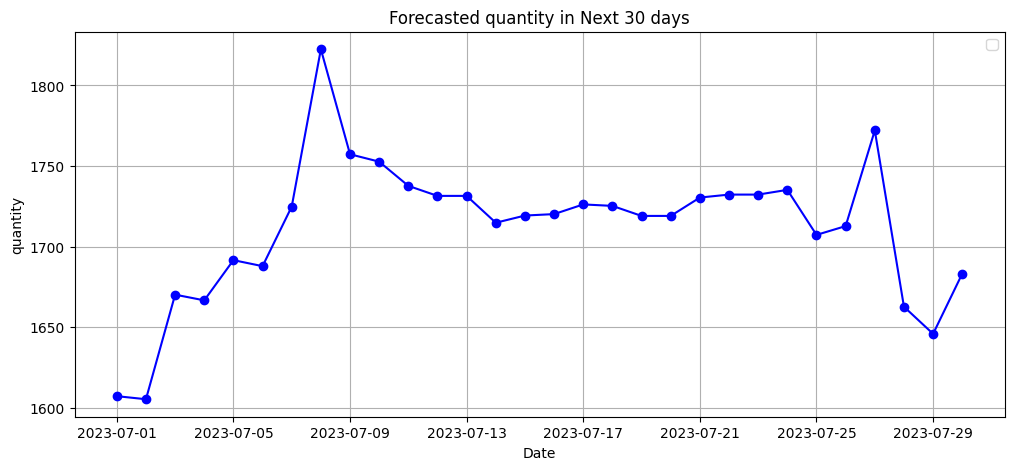

In [151]:
plt.figure(figsize=(12,5))
plt.plot(future.index,future['Predicted_quantity'],marker='o',color='blue')
plt.title("Forecasted quantity in Next 30 days")
plt.xlabel("Date")
plt.ylabel('quantity')
plt.grid(True)
plt.legend()
plt.show()

In [152]:
#Reccursive forecasting for next 30 days on revenue
history = daily_sales['revenue'].tolist()
revenue_predictions=[]
#predict one day at a time
for i in range(len(future)):
  lag_1 =history[-1]
  lag_7 = history[-7]
  lag_30 = history[-30]
  rolling_3 = sum(history[-3:]) / 3
  rolling_7 = sum(history[-7:]) / 7
  x = pd.DataFrame({'Day' :[future.iloc[i]['Day']],
        'Month' : [future.iloc[i]['Month']],
        'Weekday' :[future.iloc[i]['Weekday']],
        'lag_1' : [lag_1],
        'lag_7' : [lag_7],
        'lag_30' : [lag_30],
        'rolling_3' : [rolling_3],
        'rolling_7' : [rolling_7]
  })
  pred = revenue_gbr.predict(x)[0]
  revenue_predictions.append(pred)
  history.append(pred)

In [153]:
future['Predicted_revenue'] = revenue_predictions
print(future[['Predicted_revenue']])

            Predicted_revenue
2023-07-01        5552.586357
2023-07-02        5546.939192
2023-07-03        5577.685680
2023-07-04        5441.280294
2023-07-05        5437.397868
2023-07-06        5434.318519
2023-07-07        5473.704865
2023-07-08        5710.480897
2023-07-09        5576.869798
2023-07-10        5530.792277
2023-07-11        5387.933151
2023-07-12        5384.050725
2023-07-13        5412.364247
2023-07-14        5412.364247
2023-07-15        5521.905571
2023-07-16        5576.329660
2023-07-17        5594.269063
2023-07-18        5479.383651
2023-07-19        5475.501225
2023-07-20        5436.013510
2023-07-21        5439.827443
2023-07-22        5530.904356
2023-07-23        5516.627855
2023-07-24        5503.948189
2023-07-25        5378.662559
2023-07-26        5390.434511
2023-07-27        5445.215497
2023-07-28        5224.734190
2023-07-29        5347.113602
2023-07-30        5473.635644


/tmp/ipykernel_1345/1051995105.py:7: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



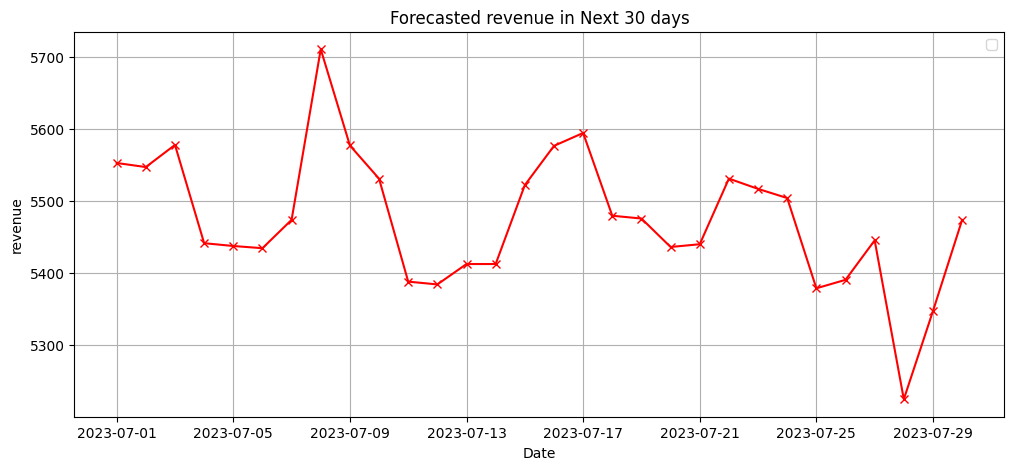

In [154]:
plt.figure(figsize=(12,5))
plt.plot(future.index,future['Predicted_revenue'],marker='x',color='red')
plt.title("Forecasted revenue in Next 30 days")
plt.xlabel("Date")
plt.ylabel('revenue')
plt.grid(True)
plt.legend()
plt.show()

In [155]:
#Forecasting machine learning models
#predict naive_prediction model for quantity
naive_pred = test['transaction_qty'].shift(1)

naive_pred = naive_pred.fillna(train['transaction_qty'].iloc[-1])
print(naive_pred)

transaction_date
2023-06-01    1428.0
2023-06-02    1676.0
2023-06-03    1642.0
2023-06-04    1654.0
2023-06-05    1619.0
2023-06-06    1577.0
2023-06-07    1494.0
2023-06-08    1536.0
2023-06-09    1788.0
2023-06-10    1682.0
2023-06-11    1708.0
2023-06-12    1703.0
2023-06-13    1674.0
2023-06-14    1938.0
2023-06-15    1608.0
2023-06-16    1728.0
2023-06-17    1824.0
2023-06-18    1552.0
2023-06-19    1780.0
2023-06-20    1858.0
2023-06-21    1644.0
2023-06-22    1695.0
2023-06-23    1770.0
2023-06-24    1795.0
2023-06-25    1846.0
2023-06-26    1802.0
2023-06-27    1837.0
2023-06-28    1962.0
2023-06-29    1531.0
2023-06-30    1429.0
Name: transaction_qty, dtype: float64


In [156]:
print(y_test_daily)

transaction_date
2023-06-01    1676
2023-06-02    1642
2023-06-03    1654
2023-06-04    1619
2023-06-05    1577
2023-06-06    1494
2023-06-07    1536
2023-06-08    1788
2023-06-09    1682
2023-06-10    1708
2023-06-11    1703
2023-06-12    1674
2023-06-13    1938
2023-06-14    1608
2023-06-15    1728
2023-06-16    1824
2023-06-17    1552
2023-06-18    1780
2023-06-19    1858
2023-06-20    1644
2023-06-21    1695
2023-06-22    1770
2023-06-23    1795
2023-06-24    1846
2023-06-25    1802
2023-06-26    1837
2023-06-27    1962
2023-06-28    1531
2023-06-29    1429
2023-06-30    1590
Name: transaction_qty, dtype: int64


In [157]:
#evaluation
naive_qty_mae = mean_absolute_error(y_test_daily,naive_pred)
naive_qty_rmse= np.sqrt(mean_squared_error(y_test_daily,naive_pred))
naive_qty_mape=mean_absolute_percentage_error(y_test_daily,naive_pred)*100
naive_qty_R2 = r2_score(y_test_daily,naive_pred)

print("Naive Forecast")
print("MAE:",naive_qty_mae)
print("RMSE:",naive_qty_rmse)
print("MAPE:",naive_qty_mape)
print('R2:',naive_qty_R2)

Naive Forecast
MAE: 120.53333333333333
RMSE: 161.56649817747902
MAPE: 7.202984999644316
R2: -0.5961034828261


In [158]:
#Moving Average Forecast
#3-day moving average
moving3_qty_pred = train['transaction_qty'].rolling(3).mean().iloc[-1]
moving3_qty_pred =np.repeat(moving3_qty_pred,len(test))
print(moving3_qty_pred)

[1387.66666667 1387.66666667 1387.66666667 1387.66666667 1387.66666667
 1387.66666667 1387.66666667 1387.66666667 1387.66666667 1387.66666667
 1387.66666667 1387.66666667 1387.66666667 1387.66666667 1387.66666667
 1387.66666667 1387.66666667 1387.66666667 1387.66666667 1387.66666667
 1387.66666667 1387.66666667 1387.66666667 1387.66666667 1387.66666667
 1387.66666667 1387.66666667 1387.66666667 1387.66666667 1387.66666667]


In [159]:
#7-day moving average
moving7_qty_pred = train['transaction_qty'].rolling(7).mean().iloc[-1]
moving7_qty_pred =np.repeat(moving7_qty_pred,len(test))
print(moving7_qty_pred)

[1522. 1522. 1522. 1522. 1522. 1522. 1522. 1522. 1522. 1522. 1522. 1522.
 1522. 1522. 1522. 1522. 1522. 1522. 1522. 1522. 1522. 1522. 1522. 1522.
 1522. 1522. 1522. 1522. 1522. 1522.]


In [160]:
print("3 day average:",moving3_qty_pred[0])
print("7 day average:",moving7_qty_pred[0])

3 day average: 1387.6666666666667
7 day average: 1522.0


In [161]:
print("3 day average:",moving3_qty_pred[:5])
print("7 day average:",moving7_qty_pred[:5])
print("Last 3 values:")
print(train['transaction_qty'].tail(3))
print("Last 7 values")
print(train['transaction_qty'].tail(7))

3 day average: [1387.66666667 1387.66666667 1387.66666667 1387.66666667 1387.66666667]
7 day average: [1522. 1522. 1522. 1522. 1522.]
Last 3 values:
transaction_date
2023-05-29    1270
2023-05-30    1465
2023-05-31    1428
Name: transaction_qty, dtype: int64
Last 7 values
transaction_date
2023-05-25    1613
2023-05-26    1661
2023-05-27    1815
2023-05-28    1402
2023-05-29    1270
2023-05-30    1465
2023-05-31    1428
Name: transaction_qty, dtype: int64


In [162]:
#Moving average forecast evaluation
moving3_qty_mae = mean_absolute_error(y_test_daily,moving3_qty_pred)
moving3_qty_rmse= np.sqrt(mean_squared_error(y_test_daily,moving3_qty_pred))
moving3_qty_mape=mean_absolute_percentage_error(y_test_daily,moving3_qty_pred)*100
moving3_qty_R2 = r2_score(y_test_daily,moving3_qty_pred)



print("Moving Average Forecast for 3 day")
print("MAE:",moving3_qty_mae)
print("RMSE:",moving3_qty_rmse)
print("MAPE:",moving3_qty_mape)
print('R2:',moving3_qty_R2)



Moving Average Forecast for 3 day
MAE: 310.4
RMSE: 335.71240999138263
MAPE: 17.81136102827383
R2: -5.891173947272661


In [163]:
moving7_qty_mae = mean_absolute_error(y_test_daily,moving7_qty_pred)
moving7_qty_rmse= np.sqrt(mean_squared_error(y_test_daily,moving7_qty_pred))
moving7_qty_mape=mean_absolute_percentage_error(y_test_daily,moving7_qty_pred)*100
moving7_qty_R2 = r2_score(y_test_daily,moving7_qty_pred)



print("Moving Average Forecast for 7 day")
print("MAE:",moving7_qty_mae)
print("RMSE:",moving7_qty_rmse)
print("MAPE:",moving7_qty_mape)
print('R2:',moving7_qty_R2)



Moving Average Forecast for 7 day
MAE: 184.13333333333333
RMSE: 217.6100487875809
MAPE: 10.41388839501613
R2: -1.895451626569821


In [164]:
#ARIMA(Statistical model)
!pip install statsmodels
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error,mean_absolute_percentage_error




In [165]:
arima_model = ARIMA(train['transaction_qty'],order=(1,1,1))
arima_fit = arima_model.fit()
arima_qty_pred = arima_fit.forecast(steps=len(test))
arima_qty_mae = mean_absolute_error(test['transaction_qty'],arima_qty_pred)
arima_qty_rmse =  np.sqrt(mean_squared_error(test['transaction_qty'],arima_qty_pred))
arima_qty_mape = mean_absolute_percentage_error(test['transaction_qty'],arima_qty_pred) * 100
arima_qty_R2 = r2_score(y_test_daily,arima_qty_pred)

print("ARIMA FORECAST")
print('MAE:',arima_qty_mae)
print('RMSE:',arima_qty_rmse)
print('MAPE:',arima_qty_mape)
print('R2:',arima_qty_R2)


ARIMA FORECAST
MAE: 213.26492402086657
RMSE: 245.18451084267443
MAPE: 12.101788188475677
R2: -2.675737446627206


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.



In [166]:
#compare all models for rolling average 7

performance_quantity = pd.DataFrame({'Model':['Naive Forecast','Moving Average','ARIMA','Gradient Boosting'],
                        'MAE': [naive_qty_mae,moving7_qty_mae,arima_qty_mae,gb_mae],
                        'RMSE': [naive_qty_rmse,moving7_qty_rmse,arima_qty_rmse,gb_rmse],
                        'MAPE': [naive_qty_mape,moving7_qty_mape,arima_qty_mape,gb_mape],
                        'R2':[naive_qty_R2,moving7_qty_R2,arima_qty_R2,gb_R2]
                        })
print(performance_quantity)

               Model         MAE        RMSE       MAPE        R2
0     Naive Forecast  120.533333  161.566498   7.202985 -0.596103
1     Moving Average  184.133333  217.610049  10.413888 -1.895452
2              ARIMA  213.264924  245.184511  12.101788 -2.675737
3  Gradient Boosting   86.118527   99.875346   5.114135  0.390077


In [167]:
# How much will we sell tomorrow or next week?
print("Tomorrow's forecast")
print(future[['Predicted_quantity','Predicted_revenue']].head(1))
print("Next week forecast")
next_week = future.head(7)
print(next_week[['Predicted_quantity','Predicted_revenue']])
print("Total predicted quantity for next week:",next_week['Predicted_quantity'].sum())
print("Average predicted quantity for next week:",next_week['Predicted_quantity'].mean())
print("Total predicted revenue for next week:",next_week['Predicted_revenue'].sum())
print("Average predicted revenue for next week:",next_week['Predicted_revenue'].mean())


Tomorrow's forecast
            Predicted_quantity  Predicted_revenue
2023-07-01         1607.262861        5552.586357
Next week forecast
            Predicted_quantity  Predicted_revenue
2023-07-01         1607.262861        5552.586357
2023-07-02         1605.370029        5546.939192
2023-07-03         1670.235735        5577.685680
2023-07-04         1666.703256        5441.280294
2023-07-05         1691.641399        5437.397868
2023-07-06         1687.915845        5434.318519
2023-07-07         1724.847831        5473.704865
Total predicted quantity for next week: 11653.976955531427
Average predicted quantity for next week: 1664.8538507902038
Total predicted revenue for next week: 38463.91277323234
Average predicted revenue for next week: 5494.844681890334


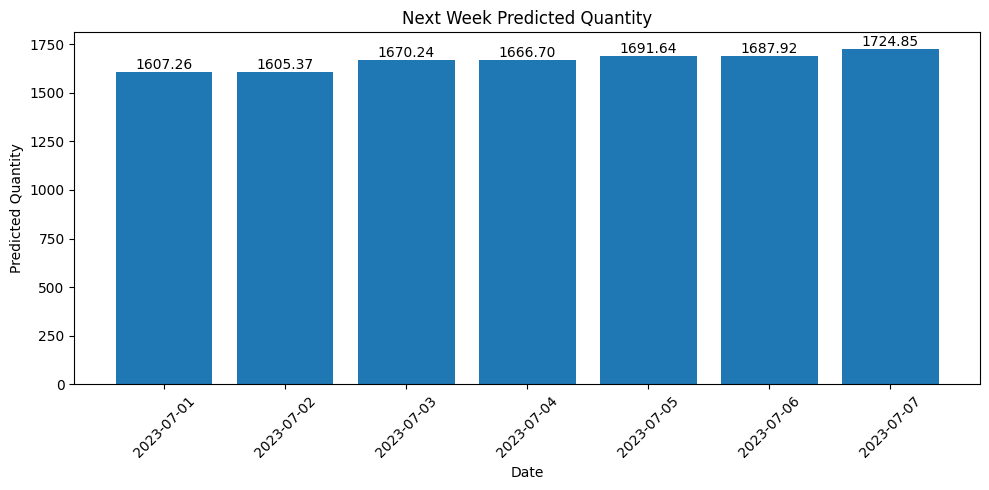

In [168]:
import matplotlib.pyplot as plt

# Get the next 7 days
next_week = future.head(7)

# -------------------------------
# Bar chart: Predicted Quantity
# -------------------------------
plt.figure(figsize=(10, 5))

bars = plt.bar(
    next_week.index.astype(str),
    next_week["Predicted_quantity"]
)
for bar in bars:
  value = bar.get_height()
  plt.text(bar.get_x() + bar.get_width() /2, value, f"{value:.2f}",ha="center",va="bottom")

plt.title("Next Week Predicted Quantity")
plt.xlabel("Date")
plt.ylabel("Predicted Quantity")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()




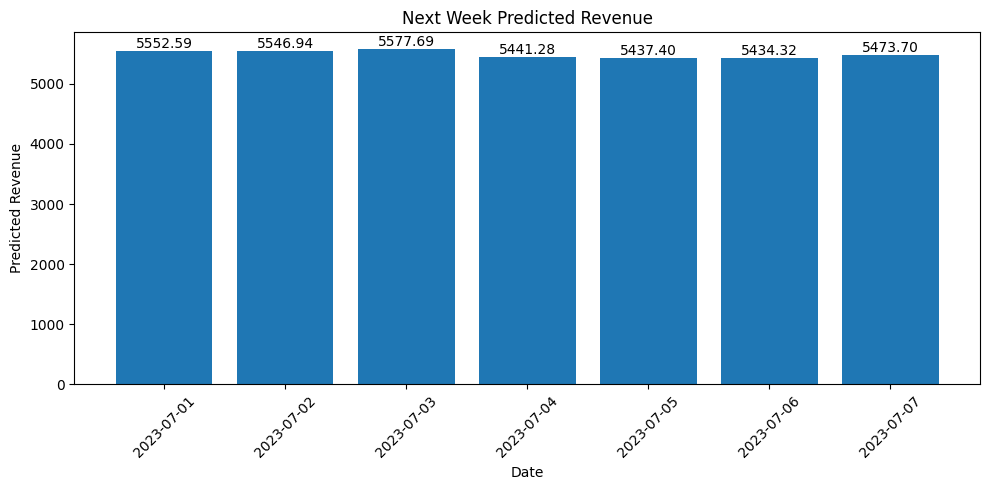

In [169]:
# -------------------------------
# Bar chart: Predicted Revenue
# -------------------------------
next_week = future.head(7)
plt.figure(figsize=(10, 5))

bars = plt.bar(
    next_week.index.astype(str),
    next_week["Predicted_revenue"]
)
for bar in bars:
   value = bar.get_height()
   plt.text(bar.get_x() + bar.get_width() /2, value, f"{value:.2f}",ha="center",va="bottom")

plt.title("Next Week Predicted Revenue")
plt.xlabel("Date")
plt.ylabel("Predicted Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [170]:
# When will demand peak at each store?
daily_sales =df.groupby(['transaction_date','store_location'])[['transaction_qty','revenue']].sum()
print(daily_sales)

                                  transaction_qty  revenue
transaction_date store_location                           
2023-01-01       Astoria                      277   868.40
                 Hell's Kitchen               270   851.45
                 Lower Manhattan              255   788.35
2023-01-02       Astoria                      301   925.50
                 Hell's Kitchen               272   828.80
...                                           ...      ...
2023-06-29       Hell's Kitchen               420  1298.55
                 Lower Manhattan              424  1299.45
2023-06-30       Astoria                      577  1807.65
                 Hell's Kitchen               478  1904.93
                 Lower Manhattan              535  1768.74

[543 rows x 2 columns]


In [171]:
#peak demand day at each store(Quantity)
daily_sales_reset = daily_sales.reset_index()
#Find peak demand day for each store
peak_demand = daily_sales_reset.loc[daily_sales_reset.groupby('store_location')['transaction_qty'].idxmax()]
print("Peak demand day at each store(Quantity):",peak_demand[['store_location','transaction_date','transaction_qty']])

Peak demand day at each store(Quantity):       store_location transaction_date  transaction_qty
507          Astoria       2023-06-19              688
490   Hell's Kitchen       2023-06-13              769
533  Lower Manhattan       2023-06-27              770


In [172]:
#peak demand day at each store(Revenue)
daily_sales_reset = daily_sales.reset_index()
#Find peak demand day for each store
peak_demand = daily_sales_reset.loc[daily_sales_reset.groupby('store_location')['revenue'].idxmax()]
print("Peak demand day at each store(revenue):",peak_demand[['store_location','transaction_date','revenue']])

Peak demand day at each store(revenue):       store_location transaction_date  revenue
507          Astoria       2023-06-19  2546.43
490   Hell's Kitchen       2023-06-13  2534.80
533  Lower Manhattan       2023-06-27  2437.40


In [173]:
# Which locations require higher inventory or staffing?
store_summary_result = daily_sales_reset.groupby('store_location').agg(Avg_Daily_Quantity = ('transaction_qty','mean'),
                                                                       Avg_Daily_Revenue = ('revenue','mean'),
                                                                       Max_Daily_Quantity = ('transaction_qty','max'),
                                                                       Max_Daily_Revenue = ('revenue','max')).sort_values(by = 'Avg_Daily_Quantity',ascending=False)
print(store_summary_result)

                 Avg_Daily_Quantity  Avg_Daily_Revenue  Max_Daily_Quantity  \
store_location                                                               
Lower Manhattan          396.364641        1271.034530                 770   
Hell's Kitchen           396.337017        1306.691547                 769   
Astoria                  392.215470        1283.115525                 688   

                 Max_Daily_Revenue  
store_location                      
Lower Manhattan            2437.40  
Hell's Kitchen             2534.80  
Astoria                    2546.43  


Hell's Kitchen and Lower Manhattan requires more inventory and staffing

In [174]:
daily_pred = gb_daily_model.predict(x_test_daily)
print(daily_pred)


[1635.74706671 1657.04394663 1657.72680854 1682.13202332 1709.58391438
 1622.80835447 1633.78859765 1695.5630741  1699.83452807 1723.41217906
 1734.35850499 1755.7281918  1757.72040666 1743.78343876 1714.35846554
 1725.2794625  1725.29802682 1738.76958738 1751.68065815 1725.30163859
 1757.64936629 1716.63325418 1720.75723156 1748.20541981 1705.50865501
 1723.37370043 1785.02786664 1667.52592835 1583.76392275 1523.55872118]


In [175]:
# ============================================================
# CALCULATE 95% PREDICTION INTERVAL - DAILY QUANTITY
# ============================================================

quantity_residuals = y_test_daily - daily_pred

lower_quantity_error = np.percentile(
    quantity_residuals, 2.5
)

upper_quantity_error = np.percentile(
    quantity_residuals, 97.5
)

print("95% Daily Quantity residual interval:")
print("Lower error:", lower_quantity_error)
print("Upper error:", upper_quantity_error)

95% Daily Quantity residual interval:
Lower error: -159.86080136931653
Upper error: 177.88168485331772


In [176]:
import numpy as np
import json
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ============================================================
# MODEL PERFORMANCE METRICS
# ============================================================

def calculate_metrics(actual, predicted):

    mae = mean_absolute_error(actual, predicted)

    rmse = np.sqrt(
        mean_squared_error(actual, predicted)
    )

    # Safe MAPE - avoids division by zero
    actual = np.array(actual)
    predicted = np.array(predicted)

    mask = actual != 0

    if mask.sum() > 0:
        mape = np.mean(
            np.abs(
                (actual[mask] - predicted[mask])
                / actual[mask]
            )
        ) * 100
    else:
        mape = np.nan

    return {
        "MAE": float(mae),
        "RMSE": float(rmse),
        "MAPE": float(mape)
    }


# ============================================================
# DAILY QUANTITY
# ============================================================

daily_quantity_metrics = calculate_metrics(
    y_test_daily,
    daily_pred
)


# ============================================================
# DAILY REVENUE
# ============================================================

daily_revenue_metrics = calculate_metrics(
    y_test_rev,
    y_pred_rev
)


# ============================================================
# SAVE METRICS
# ============================================================

model_metrics = {

    "Daily Quantity": daily_quantity_metrics,

    "Daily Revenue": daily_revenue_metrics

}


with open(
    "/content/drive/MyDrive/model_metrics.json",
    "w"
) as f:

    json.dump(
        model_metrics,
        f,
        indent=4
    )


print("MODEL PERFORMANCE")
print("========================")

print("\nDaily Quantity")
print(daily_quantity_metrics)

print("\nDaily Revenue")
print(daily_revenue_metrics)

print("\nMetrics saved successfully!")

MODEL PERFORMANCE

Daily Quantity
{'MAE': 86.1185266882052, 'RMSE': 99.87534565353606, 'MAPE': 5.114135077367697}

Daily Revenue
{'MAE': 406.72324567467984, 'RMSE': 462.83709083578685, 'MAPE': 7.4353324252447255}

Metrics saved successfully!


In [177]:
import numpy as np
import json

# Daily Quantity residuals
quantity_residual_sd = np.std(
    y_test_daily - daily_pred,
    ddof=1
)

# Daily Revenue residuals
revenue_residual_sd = np.std(
    y_test_rev - y_pred_rev,
    ddof=1
)

print("Daily Quantity Residual SD:",
      quantity_residual_sd)

print("Daily Revenue Residual SD:",
      revenue_residual_sd)

Daily Quantity Residual SD: 101.54659496763976
Daily Revenue Residual SD: 458.3511678664042


In [178]:
# ============================================================
# SAVE 95% PREDICTION INTERVAL INFORMATION
# ============================================================

import json

prediction_interval = {
    "confidence_level": 0.95,
    "z_value": 1.96,
    "daily_quantity_residual_sd": float(quantity_residual_sd),
    "daily_revenue_residual_sd": float(revenue_residual_sd)
}

with open(
    "/content/drive/MyDrive/prediction_intervals.json",
    "w"
) as f:
    json.dump(prediction_interval, f, indent=4)

print("95% prediction interval information saved successfully!")
print(prediction_interval)

95% prediction interval information saved successfully!
{'confidence_level': 0.95, 'z_value': 1.96, 'daily_quantity_residual_sd': 101.54659496763976, 'daily_revenue_residual_sd': 458.3511678664042}


In [179]:
print(len(revenue_predictions))

30


In [180]:
print(len(quantity_predictions))

30


In [181]:
#Forecasting hourly sales for transaction quantity
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,r2_score

# ===================================================
# CREATE HOURLY SALES DATA
# ===================================================

hourly_quantity_sales = df.groupby(
    ['transaction_date','hour','store_location']
)['transaction_qty'].sum().reset_index()

hourly_quantity_sales['transaction_date'] = pd.to_datetime(hourly_quantity_sales['transaction_date'])

# ===================================================
# FEATURE ENGINEERING
# ===================================================

hourly_quantity_sales = hourly_quantity_sales.sort_values(
    ['store_location','transaction_date','hour']
)

hourly_quantity_sales['Day'] = hourly_quantity_sales['transaction_date'].dt.day
hourly_quantity_sales['Month'] = hourly_quantity_sales['transaction_date'].dt.month
hourly_quantity_sales['Weekday'] = hourly_quantity_sales['transaction_date'].dt.dayofweek

hourly_quantity_sales['lag_1'] = hourly_quantity_sales.groupby('store_location')['transaction_qty'].shift(1)
hourly_quantity_sales['lag_7'] = hourly_quantity_sales.groupby('store_location')['transaction_qty'].shift(7)
hourly_quantity_sales['lag_30'] = hourly_quantity_sales.groupby('store_location')['transaction_qty'].shift(30)

hourly_quantity_sales['rolling_3'] = hourly_quantity_sales.groupby('store_location')['transaction_qty'].transform(lambda x:x.rolling(3).mean())
hourly_quantity_sales['rolling_7'] = hourly_quantity_sales.groupby('store_location')['transaction_qty'].transform(lambda x:x.rolling(7).mean())

hourly_quantity_sales = hourly_quantity_sales.dropna()

# ===================================================
# TRAIN MODEL
# ===================================================

X = hourly_quantity_sales[['Day',
                  'Month',
                  'Weekday',
                  'hour',
                  'lag_1',
                  'lag_7',
                  'lag_30',
                  'rolling_3',
                  'rolling_7']]

y = hourly_quantity_sales['transaction_qty']

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

gb_hourly_model=GradientBoostingRegressor(random_state=42)

gb_hourly_model.fit(X_train,y_train)

y_pred=gb_hourly_model.predict(X_test)

print("MAE :",mean_absolute_error(y_test,y_pred))
print("R2 Score :",r2_score(y_test,y_pred))
# ============================================
# 95% PREDICTION INTERVAL - HOURLY QUANTITY
# ============================================

# Actual hourly quantity
hourly_quantity_actual = np.array(y_test)

# Residuals
hourly_quantity_residuals = hourly_quantity_actual - y_pred

# Residual standard deviation
hourly_quantity_residual_std = np.std(
    hourly_quantity_residuals,
    ddof=1
)

# 95% prediction interval
hourly_quantity_lower_95 = (
    y_pred - 1.96 * hourly_quantity_residual_std
)

hourly_quantity_upper_95 = (
    y_pred + 1.96 * hourly_quantity_residual_std
)

# Quantity cannot be negative
hourly_quantity_lower_95 = np.maximum(
    hourly_quantity_lower_95,
    0
)

print(
    "Hourly Quantity Residual Std:",
    hourly_quantity_residual_std
)

print(
    "95% Hourly Quantity Prediction Interval calculated successfully!"
)

# ===================================================
# FORECAST NEXT 24 HOURS FOR EACH STORE
# ===================================================

stores = hourly_quantity_sales['store_location'].unique()

all_quantity_forecasts=[]

for store in stores:

    print("\nForecast for:",store)

    store_data=hourly_quantity_sales[
        hourly_quantity_sales['store_location']==store
    ].copy()

    history=store_data['transaction_qty'].tolist()

    last_datetime=pd.Timestamp(
        str(store_data['transaction_date'].max().date())
    )+pd.Timedelta(hours=int(store_data['hour'].max()))

    future_dates=pd.date_range(
        start=last_datetime+pd.Timedelta(hours=1),
        periods=24,
        freq='h'
    )

    quantity_predictions=[]

    for dt in future_dates:

        lag_1=history[-1]
        lag_7=history[-7]
        lag_30=history[-30]

        rolling_3=sum(history[-3:])/3
        rolling_7=sum(history[-7:])/7

        x=pd.DataFrame({

            'Day':[dt.day],
            'Month':[dt.month],
            'Weekday':[dt.dayofweek],
            'hour':[dt.hour],
            'lag_1':[lag_1],
            'lag_7':[lag_7],
            'lag_30':[lag_30],
            'rolling_3':[rolling_3],
            'rolling_7':[rolling_7]

        })

        pred=gb_hourly_model.predict(x)[0]

        quantity_predictions.append(pred)

        history.append(pred)

    hourly_quantity_forecast=pd.DataFrame({

        'Datetime':future_dates,
        'Store':store,
        'Predicted_Hourly_Quantity':quantity_predictions

    })

    all_quantity_forecasts.append(hourly_quantity_forecast)

# ===================================================
# FINAL OUTPUT
# ===================================================

final_hourly_quantity_forecast=pd.concat(all_quantity_forecasts,ignore_index=True)

print(final_hourly_quantity_forecast)



MAE : 6.03179869076933
R2 Score : 0.8505369364088102
Hourly Quantity Residual Std: 8.405640603450644
95% Hourly Quantity Prediction Interval calculated successfully!

Forecast for: Astoria

Forecast for: Hell's Kitchen

Forecast for: Lower Manhattan
              Datetime            Store  Predicted_Hourly_Quantity
0  2023-06-30 20:00:00          Astoria                  36.979275
1  2023-06-30 21:00:00          Astoria                  38.888048
2  2023-06-30 22:00:00          Astoria                  31.018671
3  2023-06-30 23:00:00          Astoria                  35.852638
4  2023-07-01 00:00:00          Astoria                  47.033051
..                 ...              ...                        ...
67 2023-07-01 16:00:00  Lower Manhattan                  25.646361
68 2023-07-01 17:00:00  Lower Manhattan                  25.510689
69 2023-07-01 18:00:00  Lower Manhattan                  24.844425
70 2023-07-01 19:00:00  Lower Manhattan                  24.971138
71 2023-07-01

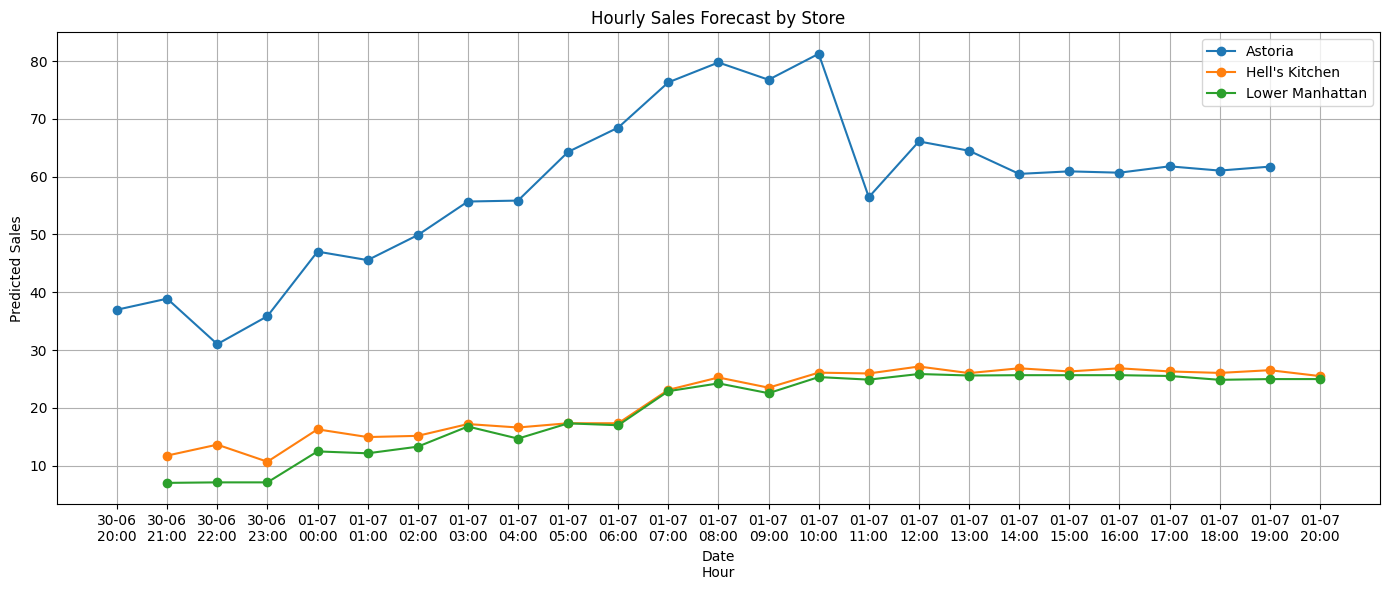

In [182]:
plt.figure(figsize=(14,6))

for store in final_hourly_quantity_forecast['Store'].unique():
    temp = final_hourly_quantity_forecast[final_hourly_quantity_forecast['Store'] == store]

    labels = temp['Datetime'].dt.strftime('%d-%m\n%H:%M')

    plt.plot(labels,
             temp['Predicted_Hourly_Quantity'],
             marker='o',
             label=store)

plt.title("Hourly Sales Forecast by Store")
plt.xlabel("Date\nHour")
plt.ylabel("Predicted Sales")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [183]:
print(len(future_dates))
print(len(revenue_predictions))
print(len([store] * len(future_dates)))

24
30
24


In [184]:
# ===================================================
# FORECASTING HOURLY REVENUE
# ===================================================

import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# ===================================================
# CREATE HOURLY REVENUE DATA
# ===================================================

hourly_revenue_sales = (
    df.groupby(['transaction_date', 'hour', 'store_location'])['revenue']
      .sum()
      .reset_index()
)

hourly_revenue_sales['transaction_date'] = pd.to_datetime(hourly_revenue_sales['transaction_date'])

# ===================================================
# FEATURE ENGINEERING
# ===================================================

hourly_revenue_sales = hourly_revenue_sales.sort_values(
    ['store_location', 'transaction_date', 'hour']
)

hourly_revenue_sales['Day'] = hourly_revenue_sales['transaction_date'].dt.day
hourly_revenue_sales['Month'] = hourly_revenue_sales['transaction_date'].dt.month
hourly_revenue_sales['Weekday'] = hourly_revenue_sales['transaction_date'].dt.dayofweek

hourly_revenue_sales['lag_1'] = hourly_revenue_sales.groupby('store_location')['revenue'].shift(1)
hourly_revenue_sales['lag_7'] = hourly_revenue_sales.groupby('store_location')['revenue'].shift(7)
hourly_revenue_sales['lag_30'] = hourly_revenue_sales.groupby('store_location')['revenue'].shift(30)

hourly_revenue_sales['rolling_3'] = (
    hourly_revenue_sales.groupby('store_location')['revenue']
    .transform(lambda x: x.rolling(3).mean())
)

hourly_revenue_sales['rolling_7'] = (
    hourly_revenue_sales.groupby('store_location')['revenue']
    .transform(lambda x: x.rolling(7).mean())
)

hourly_revenue_sales = hourly_revenue_sales.dropna()

# ===================================================
# TRAIN MODEL
# ===================================================

X = hourly_revenue_sales[
    [
        'Day',
        'Month',
        'Weekday',
        'hour',
        'lag_1',
        'lag_7',
        'lag_30',
        'rolling_3',
        'rolling_7'
    ]
]

y = hourly_revenue_sales['revenue']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

revenue_gbr_hourly = GradientBoostingRegressor(random_state=42)

revenue_gbr_hourly.fit(X_train, y_train)
hourly_revenue_pred = revenue_gbr_hourly.predict(X_test)

print("MAE :", mean_absolute_error(y_test, hourly_revenue_pred))
print("R2 Score :", r2_score(y_test, hourly_revenue_pred))
hourly_revenue_residuals = y_test - hourly_revenue_pred

hourly_revenue_residual_std = np.std(
    hourly_revenue_residuals,
    ddof=1
)

hourly_revenue_lower_95 = (
    hourly_revenue_pred - 1.96 * hourly_revenue_residual_std
)

hourly_revenue_upper_95 = (
    hourly_revenue_pred + 1.96 * hourly_revenue_residual_std
)

hourly_revenue_lower_95 = np.maximum(
    hourly_revenue_lower_95,
    0
)

# ===================================================
# FORECAST NEXT 24 HOURS
# ===================================================

stores = hourly_revenue_sales['store_location'].unique()

all_revenue_forecasts = []

for store in stores:

    print("\nForecast for:", store)

    store_data = hourly_revenue_sales[
        hourly_revenue_sales['store_location'] == store
    ].copy()

    history = store_data['revenue'].tolist()

    last_datetime = (
        pd.Timestamp(str(store_data['transaction_date'].max().date()))
        + pd.Timedelta(hours=int(store_data['hour'].max()))
    )

    future_dates = pd.date_range(
        start=last_datetime + pd.Timedelta(hours=1),
        periods=24,
        freq='h'
    )

    revenue_predictions = []

    # -----------------------------
    # Recursive Forecast
    # -----------------------------

    for dt in future_dates:

        lag_1 = history[-1]
        lag_7 = history[-7]
        lag_30 = history[-30]

        rolling_3 = sum(history[-3:]) / 3
        rolling_7 = sum(history[-7:]) / 7

        x = pd.DataFrame({
            'Day': [dt.day],
            'Month': [dt.month],
            'Weekday': [dt.dayofweek],
            'hour': [dt.hour],
            'lag_1': [lag_1],
            'lag_7': [lag_7],
            'lag_30': [lag_30],
            'rolling_3': [rolling_3],
            'rolling_7': [rolling_7]
        })

        pred = revenue_gbr_hourly.predict(x)[0]

        revenue_predictions.append(pred)

        history.append(pred)

    # -----------------------------
    # Safety Check
    # -----------------------------

    if len(revenue_predictions) != len(future_dates):
        raise ValueError(
            f"Length mismatch for {store}: "
            f"{len(future_dates)} dates and "
            f"{len(revenue_predictions)} predictions."
        )

    # -----------------------------
    # Forecast DataFrame
    # -----------------------------

    hourly_revenue_forecast = pd.DataFrame({
        'Datetime': future_dates,
        'Store': [store] * len(future_dates),
        'Predicted_Hourly_Revenue': revenue_predictions
    })

    all_revenue_forecasts.append(hourly_revenue_forecast)

# ===================================================
# FINAL OUTPUT
# ===================================================

final_hourly_revenue_forecast = pd.concat(
    all_revenue_forecasts,
    ignore_index=True
)


print(final_hourly_revenue_forecast)


MAE : 22.10356741458924
R2 Score : 0.814215277134632

Forecast for: Astoria

Forecast for: Hell's Kitchen

Forecast for: Lower Manhattan
              Datetime            Store  Predicted_Hourly_Revenue
0  2023-06-30 20:00:00          Astoria                120.090321
1  2023-06-30 21:00:00          Astoria                123.000358
2  2023-06-30 22:00:00          Astoria                117.027243
3  2023-06-30 23:00:00          Astoria                117.398430
4  2023-07-01 00:00:00          Astoria                171.795109
..                 ...              ...                       ...
67 2023-07-01 16:00:00  Lower Manhattan                116.849701
68 2023-07-01 17:00:00  Lower Manhattan                114.060795
69 2023-07-01 18:00:00  Lower Manhattan                121.324285
70 2023-07-01 19:00:00  Lower Manhattan                118.348875
71 2023-07-01 20:00:00  Lower Manhattan                122.163940

[72 rows x 3 columns]


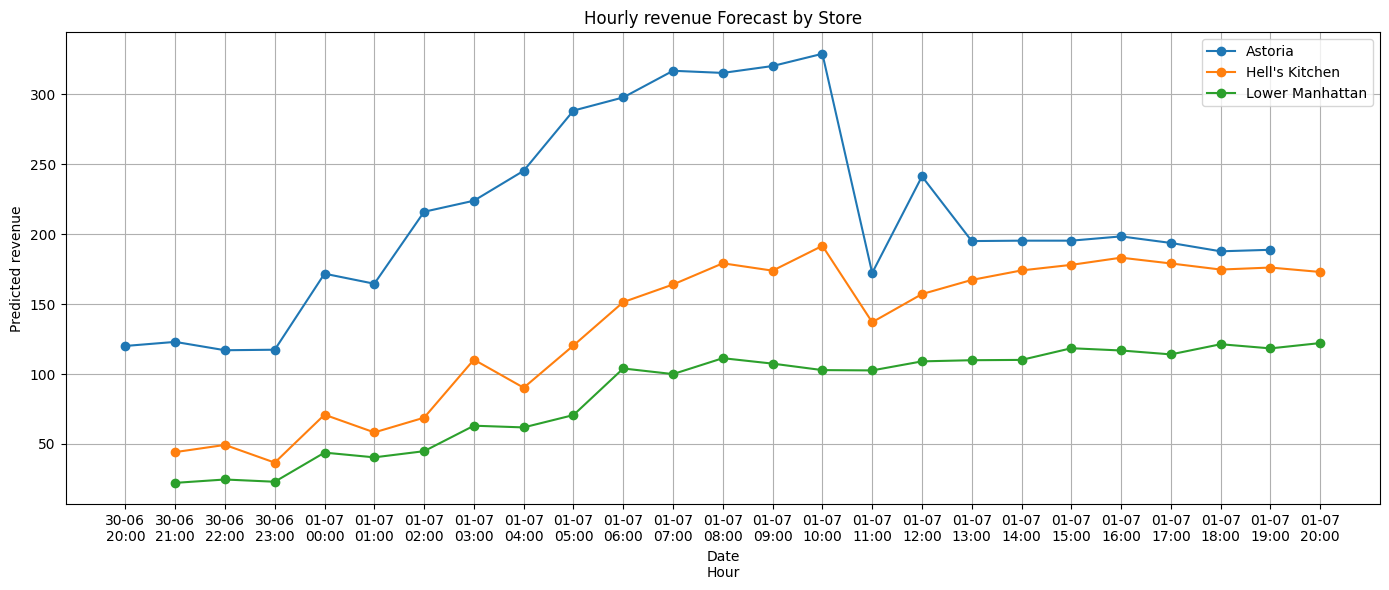

In [185]:
plt.figure(figsize=(14,6))

for store in final_hourly_revenue_forecast['Store'].unique():
    temp = final_hourly_revenue_forecast[final_hourly_revenue_forecast['Store'] == store]

    labels = temp['Datetime'].dt.strftime('%d-%m\n%H:%M')

    plt.plot(labels,
             temp['Predicted_Hourly_Revenue'],
             marker='o',
             label=store)

plt.title("Hourly revenue Forecast by Store")
plt.xlabel("Date\nHour")
plt.ylabel("Predicted revenue")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [186]:
# ============================================================
# DAILY QUANTITY FORECAST - ALL 3 STORES
# ============================================================

import pandas as pd
import numpy as np

# Make a separate copy - original df will NOT be changed
temp_df = df.copy()

# Your date is ALREADY datetime
temp_df["transaction_date"] = pd.to_datetime(
    temp_df["transaction_date"],
    errors="coerce"
)

# Get all stores
stores = temp_df["store_location"].dropna().unique()

print("Stores being forecast:")
print(stores)

all_quantity_forecasts = []

for store in stores:

    print("\nForecasting Daily Quantity:", store)

    store_data = temp_df[
        temp_df["store_location"] == store
    ].copy()

    # Daily quantity
    store_sales = (
        store_data
        .groupby("transaction_date")["transaction_qty"]
        .sum()
        .sort_index()
    )

    if len(store_sales) < 30:
        print("Not enough data for:", store)
        continue

    history = store_sales.astype(float).tolist()

    # Last date
    last_date = pd.Timestamp(
        store_sales.index.max()
    )

    # Next 30 days
    future_dates = pd.date_range(
        start=last_date + pd.Timedelta(days=1),
        periods=30,
        freq="D"
    )

    predictions = []

    for dt in future_dates:

        X_future = pd.DataFrame({
            "Day": [dt.day],
            "Month": [dt.month],
            "Weekday": [dt.dayofweek],
            "lag_1": [history[-1]],
            "lag_7": [history[-7]],
            "lag_30": [history[-30]],
            "rolling_3": [np.mean(history[-3:])],
            "rolling_7": [np.mean(history[-7:])]
        })

        prediction = gb_daily_model.predict(
            X_future
        )[0]

        prediction = max(0, float(prediction))

        predictions.append(prediction)

        # Add prediction to history for next day
        history.append(prediction)

    # 95% interval
    lower_95 = np.maximum(
        0,
        np.array(predictions) -
        1.96 * quantity_residual_sd
    )

    upper_95 = (
        np.array(predictions) +
        1.96 * quantity_residual_sd
    )

    forecast_df = pd.DataFrame({

        "Date": future_dates,

        "Store": store,

        "Predicted_quantity": predictions,

        "Lower_95": lower_95,

        "Upper_95": upper_95
    })

    all_quantity_forecasts.append(
        forecast_df
    )


# Combine all stores
daily_quantity_forecast = pd.concat(
    all_quantity_forecasts,
    ignore_index=True
)


# Save to Google Drive
daily_quantity_forecast.to_csv(
    "/content/drive/MyDrive/daily_quantity_forecast.csv",
    index=False
)


print("\n===================================")
print("DAILY QUANTITY FORECAST COMPLETED")
print("===================================")

print(
    daily_quantity_forecast["Store"].value_counts()
)

print("\nStores:")
print(
    daily_quantity_forecast["Store"].unique()
)

print("\nTotal rows:")
print(
    len(daily_quantity_forecast)
)
print(daily_quantity_forecast)

Stores being forecast:
['Lower Manhattan' "Hell's Kitchen" 'Astoria']

Forecasting Daily Quantity: Lower Manhattan

Forecasting Daily Quantity: Hell's Kitchen

Forecasting Daily Quantity: Astoria

DAILY QUANTITY FORECAST COMPLETED
Store
Lower Manhattan    30
Hell's Kitchen     30
Astoria            30
Name: count, dtype: int64

Stores:
['Lower Manhattan' "Hell's Kitchen" 'Astoria']

Total rows:
90
         Date            Store  Predicted_quantity    Lower_95     Upper_95
0  2023-07-01  Lower Manhattan          786.690885  587.659559   985.722212
1  2023-07-02  Lower Manhattan          811.862875  612.831549  1010.894202
2  2023-07-03  Lower Manhattan          793.307176  594.275850   992.338502
3  2023-07-04  Lower Manhattan          804.764514  605.733188  1003.795840
4  2023-07-05  Lower Manhattan          798.866118  599.834792   997.897444
..        ...              ...                 ...         ...          ...
85 2023-07-26          Astoria         1071.048814  872.017488  127

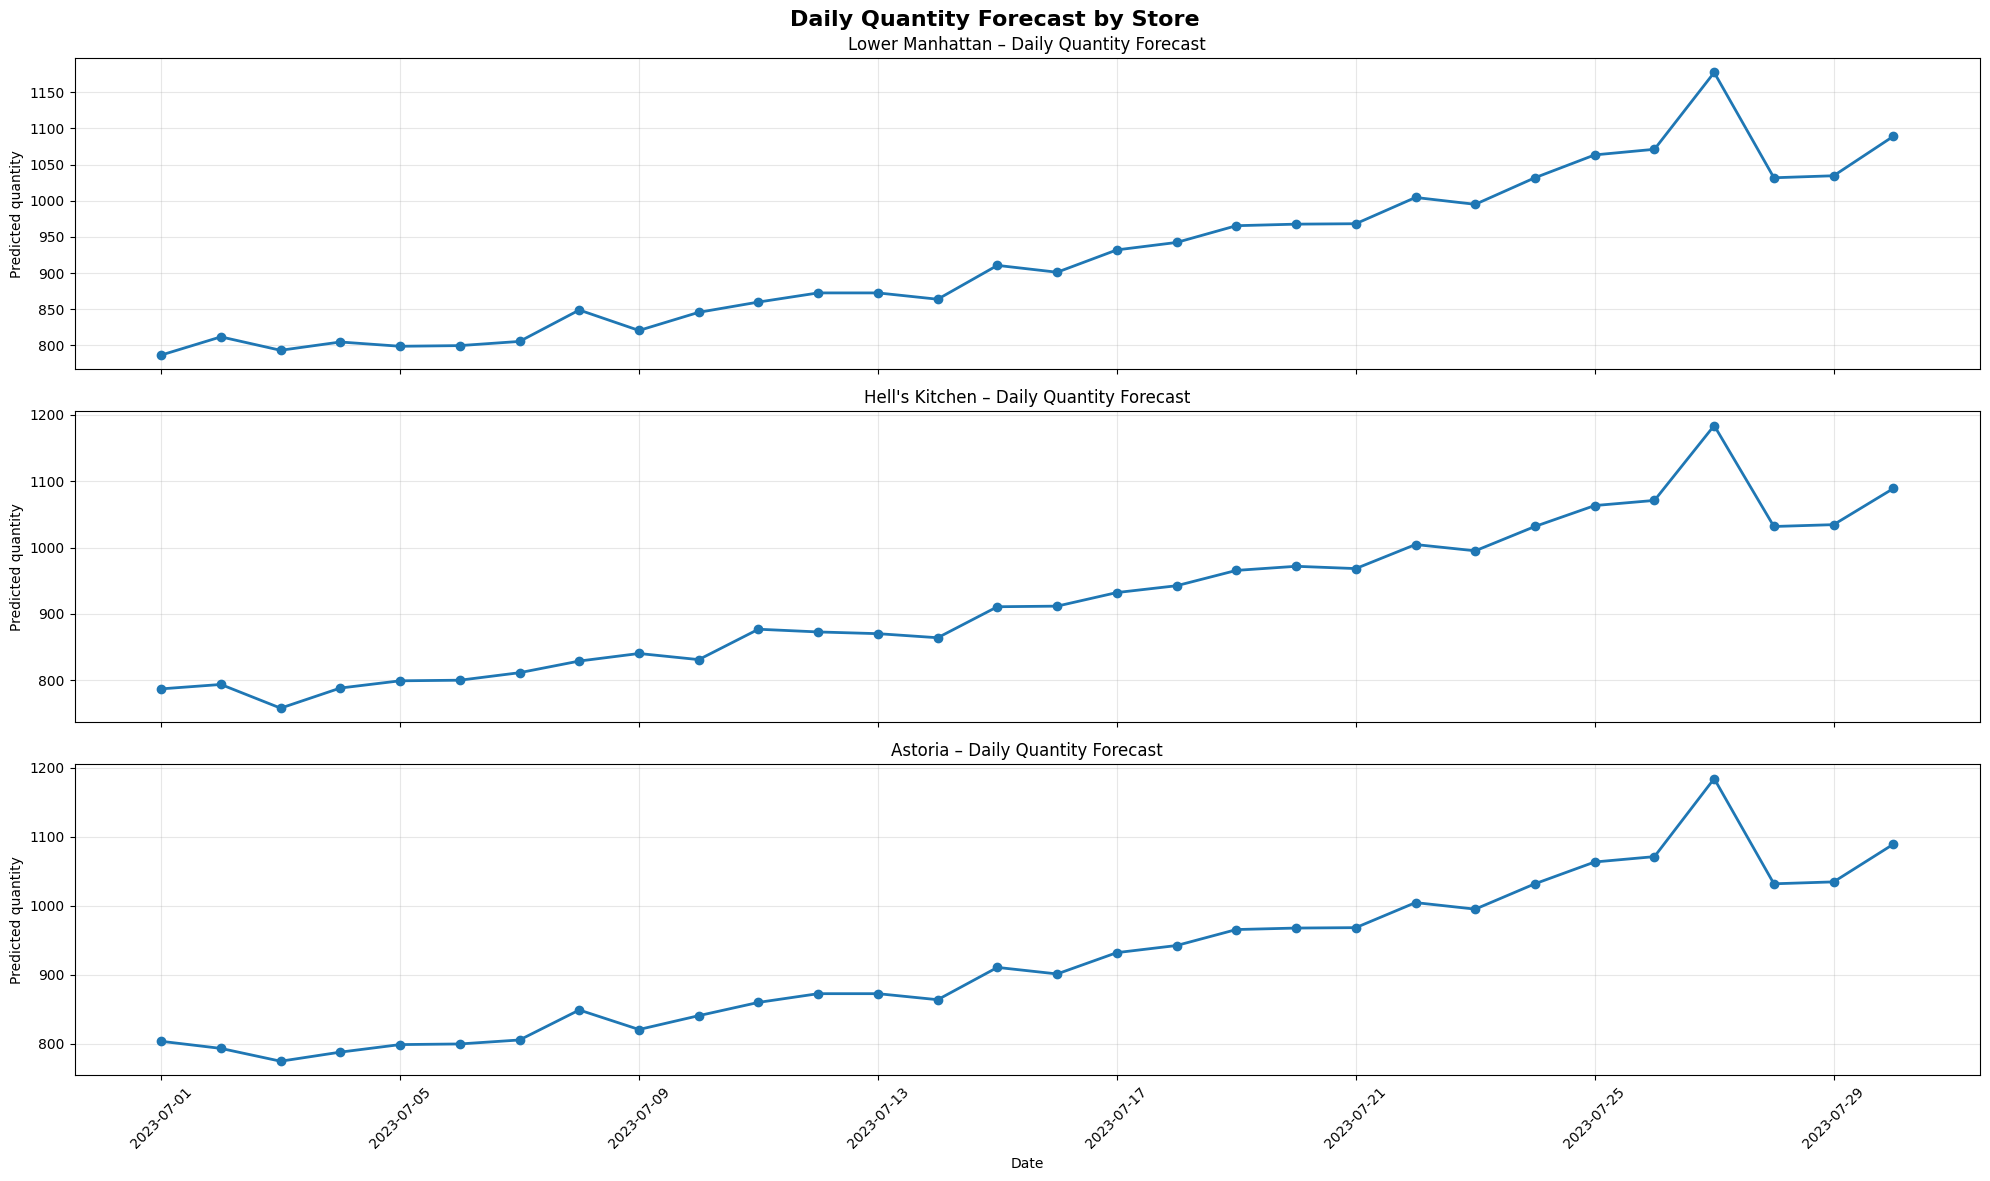

In [187]:
import matplotlib.pyplot as plt

stores = daily_quantity_forecast["Store"].unique()

fig, axes = plt.subplots(3, 1, figsize=(20, 12), sharex=True)

for ax, store in zip(axes, stores):
    data = daily_quantity_forecast[
        daily_quantity_forecast["Store"] == store
    ]

    ax.plot(
        data["Date"],
        data["Predicted_quantity"],
        marker="o",
        linewidth=2
    )

    ax.set_title(f"{store} – Daily Quantity Forecast")
    ax.set_ylabel("Predicted quantity")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Date")

plt.suptitle(
    "Daily Quantity Forecast by Store",
    fontsize=16,
    fontweight="bold"
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [188]:
# ============================================================
# DAILY REVENUE FORECAST - ALL 3 STORES
# ============================================================

import pandas as pd
import numpy as np

# Separate copy - original df will NOT be changed
temp_df = df.copy()

# Date is already datetime
temp_df["transaction_date"] = pd.to_datetime(
    temp_df["transaction_date"],
    errors="coerce"
)

# Get all stores
stores = temp_df["store_location"].dropna().unique()

print("Stores being forecast:")
print(stores)

all_revenue_forecasts = []

for store in stores:

    print("\nForecasting Daily Revenue:", store)

    store_data = temp_df[
        temp_df["store_location"] == store
    ].copy()

    # Daily revenue
    store_sales = (store_data.groupby("transaction_date")["revenue"].sum().sort_index())

    if len(store_sales) < 30:
        print("Not enough data for:", store)
        continue

    history = store_sales.astype(float).tolist()

    # Last date
    last_date = pd.Timestamp(
        store_sales.index.max()
    )

    # Next 30 days
    future_dates = pd.date_range(
        start=last_date + pd.Timedelta(days=1),
        periods=30,
        freq="D"
    )

    predictions = []

    for dt in future_dates:

        X_future = pd.DataFrame({
            "Day": [dt.day],
            "Month": [dt.month],
            "Weekday": [dt.dayofweek],
            "lag_1": [history[-1]],
            "lag_7": [history[-7]],
            "lag_30": [history[-30]],
            "rolling_3": [np.mean(history[-3:])],
            "rolling_7": [np.mean(history[-7:])]
        })

        prediction = revenue_gbr.predict(
            X_future
        )[0]

        prediction = max(0, float(prediction))

        predictions.append(prediction)

        # Add prediction to history
        history.append(prediction)

    # 95% interval
    lower_95 = np.maximum(
        0,
        np.array(predictions) -
        1.96 * revenue_residual_sd
    )

    upper_95 = (
        np.array(predictions) +
        1.96 * revenue_residual_sd
    )

    forecast_df = pd.DataFrame({

        "Date": future_dates,

        "Store": store,

        "Predicted_revenue": predictions,

        "Lower_95": lower_95,

        "Upper_95": upper_95
    })

    all_revenue_forecasts.append(
        forecast_df
    )


# Combine all stores
daily_revenue_forecast = pd.concat(
    all_revenue_forecasts,
    ignore_index=True
)


# Save to Google Drive
daily_revenue_forecast.to_csv(
    "/content/drive/MyDrive/daily_revenue_forecast.csv",
    index=False
)


print("\n===================================")
print("DAILY REVENUE FORECAST COMPLETED")
print("===================================")

print(
    daily_revenue_forecast["Store"].value_counts()
)

print("\nStores:")
print(
    daily_revenue_forecast["Store"].unique()
)

print("\nTotal rows:")
print(
    len(daily_revenue_forecast)
)
print(daily_revenue_forecast)

Stores being forecast:
['Lower Manhattan' "Hell's Kitchen" 'Astoria']

Forecasting Daily Revenue: Lower Manhattan

Forecasting Daily Revenue: Hell's Kitchen

Forecasting Daily Revenue: Astoria

DAILY REVENUE FORECAST COMPLETED
Store
Lower Manhattan    30
Hell's Kitchen     30
Astoria            30
Name: count, dtype: int64

Stores:
['Lower Manhattan' "Hell's Kitchen" 'Astoria']

Total rows:
90
         Date            Store  Predicted_revenue     Lower_95     Upper_95
0  2023-07-01  Lower Manhattan        5361.770568  4463.402279  6260.138857
1  2023-07-02  Lower Manhattan        5546.939192  4648.570903  6445.307481
2  2023-07-03  Lower Manhattan        5577.685680  4679.317391  6476.053969
3  2023-07-04  Lower Manhattan        5441.280294  4542.912005  6339.648583
4  2023-07-05  Lower Manhattan        5516.731883  4618.363594  6415.100172
..        ...              ...                ...          ...          ...
85 2023-07-26          Astoria        5390.434511  4492.066222  6288.80

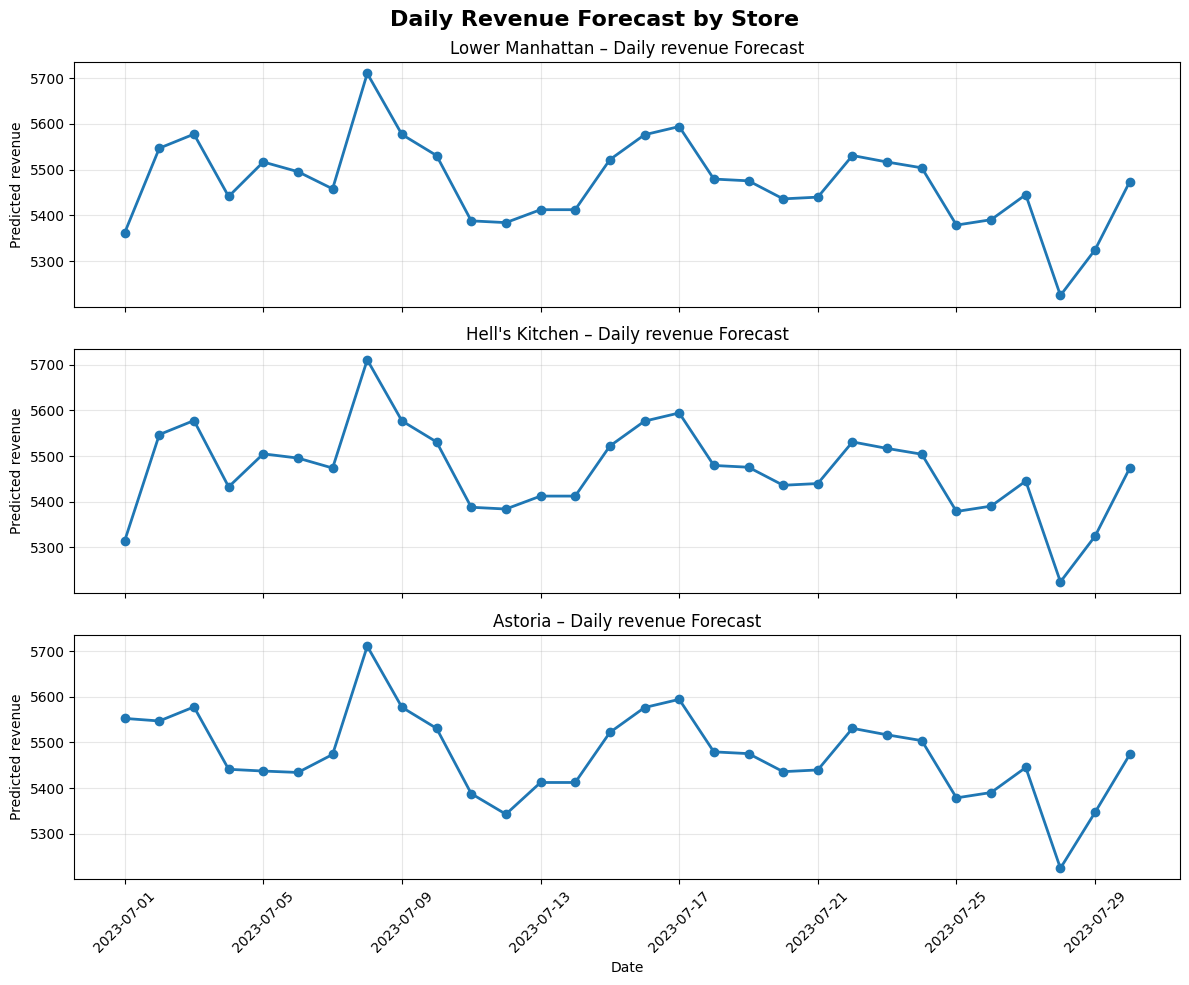

In [189]:
import matplotlib.pyplot as plt

stores = daily_revenue_forecast["Store"].unique()

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

for ax, store in zip(axes, stores):
    data = daily_revenue_forecast[
        daily_revenue_forecast["Store"] == store
    ]

    ax.plot(
        data["Date"],
        data["Predicted_revenue"],
        marker="o",
        linewidth=2
    )

    ax.set_title(f"{store} – Daily revenue Forecast")
    ax.set_ylabel("Predicted revenue")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Date")

plt.suptitle(
    "Daily Revenue Forecast by Store",
    fontsize=16,
    fontweight="bold"
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [190]:
print(len(revenue_predictions))

24


In [191]:
print(len(future_dates))
print(len(revenue_predictions))
print(len([store] * len(future_dates)))

30
24
30


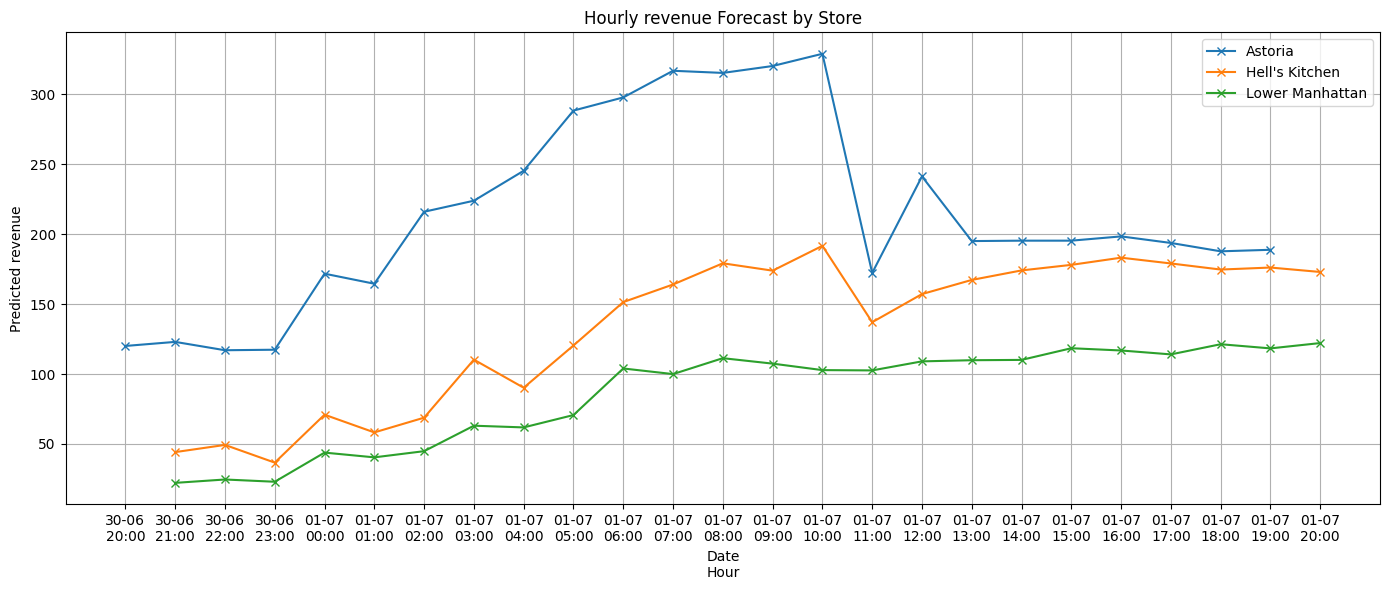

In [192]:
plt.figure(figsize=(14,6))

for store in final_hourly_revenue_forecast['Store'].unique():
    temp = final_hourly_revenue_forecast[final_hourly_revenue_forecast['Store'] == store]

    labels = temp['Datetime'].dt.strftime('%d-%m\n%H:%M')

    plt.plot(labels,
             temp['Predicted_Hourly_Revenue'],
             marker='x',
             label=store)

plt.title("Hourly revenue Forecast by Store")
plt.xlabel("Date\nHour")
plt.ylabel("Predicted revenue")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

 Identify upcoming peak-demand periods


In [193]:
print(peak_demand)

    transaction_date   store_location  transaction_qty  revenue
507       2023-06-19          Astoria              688  2546.43
490       2023-06-13   Hell's Kitchen              769  2534.80
533       2023-06-27  Lower Manhattan              770  2437.40


Upcoming Top 10 Peak quantity Days:
         Date            Store  Predicted_quantity
86 2023-07-27          Astoria         1184.035037
56 2023-07-27   Hell's Kitchen         1184.035037
26 2023-07-27  Lower Manhattan         1177.213487
29 2023-07-30  Lower Manhattan         1089.047367
89 2023-07-30          Astoria         1089.047367
59 2023-07-30   Hell's Kitchen         1089.047367
55 2023-07-26   Hell's Kitchen         1071.048814
85 2023-07-26          Astoria         1071.048814
25 2023-07-26  Lower Manhattan         1071.048814
24 2023-07-25  Lower Manhattan         1063.298831


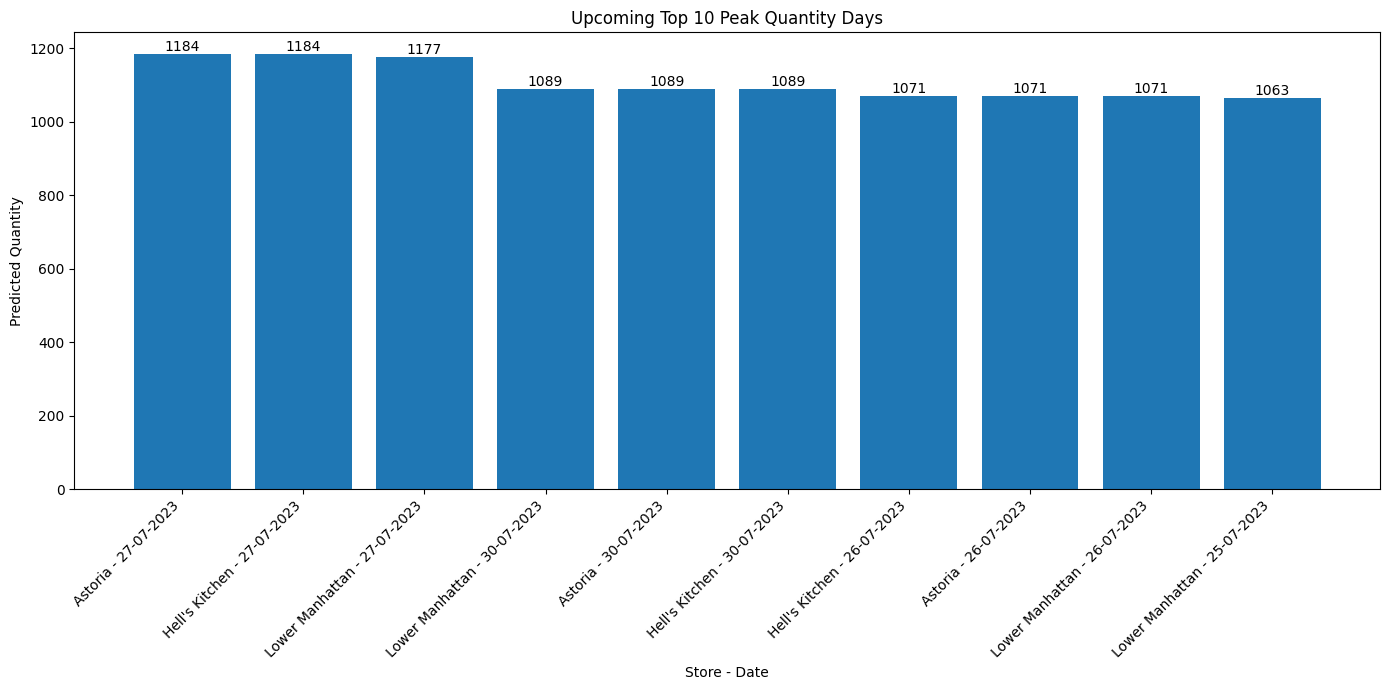

In [194]:
#Upcoming top 10 peak revenue days
# ============================================================
# UPCOMING TOP 10 PEAK REVENUE DAYS
# ============================================================

upcoming_peak_quantity = (
    daily_quantity_forecast
    .sort_values(
        by='Predicted_quantity',
        ascending=False
    )
    .head(10)
)

print("Upcoming Top 10 Peak quantity Days:")
print(
    upcoming_peak_quantity[
        ['Date', 'Store', 'Predicted_quantity']
    ]
)

# Plot
plt.figure(figsize=(14, 7))

labels = (
    upcoming_peak_quantity['Store']
    + " - "
    + upcoming_peak_quantity['Date'].dt.strftime('%d-%m-%Y')
)

bars = plt.bar(
    labels,
    upcoming_peak_quantity['Predicted_quantity']
)

plt.bar_label(bars, fmt='%.0f')

plt.title("Upcoming Top 10 Peak Quantity Days")
plt.xlabel("Store - Date")
plt.ylabel("Predicted Quantity")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

Upcoming Top 10 Peak Revenue Days:
         Date            Store  Predicted_revenue
7  2023-07-08  Lower Manhattan        5710.480897
37 2023-07-08   Hell's Kitchen        5710.480897
67 2023-07-08          Astoria        5710.480897
76 2023-07-17          Astoria        5594.269063
46 2023-07-17   Hell's Kitchen        5594.269063
16 2023-07-17  Lower Manhattan        5594.269063
2  2023-07-03  Lower Manhattan        5577.685680
32 2023-07-03   Hell's Kitchen        5577.685680
62 2023-07-03          Astoria        5577.685680
8  2023-07-09  Lower Manhattan        5576.869798


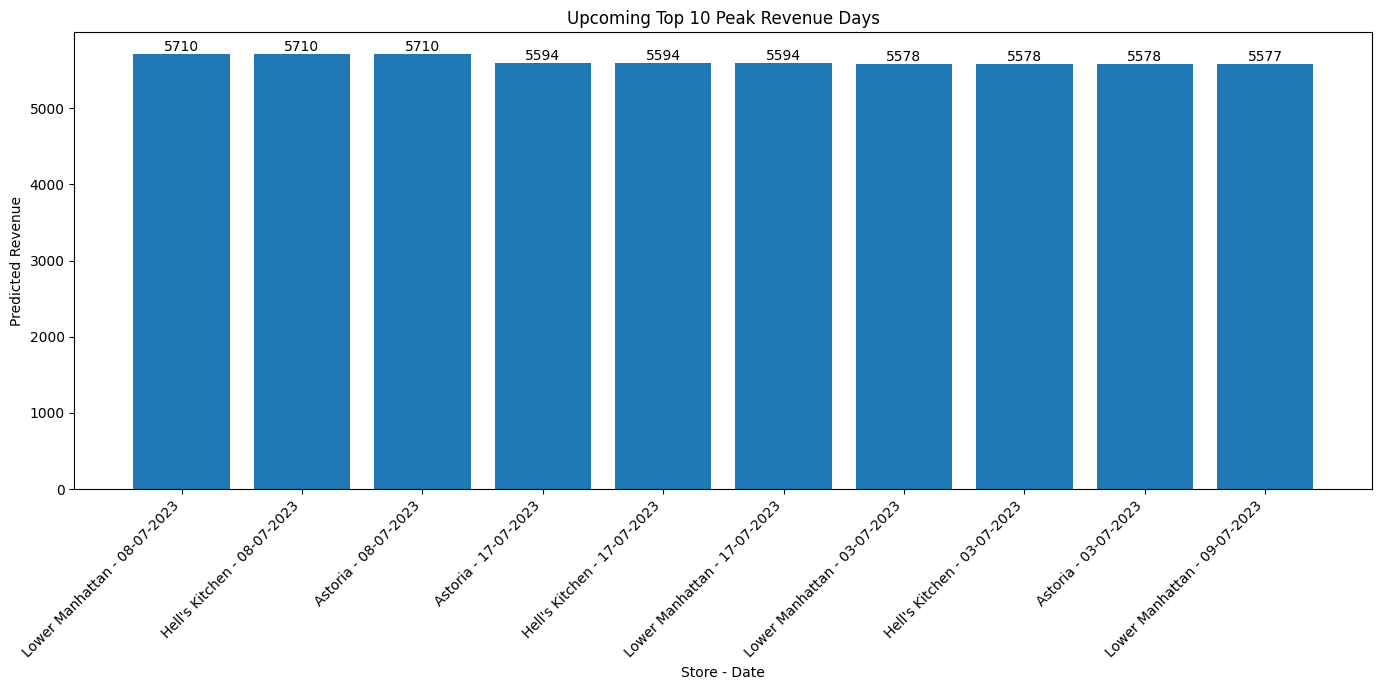

In [195]:
#Upcoming top 10 peak revenue days
# ============================================================
# UPCOMING TOP 10 PEAK REVENUE DAYS
# ============================================================

upcoming_peak_revenue = (
    daily_revenue_forecast
    .sort_values(
        by='Predicted_revenue',
        ascending=False
    )
    .head(10)
)

print("Upcoming Top 10 Peak Revenue Days:")
print(
    upcoming_peak_revenue[
        ['Date', 'Store', 'Predicted_revenue']
    ]
)

# Plot
plt.figure(figsize=(14, 7))

labels = (
    upcoming_peak_revenue['Store']
    + " - "
    + upcoming_peak_revenue['Date'].dt.strftime('%d-%m-%Y')
)

bars = plt.bar(
    labels,
    upcoming_peak_revenue['Predicted_revenue']
)

plt.bar_label(bars, fmt='%.0f')

plt.title("Upcoming Top 10 Peak Revenue Days")
plt.xlabel("Store - Date")
plt.ylabel("Predicted Revenue")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

Upcoming Top 10 Peak Quantity Days:
         Date            Store  Predicted_quantity
86 2023-07-27          Astoria         1184.035037
56 2023-07-27   Hell's Kitchen         1184.035037
26 2023-07-27  Lower Manhattan         1177.213487
29 2023-07-30  Lower Manhattan         1089.047367
89 2023-07-30          Astoria         1089.047367
59 2023-07-30   Hell's Kitchen         1089.047367
55 2023-07-26   Hell's Kitchen         1071.048814
85 2023-07-26          Astoria         1071.048814
25 2023-07-26  Lower Manhattan         1071.048814
24 2023-07-25  Lower Manhattan         1063.298831


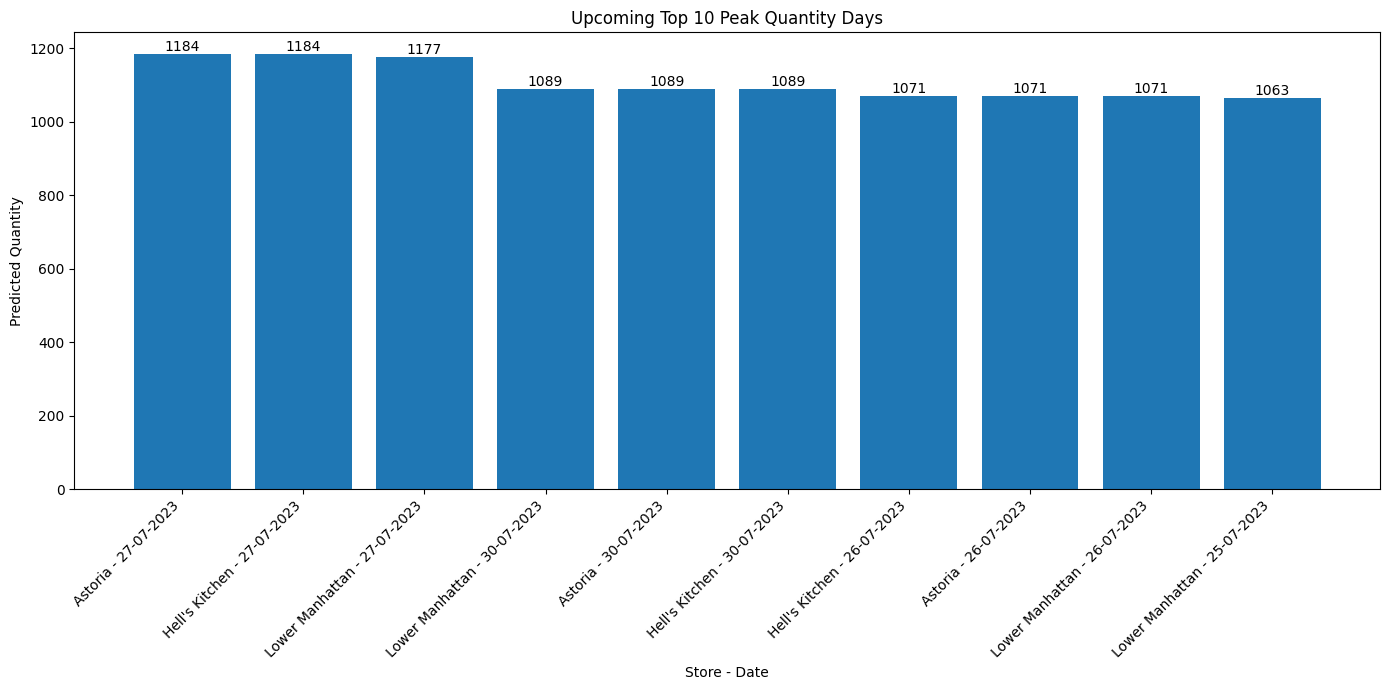

In [196]:
#Upcoming top 10 peak  days based on quantity
# ============================================================
# TOP 10 PEAK QUANTITY DAYS
# ============================================================

upcoming_peak_quantity = (
    daily_quantity_forecast
    .sort_values(
        by='Predicted_quantity',
        ascending=False
    )
    .head(10)
)

print("Upcoming Top 10 Peak Quantity Days:")
print(
    upcoming_peak_quantity[
        ['Date', 'Store', 'Predicted_quantity']
    ]
)

# Plot
plt.figure(figsize=(14, 7))

labels = (
    upcoming_peak_quantity['Store']
    + " - "
    + upcoming_peak_quantity['Date'].dt.strftime('%d-%m-%Y')
)

bars = plt.bar(
    labels,
    upcoming_peak_quantity['Predicted_quantity']
)

plt.bar_label(bars, fmt='%.0f')

plt.title("Upcoming Top 10 Peak Quantity Days")
plt.xlabel("Store - Date")
plt.ylabel("Predicted Quantity")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [197]:
#Prediction interval
mae_quant = mean_absolute_error(y_test_daily,daily_pred)
print(mae_quant)

86.1185266882052


In [198]:
#Prediction interval
mae_rev = mean_absolute_error(y_test_rev,y_pred_rev)
print(mae_rev)

406.72324567467984


In [199]:
daily_quantity_forecast['lower_bound'] = daily_quantity_forecast['Predicted_quantity'] - mae_quant
daily_quantity_forecast['Upper_bound'] = daily_quantity_forecast['Predicted_quantity'] + mae_quant
print(daily_quantity_forecast[['Predicted_quantity','lower_bound','Upper_bound']].head())

   Predicted_quantity  lower_bound  Upper_bound
0          786.690885   700.572359   872.809412
1          811.862875   725.744349   897.981402
2          793.307176   707.188649   879.425703
3          804.764514   718.645987   890.883041
4          798.866118   712.747591   884.984644


In [200]:
daily_revenue_forecast['lower_bound'] = daily_revenue_forecast['Predicted_revenue'] - mae_rev
daily_revenue_forecast['Upper_bound'] = daily_revenue_forecast['Predicted_revenue'] + mae_rev
print(daily_revenue_forecast[['Predicted_revenue','lower_bound','Upper_bound']].head())

   Predicted_revenue  lower_bound  Upper_bound
0        5361.770568  4955.047323  5768.493814
1        5546.939192  5140.215946  5953.662437
2        5577.685680  5170.962434  5984.408926
3        5441.280294  5034.557048  5848.003539
4        5516.731883  5110.008637  5923.455129


In [201]:
#Best-case vs Worst-case Demand scenarios
daily_quantity_forecast['best_case'] = daily_quantity_forecast['Predicted_quantity'] * 1.15
daily_quantity_forecast['worst_case'] = daily_quantity_forecast['Predicted_quantity'] * 0.85
print("Best-case vs Worst-case demand scenarios:")
print(daily_quantity_forecast[['Predicted_quantity','best_case','worst_case']].head())

Best-case vs Worst-case demand scenarios:
   Predicted_quantity   best_case  worst_case
0          786.690885  904.694518  668.687253
1          811.862875  933.642307  690.083444
2          793.307176  912.303253  674.311100
3          804.764514  925.479191  684.049837
4          798.866118  918.696035  679.036200


In [202]:
#Sensitivity to Demand spikes
threshold = daily_quantity_forecast['Predicted_quantity'].mean() * 1.10
spikes = daily_quantity_forecast[daily_quantity_forecast['Predicted_quantity'] > threshold]
print('Demand spikes Days')
print(spikes[['Predicted_quantity']])

Demand spikes Days
    Predicted_quantity
23         1031.766950
24         1063.298831
25         1071.048814
26         1177.213487
27         1031.707618
28         1034.483335
29         1089.047367
53         1031.766950
54         1063.298831
55         1071.048814
56         1184.035037
57         1031.707618
58         1034.483335
59         1089.047367
83         1031.766950
84         1063.298831
85         1071.048814
86         1184.035037
87         1031.707618
88         1034.483335
89         1089.047367


In [203]:
print(gb_daily_model.feature_names_in_)

['Day' 'Month' 'Weekday' 'lag_1' 'lag_7' 'lag_30' 'rolling_3' 'rolling_7']


In [204]:
print(gb_hourly_model.feature_names_in_)

['Day' 'Month' 'Weekday' 'hour' 'lag_1' 'lag_7' 'lag_30' 'rolling_3'
 'rolling_7']


In [205]:
print(revenue_gbr.feature_names_in_)

['Day' 'Month' 'Weekday' 'lag_1' 'lag_7' 'lag_30' 'rolling_3' 'rolling_7']


In [206]:
print(revenue_gbr_hourly.feature_names_in_)

['Day' 'Month' 'Weekday' 'hour' 'lag_1' 'lag_7' 'lag_30' 'rolling_3'
 'rolling_7']


In [207]:
#SAVE DATA FOR STREAMLIT DASHBOARD
# Save data for Streamlit Dashboard
df.to_csv("/content/drive/MyDrive/df.csv", index=False)

# Daily quantity
daily_quantity_forecast.to_csv(
    "/content/drive/MyDrive/daily_quantity_forecast.csv",
    index=False
)

# Daily revenue
daily_revenue_forecast.to_csv(
    "/content/drive/MyDrive/daily_revenue_forecast.csv",
    index=False
)

# Hourly quantity
final_hourly_quantity_forecast.to_csv(
    "/content/drive/MyDrive/hourly_quantity_forecast.csv",
    index=False
)

# Hourly revenue
final_hourly_revenue_forecast.to_csv(
    "/content/drive/MyDrive/hourly_revenue_forecast.csv",
    index=False
)
performance_quantity.to_csv(
    "/content/drive/MyDrive/performance_quantity.csv",
    index=False
)

performance_revenue.to_csv(
    "/content/drive/MyDrive/performance_revenue.csv",
    index=False
)

In [208]:
import os

files = [
    "/content/drive/MyDrive/df.csv",
    "/content/drive/MyDrive/daily_quantity_forecast.csv",
    "/content/drive/MyDrive/daily_revenue_forecast.csv",
    "/content/drive/MyDrive/hourly_quantity_forecast.csv",
    "/content/drive/MyDrive/hourly_revenue_forecast.csv",
    "/content/drive/MyDrive/performance_quantity.csv",
    "/content/drive/MyDrive/performance_revenue.csv"
]

for file in files:
    if os.path.exists(file):
        print("✅ FOUND:", file)
    else:
        print("❌ NOT FOUND:", file)

✅ FOUND: /content/drive/MyDrive/df.csv
✅ FOUND: /content/drive/MyDrive/daily_quantity_forecast.csv
✅ FOUND: /content/drive/MyDrive/daily_revenue_forecast.csv
✅ FOUND: /content/drive/MyDrive/hourly_quantity_forecast.csv
✅ FOUND: /content/drive/MyDrive/hourly_revenue_forecast.csv
✅ FOUND: /content/drive/MyDrive/performance_quantity.csv
✅ FOUND: /content/drive/MyDrive/performance_revenue.csv


In [209]:
import pandas as pd

files = {
    "DATA": "/content/drive/MyDrive/df.csv",
    "DAILY QUANTITY": "/content/drive/MyDrive/daily_quantity_forecast.csv",
    "DAILY REVENUE": "/content/drive/MyDrive/daily_revenue_forecast.csv",
    "HOURLY QUANTITY": "/content/drive/MyDrive/hourly_quantity_forecast.csv",
    "HOURLY REVENUE": "/content/drive/MyDrive/hourly_revenue_forecast.csv",
    "PERFORMANCE QUANTITY": "/content/drive/MyDrive/performance_quantity.csv",
    "PERFORMANCE REVENUE": "/content/drive/MyDrive/performance_revenue.csv"
}

for name, path in files.items():
    data = pd.read_csv(path)

    print("\n==============================")
    print(name)
    print("==============================")
    print(data.columns.tolist())
    print("Rows:", len(data))


DATA
['transaction_id', 'transaction_date', 'transaction_time', 'transaction_qty', 'store_id', 'store_location', 'product_id', 'unit_price', 'product_category', 'product_type', 'product_detail', 'hour', 'minute', 'revenue', 'day_name', 'day_type']
Rows: 149116

DAILY QUANTITY
['Date', 'Store', 'Predicted_quantity', 'Lower_95', 'Upper_95', 'lower_bound', 'Upper_bound', 'best_case', 'worst_case']
Rows: 90

DAILY REVENUE
['Date', 'Store', 'Predicted_revenue', 'Lower_95', 'Upper_95', 'lower_bound', 'Upper_bound']
Rows: 90

HOURLY QUANTITY
['Datetime', 'Store', 'Predicted_Hourly_Quantity']
Rows: 72

HOURLY REVENUE
['Datetime', 'Store', 'Predicted_Hourly_Revenue']
Rows: 72

PERFORMANCE QUANTITY
['Model', 'MAE', 'RMSE', 'MAPE', 'R2']
Rows: 4

PERFORMANCE REVENUE
['Model', 'MAE', 'RMSE', 'MAPE', 'R2']
Rows: 4


In [210]:
import numpy as np
import json
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ============================================================
# MODEL PERFORMANCE METRICS
# ============================================================

def calculate_metrics(actual, predicted):

    mae = mean_absolute_error(actual, predicted)

    rmse = np.sqrt(
        mean_squared_error(actual, predicted)
    )
    r2 = r2_score(actual, predicted)

    # Safe MAPE - avoids division by zero
    actual = np.array(actual)
    predicted = np.array(predicted)

    mask = actual != 0

    if mask.sum() > 0:
        mape = np.mean(
            np.abs(
                (actual[mask] - predicted[mask])
                / actual[mask]
            )
        ) * 100
    else:
        mape = np.nan

    return {
        "MAE": float(mae),
        "RMSE": float(rmse),
        "MAPE": float(mape),
        'R2': float(r2)
    }


# ============================================================
# DAILY QUANTITY
# ============================================================

daily_quantity_metrics = calculate_metrics(
    y_test_daily,
    daily_pred
)


# ============================================================
# DAILY REVENUE
# ============================================================

daily_revenue_metrics = calculate_metrics(
    y_test_rev,
    y_pred_rev
)


# ============================================================
# SAVE METRICS
# ============================================================

model_metrics = {

    "Daily Quantity": daily_quantity_metrics,

    "Daily Revenue": daily_revenue_metrics

}


with open(
    "/content/drive/MyDrive/model_metrics.json",
    "w"
) as f:

    json.dump(
        model_metrics,
        f,
        indent=4
    )


print("MODEL PERFORMANCE")
print("========================")

print("\nDaily Quantity")
print(daily_quantity_metrics)

print("\nDaily Revenue")
print(daily_revenue_metrics)

print("\nMetrics saved successfully!")

MODEL PERFORMANCE

Daily Quantity
{'MAE': 86.1185266882052, 'RMSE': 99.87534565353606, 'MAPE': 5.114135077367697, 'R2': 0.39007699860291456}

Daily Revenue
{'MAE': 406.72324567467984, 'RMSE': 462.83709083578685, 'MAPE': 7.4353324252447255, 'R2': 0.15713895256834998}

Metrics saved successfully!


In [211]:
import numpy as np
import json

# Daily Quantity residuals
quantity_residual_sd = np.std(
    y_test_daily - daily_pred,
    ddof=1
)

# Daily Revenue residuals
revenue_residual_sd = np.std(
    y_test_rev - y_pred_rev,
    ddof=1
)

print("Daily Quantity Residual SD:",
      quantity_residual_sd)

print("Daily Revenue Residual SD:",
      revenue_residual_sd)

Daily Quantity Residual SD: 101.54659496763976
Daily Revenue Residual SD: 458.3511678664042


In [212]:
# ============================================================
# SAVE 95% PREDICTION INTERVAL INFORMATION
# ============================================================

import json

prediction_interval = {
    "confidence_level": 0.95,
    "z_value": 1.96,
    "daily_quantity_residual_sd": float(quantity_residual_sd),
    "daily_revenue_residual_sd": float(revenue_residual_sd)
}

with open(
    "/content/drive/MyDrive/prediction_intervals.json",
    "w"
) as f:
    json.dump(prediction_interval, f, indent=4)

print("95% prediction interval information saved successfully!")
print(prediction_interval)

95% prediction interval information saved successfully!
{'confidence_level': 0.95, 'z_value': 1.96, 'daily_quantity_residual_sd': 101.54659496763976, 'daily_revenue_residual_sd': 458.3511678664042}


In [213]:
performance_quantity = pd.DataFrame({'Model':['Naive Forecast','Moving Average','ARIMA','Gradient Boosting'],
                        'MAE': [naive_qty_mae,moving7_qty_mae,arima_qty_mae,gb_mae],
                        'RMSE': [naive_qty_rmse,moving7_qty_rmse,arima_qty_rmse,gb_rmse],
                        'MAPE': [naive_qty_mape,moving7_qty_mape,arima_qty_mape,gb_mape],
                        'R2':[naive_qty_R2,moving7_qty_R2,arima_qty_R2,gb_R2]
                        })
print(performance_quantity)

               Model         MAE        RMSE       MAPE        R2
0     Naive Forecast  120.533333  161.566498   7.202985 -0.596103
1     Moving Average  184.133333  217.610049  10.413888 -1.895452
2              ARIMA  213.264924  245.184511  12.101788 -2.675737
3  Gradient Boosting   86.118527   99.875346   5.114135  0.390077


In [214]:
performance_revenue = pd.DataFrame({
    "Model": ["Naive", "Moving Average (3-Day)", "ARIMA", "Gradient Boosting"],
    "MAE": [naive_rev_mae, moving3_rev_mae, arima_rev_mae, gbr_rev_mae],
    "RMSE": [naive_rev_rmse, moving3_rev_rmse, arima_rev_rmse, gbr_rev_rmse],
    "MAPE": [naive_rev_mape, moving3_rev_mape, arima_rev_mape, gbr_rev_mape],
    'R2': [naive_rev_R2,moving3_rev_R2,arima_rev_R2,gbr_rev_R2]
})

print(performance_revenue)

                    Model          MAE         RMSE       MAPE         R2
0                   Naive   347.536333   488.858524   6.336938   0.059701
1  Moving Average (3-Day)  3854.662667  3882.370632  69.273002 -58.305321
2                   ARIMA   859.546914   979.298067  14.836441  -2.773371
3       Gradient Boosting   406.723246   462.837091   7.435332   0.157139


In [215]:
# ============================================================
# DAILY QUANTITY FORECAST - ALL 3 STORES
# ============================================================

import pandas as pd
import numpy as np

# Make a separate copy - original df will NOT be changed
temp_df = df.copy()

# Your date is ALREADY datetime
temp_df["transaction_date"] = pd.to_datetime(
    temp_df["transaction_date"],
    errors="coerce"
)

# Get all stores
stores = temp_df["store_location"].dropna().unique()

print("Stores being forecast:")
print(stores)

all_quantity_forecasts = []

for store in stores:

    print("\nForecasting Daily Quantity:", store)

    store_data = temp_df[
        temp_df["store_location"] == store
    ].copy()

    # Daily quantity
    store_sales = (
        store_data
        .groupby("transaction_date")["transaction_qty"]
        .sum()
        .sort_index()
    )

    if len(store_sales) < 30:
        print("Not enough data for:", store)
        continue

    history = store_sales.astype(float).tolist()

    # Last date
    last_date = pd.Timestamp(
        store_sales.index.max()
    )

    # Next 30 days
    future_dates = pd.date_range(
        start=last_date + pd.Timedelta(days=1),
        periods=30,
        freq="D"
    )

    predictions = []

    for dt in future_dates:

        X_future = pd.DataFrame({
            "Day": [dt.day],
            "Month": [dt.month],
            "Weekday": [dt.dayofweek],
            "lag_1": [history[-1]],
            "lag_7": [history[-7]],
            "lag_30": [history[-30]],
            "rolling_3": [np.mean(history[-3:])],
            "rolling_7": [np.mean(history[-7:])]
        })

        prediction = gb_daily_model.predict(
            X_future
        )[0]

        prediction = max(0, float(prediction))

        predictions.append(prediction)

        # Add prediction to history for next day
        history.append(prediction)

    # 95% interval
    lower_95 = np.maximum(
        0,
        np.array(predictions) -
        1.96 * quantity_residual_sd
    )

    upper_95 = (
        np.array(predictions) +
        1.96 * quantity_residual_sd
    )

    forecast_df = pd.DataFrame({

        "Date": future_dates,

        "Store": store,

        "Predicted_quantity": predictions,

        "Lower_95": lower_95,

        "Upper_95": upper_95
    })

    all_quantity_forecasts.append(
        forecast_df
    )


# Combine all stores
daily_quantity_forecast = pd.concat(
    all_quantity_forecasts,
    ignore_index=True
)


# Save to Google Drive
daily_quantity_forecast.to_csv(
    "/content/drive/MyDrive/daily_quantity_forecast.csv",
    index=False
)


print("\n===================================")
print("DAILY QUANTITY FORECAST COMPLETED")
print("===================================")

print(
    daily_quantity_forecast["Store"].value_counts()
)

print("\nStores:")
print(
    daily_quantity_forecast["Store"].unique()
)

print("\nTotal rows:")
print(
    len(daily_quantity_forecast)
)
print(daily_quantity_forecast)

Stores being forecast:
['Lower Manhattan' "Hell's Kitchen" 'Astoria']

Forecasting Daily Quantity: Lower Manhattan

Forecasting Daily Quantity: Hell's Kitchen

Forecasting Daily Quantity: Astoria

DAILY QUANTITY FORECAST COMPLETED
Store
Lower Manhattan    30
Hell's Kitchen     30
Astoria            30
Name: count, dtype: int64

Stores:
['Lower Manhattan' "Hell's Kitchen" 'Astoria']

Total rows:
90
         Date            Store  Predicted_quantity    Lower_95     Upper_95
0  2023-07-01  Lower Manhattan          786.690885  587.659559   985.722212
1  2023-07-02  Lower Manhattan          811.862875  612.831549  1010.894202
2  2023-07-03  Lower Manhattan          793.307176  594.275850   992.338502
3  2023-07-04  Lower Manhattan          804.764514  605.733188  1003.795840
4  2023-07-05  Lower Manhattan          798.866118  599.834792   997.897444
..        ...              ...                 ...         ...          ...
85 2023-07-26          Astoria         1071.048814  872.017488  127

In [216]:
# ============================================================
# DAILY REVENUE FORECAST - ALL 3 STORES
# ============================================================

import pandas as pd
import numpy as np

# Separate copy - original df will NOT be changed
temp_df = df.copy()

# Date is already datetime
temp_df["transaction_date"] = pd.to_datetime(
    temp_df["transaction_date"],
    errors="coerce"
)

# Get all stores
stores = temp_df["store_location"].dropna().unique()

print("Stores being forecast:")
print(stores)

all_revenue_forecasts = []

for store in stores:

    print("\nForecasting Daily Revenue:", store)

    store_data = temp_df[
        temp_df["store_location"] == store
    ].copy()

    # Daily revenue
    store_sales = (store_data.groupby("transaction_date")["revenue"].sum().sort_index())

    if len(store_sales) < 30:
        print("Not enough data for:", store)
        continue

    history = store_sales.astype(float).tolist()

    # Last date
    last_date = pd.Timestamp(
        store_sales.index.max()
    )

    # Next 30 days
    future_dates = pd.date_range(
        start=last_date + pd.Timedelta(days=1),
        periods=30,
        freq="D"
    )

    predictions = []

    for dt in future_dates:

        X_future = pd.DataFrame({
            "Day": [dt.day],
            "Month": [dt.month],
            "Weekday": [dt.dayofweek],
            "lag_1": [history[-1]],
            "lag_7": [history[-7]],
            "lag_30": [history[-30]],
            "rolling_3": [np.mean(history[-3:])],
            "rolling_7": [np.mean(history[-7:])]
        })

        prediction = revenue_gbr.predict(
            X_future
        )[0]

        prediction = max(0, float(prediction))

        predictions.append(prediction)

        # Add prediction to history
        history.append(prediction)

    # 95% interval
    lower_95 = np.maximum(
        0,
        np.array(predictions) -
        1.96 * revenue_residual_sd
    )

    upper_95 = (
        np.array(predictions) +
        1.96 * revenue_residual_sd
    )

    forecast_df = pd.DataFrame({

        "Date": future_dates,

        "Store": store,

        "Predicted_revenue": predictions,

        "Lower_95": lower_95,

        "Upper_95": upper_95
    })

    all_revenue_forecasts.append(
        forecast_df
    )


# Combine all stores
daily_revenue_forecast = pd.concat(
    all_revenue_forecasts,
    ignore_index=True
)


# Save to Google Drive
daily_revenue_forecast.to_csv(
    "/content/drive/MyDrive/daily_revenue_forecast.csv",
    index=False
)


print("\n===================================")
print("DAILY REVENUE FORECAST COMPLETED")
print("===================================")

print(
    daily_revenue_forecast["Store"].value_counts()
)

print("\nStores:")
print(
    daily_revenue_forecast["Store"].unique()
)

print("\nTotal rows:")
print(
    len(daily_revenue_forecast)
)
print(daily_revenue_forecast)

Stores being forecast:
['Lower Manhattan' "Hell's Kitchen" 'Astoria']

Forecasting Daily Revenue: Lower Manhattan

Forecasting Daily Revenue: Hell's Kitchen

Forecasting Daily Revenue: Astoria

DAILY REVENUE FORECAST COMPLETED
Store
Lower Manhattan    30
Hell's Kitchen     30
Astoria            30
Name: count, dtype: int64

Stores:
['Lower Manhattan' "Hell's Kitchen" 'Astoria']

Total rows:
90
         Date            Store  Predicted_revenue     Lower_95     Upper_95
0  2023-07-01  Lower Manhattan        5361.770568  4463.402279  6260.138857
1  2023-07-02  Lower Manhattan        5546.939192  4648.570903  6445.307481
2  2023-07-03  Lower Manhattan        5577.685680  4679.317391  6476.053969
3  2023-07-04  Lower Manhattan        5441.280294  4542.912005  6339.648583
4  2023-07-05  Lower Manhattan        5516.731883  4618.363594  6415.100172
..        ...              ...                ...          ...          ...
85 2023-07-26          Astoria        5390.434511  4492.066222  6288.80

In [217]:
import os
import pandas as pd

files = [
    "/content/drive/MyDrive/daily_quantity_forecast.csv",
    "/content/drive/MyDrive/daily_revenue_forecast.csv",
    "/content/drive/MyDrive/hourly_quantity_forecast.csv",
    "/content/drive/MyDrive/hourly_revenue_forecast.csv"
]

for file in files:
    print("\n" + "="*60)
    print(os.path.basename(file))

    if os.path.exists(file):
        data = pd.read_csv(file)

        print("FOUND")
        print("Rows:", len(data))

        if "Store" in data.columns:
            print("Stores:")
            print(data["Store"].unique())

    else:
        print("NOT FOUND")


daily_quantity_forecast.csv
FOUND
Rows: 90
Stores:
['Lower Manhattan' "Hell's Kitchen" 'Astoria']

daily_revenue_forecast.csv
FOUND
Rows: 90
Stores:
['Lower Manhattan' "Hell's Kitchen" 'Astoria']

hourly_quantity_forecast.csv
FOUND
Rows: 72
Stores:
['Astoria' "Hell's Kitchen" 'Lower Manhattan']

hourly_revenue_forecast.csv
FOUND
Rows: 72
Stores:
['Astoria' "Hell's Kitchen" 'Lower Manhattan']


STREAMLIT DASHBOARD

In [218]:
!ls -lh /content/app.py

ls: cannot access '/content/app.py': No such file or directory


In [219]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [220]:
import os

print(os.path.exists("/content/drive/MyDrive"))

print("\nFiles/folders in MyDrive:")
print(os.listdir("/content/drive/MyDrive")[:30])

True

Files/folders in MyDrive:
['sandhyasri_badeti_updated.docx', 'GGR PURCHASE (1).gform', 'GGR PURCHASE.gform', 'GGR ENTERPRISES.gsheet', 'Colab Notebooks', 'Coffee Shop Sales.xlsx', 'df.csv', '.ipynb_checkpoints', 'Document from sandhya', 'hourly_revenue_forecast.csv', 'hourly_quantity_forecast.csv', 'performance_quantity.csv', 'performance_revenue.csv', 'prediction_intervals.json', 'model_metrics.json', 'daily_quantity_forecast.csv', 'daily_revenue_forecast.csv', 'Executive summary for Government Stakeholders.gdoc', 'Research paper.gdoc', 'feedback video ']


In [221]:
import glob
import os

forecast_names = [
    "daily_quantity_forecast.csv",
    "daily_revenue_forecast.csv",
    "hourly_quantity_forecast.csv",
    "hourly_revenue_forecast.csv"
]

for name in forecast_names:

    matches = glob.glob(
        "/content/drive/MyDrive/**/" + name,
        recursive=True
    )

    print("\n", name)

    if matches:
        print("FOUND:")
        for f in matches:
            print(f)
    else:
        print("NOT FOUND")


 daily_quantity_forecast.csv
FOUND:
/content/drive/MyDrive/daily_quantity_forecast.csv

 daily_revenue_forecast.csv
FOUND:
/content/drive/MyDrive/daily_revenue_forecast.csv

 hourly_quantity_forecast.csv
FOUND:
/content/drive/MyDrive/hourly_quantity_forecast.csv

 hourly_revenue_forecast.csv
FOUND:
/content/drive/MyDrive/hourly_revenue_forecast.csv


In [222]:
import pandas as pd

base = "/content/drive/MyDrive"

files = [
    "daily_quantity_forecast.csv",
    "daily_revenue_forecast.csv",
    "hourly_quantity_forecast.csv",
    "hourly_revenue_forecast.csv"
]

for file in files:

    path = f"{base}/{file}"

    print("\n==============================")
    print(file)
    print("==============================")

    df = pd.read_csv(path)

    print("Columns:")
    print(df.columns.tolist())

    for col in df.columns:
        if "store" in str(col).lower():
            print("\nStore column:", col)
            print("Stores:")
            print(df[col].dropna().unique())


daily_quantity_forecast.csv
Columns:
['Date', 'Store', 'Predicted_quantity', 'Lower_95', 'Upper_95']

Store column: Store
Stores:
['Lower Manhattan' "Hell's Kitchen" 'Astoria']

daily_revenue_forecast.csv
Columns:
['Date', 'Store', 'Predicted_revenue', 'Lower_95', 'Upper_95']

Store column: Store
Stores:
['Lower Manhattan' "Hell's Kitchen" 'Astoria']

hourly_quantity_forecast.csv
Columns:
['Datetime', 'Store', 'Predicted_Hourly_Quantity']

Store column: Store
Stores:
['Astoria' "Hell's Kitchen" 'Lower Manhattan']

hourly_revenue_forecast.csv
Columns:
['Datetime', 'Store', 'Predicted_Hourly_Revenue']

Store column: Store
Stores:
['Astoria' "Hell's Kitchen" 'Lower Manhattan']


In [223]:
%%writefile /content/app.py

import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
import json


# ============================================================
# PAGE CONFIGURATION
# ============================================================

st.set_page_config(
    page_title="Coffee Shop Sales Forecast Dashboard",
    page_icon="☕",
    layout="wide"
)


# ============================================================
# TITLE
# ============================================================

st.title("☕ Coffee Shop Sales Forecast Dashboard")


# ============================================================
# FIND FILES IN GOOGLE DRIVE
# ============================================================

MYDRIVE = "/content/drive/MyDrive"


def find_file(filename):

    # First check directly inside MyDrive
    direct_path = os.path.join(MYDRIVE, filename)

    if os.path.exists(direct_path):
        return direct_path

    # Then search subfolders
    matches = glob.glob(
        os.path.join(MYDRIVE, "**", filename),
        recursive=True
    )

    if matches:
        return matches[0]

    return None


daily_quantity_file = find_file(
    "daily_quantity_forecast.csv"
)

daily_revenue_file = find_file(
    "daily_revenue_forecast.csv"
)

hourly_quantity_file = find_file(
    "hourly_quantity_forecast.csv"
)

hourly_revenue_file = find_file(
    "hourly_revenue_forecast.csv"
)


# ============================================================
# CHECK FORECAST FILES
# ============================================================

missing_files = []

if daily_quantity_file is None:
    missing_files.append("daily_quantity_forecast.csv")

if daily_revenue_file is None:
    missing_files.append("daily_revenue_forecast.csv")

if hourly_quantity_file is None:
    missing_files.append("hourly_quantity_forecast.csv")

if hourly_revenue_file is None:
    missing_files.append("hourly_revenue_forecast.csv")


if missing_files:

    st.error("Forecast files are missing from Google Drive.")

    st.write("Missing files:")

    for f in missing_files:
        st.write("•", f)

    st.stop()


# ============================================================
# LOAD FORECAST DATA
# ============================================================

@st.cache_data
def load_forecast_data():

    daily_quantity = pd.read_csv(
        daily_quantity_file
    )

    daily_revenue = pd.read_csv(
        daily_revenue_file
    )

    hourly_quantity = pd.read_csv(
        hourly_quantity_file
    )

    hourly_revenue = pd.read_csv(
        hourly_revenue_file
    )

    return (
        daily_quantity,
        daily_revenue,
        hourly_quantity,
        hourly_revenue
    )


(
    daily_quantity,
    daily_revenue,
    hourly_quantity,
    hourly_revenue
) = load_forecast_data()


# ============================================================
# STANDARDIZE COLUMN NAMES
# ============================================================

def standardize_columns(df):

    df = df.copy()

    df.columns = [
        str(c).strip()
        for c in df.columns
    ]

    return df


daily_quantity = standardize_columns(
    daily_quantity
)

daily_revenue = standardize_columns(
    daily_revenue
)

hourly_quantity = standardize_columns(
    hourly_quantity
)

hourly_revenue = standardize_columns(
    hourly_revenue
)


# ============================================================
# HELPER FUNCTIONS
# ============================================================

def get_store_column(df):

    possible = [
        "Store",
        "store",
        "store_location",
        "Store Location"
    ]

    for col in possible:

        if col in df.columns:
            return col

    return None


def get_date_column(df):

    possible = [
        "Date",
        "date",
        "Datetime",
        "DateTime",
        "datetime"
    ]

    for col in possible:

        if col in df.columns:
            return col

    return None


def get_prediction_column(df, metric):

    if metric == "Quantity":

        possible = [
            "Predicted_quantity",
            "Predicted Quantity",
            "Predicted_qty",
            "prediction",
            "Prediction"
        ]

    else:

        possible = [
            "Predicted_revenue",
            "Predicted Revenue",
            "prediction",
            "Prediction"
        ]

    for col in possible:

        if col in df.columns:
            return col

    # Fallback
    for col in df.columns:

        name = str(col).lower()

        if "predicted" in name:
            return col

    return None


def get_lower_column(df):

    possible = [
        "Lower_95",
        "lower_95",
        "lower_bound",
        "Lower Bound"
    ]

    for col in possible:

        if col in df.columns:
            return col

    return None


def get_upper_column(df):

    possible = [
        "Upper_95",
        "upper_95",
        "Upper_bound",
        "upper_bound",
        "Upper Bound"
    ]

    for col in possible:

        if col in df.columns:
            return col

    return None


# ============================================================
# CHECK STORE COLUMN
# ============================================================

dq_store_col = get_store_column(
    daily_quantity
)

if dq_store_col is None:

    st.error(
        "Store column was not found."
    )

    st.write(
        daily_quantity.columns.tolist()
    )

    st.stop()


# ============================================================
# GET ALL THREE STORES
# ============================================================

stores = sorted(
    daily_quantity[dq_store_col]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)


if len(stores) == 0:

    st.error("No stores found.")

    st.stop()


# ============================================================
# SIDEBAR
# ============================================================

st.sidebar.header(
    "☕ Dashboard Controls"
)


# ============================================================
# STORE SELECTOR
# ============================================================

st.sidebar.subheader(
    "Select Store"
)


selected_store = st.sidebar.radio(
    "Store",
    stores,
    index=0
)


# ============================================================
# FORECAST HORIZON
# ============================================================

st.sidebar.subheader(
    "Forecast Horizon"
)


forecast_horizon = st.sidebar.select_slider(
    "Forecast Horizon Days",
    options=[7, 14, 30],
    value=30

)


# ============================================================
# METRIC
# ============================================================

st.sidebar.subheader(
    "Metric"
)


metric = st.sidebar.radio(
    "Metric",
    ["Quantity", "Revenue"],
    index=0
)


# ============================================================
# SELECT CORRECT DATA
# ============================================================

if metric == "Quantity":

    daily_data = daily_quantity

    hourly_data = hourly_quantity

else:

    daily_data = daily_revenue

    hourly_data = hourly_revenue


# ============================================================
# STORE COLUMN
# ============================================================

store_col = get_store_column(
    daily_data
)

hourly_store_col = get_store_column(
    hourly_data
)


# ============================================================
# FILTER SELECTED STORE
# ============================================================

daily_store = daily_data[
    daily_data[store_col].astype(str)
    == str(selected_store)
].copy()


hourly_store = hourly_data[
    hourly_data[hourly_store_col].astype(str)
    == str(selected_store)
].copy()


# ============================================================
# PREDICTION COLUMNS
# ============================================================

daily_pred_col = get_prediction_column(
    daily_store,
    metric
)

hourly_pred_col = get_prediction_column(
    hourly_store,
    metric
)


if daily_pred_col is None:

    st.error(
        "Daily prediction column was not found."
    )

    st.write(
        daily_store.columns.tolist()
    )

    st.stop()


if hourly_pred_col is None:

    st.error(
        "Hourly prediction column was not found."
    )

    st.write(
        hourly_store.columns.tolist()
    )

    st.stop()


# ============================================================
# DATE COLUMNS
# ============================================================

daily_date_col = get_date_column(
    daily_store
)

hourly_date_col = get_date_column(
    hourly_store
)


if daily_date_col is not None:

    daily_store[daily_date_col] = pd.to_datetime(
        daily_store[daily_date_col],
        errors="coerce"
    )

    daily_store = daily_store.sort_values(
        daily_date_col
    )


if hourly_date_col is not None:

    hourly_store[hourly_date_col] = pd.to_datetime(
        hourly_store[hourly_date_col],
        errors="coerce"
    )

    hourly_store = hourly_store.sort_values(
        hourly_date_col
    )


# ============================================================
# SUCCESS MESSAGE
# ============================================================

st.success(
    f"Forecast available for: {selected_store}"
)


# ============================================================
# DAILY FORECAST
# ============================================================

st.header(
    f"📦 {forecast_horizon}-Day Daily {metric} Forecast"
)


daily_display = daily_store.head(
    forecast_horizon
).copy()


# ============================================================
# DAILY CHART
# ============================================================

if daily_date_col is not None:

    chart_data = daily_display[
        [daily_date_col, daily_pred_col]
    ].copy()

    chart_data[daily_pred_col] = pd.to_numeric(
        chart_data[daily_pred_col],
        errors="coerce"
    )

    chart_data = chart_data.set_index(
        daily_date_col
    )

    chart_data.columns = [
        f"Predicted {metric}"
    ]

    st.line_chart(
        chart_data,
        use_container_width=True
    )


# ============================================================
# DAILY TABLE
# ============================================================

st.subheader(
    "Daily Forecast Values"
)


display_cols = []

if daily_date_col is not None:
    display_cols.append(
        daily_date_col
    )

display_cols.append(
    daily_pred_col
)


table = daily_display[
    display_cols
].copy()


if daily_date_col is not None:

    table.columns = [
        "Date",
        f"Predicted {metric}"
    ]

else:

    table.columns = [
        f"Predicted {metric}"
    ]


st.dataframe(
    table,
    use_container_width=True,
    hide_index=True
)


# ============================================================
# HOURLY FORECAST
# ============================================================

st.header(
    f"🕐 Next 24 Hours {metric} Forecast"
)


hourly_display = hourly_store.head(
    24
).copy()


if hourly_date_col is not None:

    hourly_chart = hourly_display[
        [hourly_date_col, hourly_pred_col]
    ].copy()

    hourly_chart[hourly_pred_col] = pd.to_numeric(
        hourly_chart[hourly_pred_col],
        errors="coerce"
    )

    hourly_chart = hourly_chart.set_index(
        hourly_date_col
    )

    hourly_chart.columns = [
        f"Predicted {metric}"
    ]

    st.line_chart(
        hourly_chart,
        use_container_width=True
    )
    # ============================================================
# HOURLY DEMAND HEATMAP
# ============================================================

st.header(f"🔥 Hourly Demand Heatmap - {metric}")


# ------------------------------------------------------------
# PREPARE HOURLY DATA
# ------------------------------------------------------------

heatmap_data = hourly_data.copy()

heatmap_store_col = get_store_column(heatmap_data)


# ------------------------------------------------------------
# FIND HOURLY PREDICTION COLUMN
# ------------------------------------------------------------

if metric == "Quantity":

    hourly_value_col = "Predicted_Hourly_Quantity"

else:

    hourly_value_col = "Predicted_Hourly_Revenue"


# Check column exists

if hourly_value_col not in heatmap_data.columns:

    st.error(
        f"Column '{hourly_value_col}' was not found."
    )

    st.write(
        "Available hourly columns:",
        list(heatmap_data.columns)
    )

else:

    # --------------------------------------------------------
    # CONVERT DATETIME
    # --------------------------------------------------------

    heatmap_data["Datetime"] = pd.to_datetime(
        heatmap_data["Datetime"],
        errors="coerce"
    )

    # Remove invalid dates

    heatmap_data = heatmap_data.dropna(
        subset=["Datetime"]
    )

    # --------------------------------------------------------
    # CREATE HOUR COLUMN
    # --------------------------------------------------------

    heatmap_data["Hour"] = (
        heatmap_data["Datetime"].dt.hour
    )

    # --------------------------------------------------------
    # CREATE STORE × HOUR TABLE
    # --------------------------------------------------------

    heatmap_pivot = heatmap_data.pivot_table(
        index=heatmap_store_col,
        columns="Hour",
        values=hourly_value_col,
        aggfunc="mean"
    )

    # Make sure hours 0–23 are displayed

    heatmap_pivot = heatmap_pivot.reindex(
        columns=range(24)
    )

    # --------------------------------------------------------
    # HEATMAP
    # --------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(14, 4.5)
    )

    im = ax.imshow(
        heatmap_pivot.values,
        aspect="auto"
    )

    # --------------------------------------------------------
    # AXIS LABELS
    # --------------------------------------------------------

    ax.set_xticks(
        range(24)
    )

    ax.set_xticklabels(
        [f"{h:02d}:00" for h in range(24)],
        rotation=45
    )

    ax.set_yticks(
        range(len(heatmap_pivot.index))
    )

    ax.set_yticklabels(
        heatmap_pivot.index
    )

    ax.set_xlabel("Hour of Day")

    ax.set_ylabel("Store")

    ax.set_title(
        f"Hourly Predicted {metric} by Store"
    )

    # --------------------------------------------------------
    # COLOR BAR
    # --------------------------------------------------------

    cbar = fig.colorbar(
        im,
        ax=ax
    )

    cbar.set_label(
        f"Predicted {metric}"
    )

    plt.tight_layout()

    st.pyplot(
        fig,
        use_container_width=True
    )

    # --------------------------------------------------------
    # HEATMAP DATA TABLE
    # --------------------------------------------------------

    st.subheader(
        "Hourly Forecast Heatmap Data"
    )

    display_heatmap = heatmap_pivot.copy()

    display_heatmap.columns = [
        f"{h:02d}:00"
        for h in display_heatmap.columns
    ]

    st.dataframe(
        display_heatmap,
        use_container_width=True
    )


# ============================================================
# TOP 10 PEAK DAYS
# ============================================================

st.header(
    f"🔥 Top 10 Peak Days - {metric}"
)


daily_store[daily_pred_col] = pd.to_numeric(
    daily_store[daily_pred_col],
    errors="coerce"
)


peak_days = daily_store.sort_values(
    by=daily_pred_col,
    ascending=False
).head(10).copy()


peak_display_cols = []

if daily_date_col is not None:
    peak_display_cols.append(
        daily_date_col
    )

peak_display_cols.append(
    daily_pred_col
)


peak_table = peak_days[
    peak_display_cols
].copy()


if daily_date_col is not None:

    peak_table.columns = [
        "Date",
        f"Predicted {metric}"
    ]

else:

    peak_table.columns = [
        f"Predicted {metric}"
    ]


st.dataframe(
    peak_table,
    use_container_width=True,
    hide_index=True
)


# ============================================================
# TOP 10 BAR CHART
# ============================================================

if daily_date_col is not None:

    peak_chart = peak_days[
        [daily_date_col, daily_pred_col]
    ].copy()

    peak_chart[daily_date_col] = (
        peak_chart[daily_date_col]
        .dt.strftime("%d-%b")
    )

    peak_chart = peak_chart.set_index(
        daily_date_col
    )

    peak_chart.columns = [
        f"Predicted {metric}"
    ]

    st.bar_chart(
        peak_chart,
        use_container_width=True
    )


#============================================================
# 95% PREDICTION INTERVAL VISUALIZATION
# ============================================================

st.header(
    f"📈 95% Prediction Interval - {metric}"
)

st.info(
    "The shaded region represents the estimated 95% prediction "
    "interval around the forecast. It indicates the range of "
    "values within which future observations are expected to fall "
    "under the assumptions of the forecasting methodology."
)


# ------------------------------------------------------------
# SELECT CORRECT PREDICTION DATA
# ------------------------------------------------------------

interval_data = daily_store.copy()

interval_data["Forecast"] = pd.to_numeric(
    interval_data[daily_pred_col],
    errors="coerce"
)

interval_data["Lower 95%"] = pd.to_numeric(
    interval_data["Lower_95"],
    errors="coerce"
)

interval_data["Upper 95%"] = pd.to_numeric(
    interval_data["Upper_95"],
    errors="coerce"
)

interval_data = interval_data.dropna(
    subset=[
        "Forecast",
        "Lower 95%",
        "Upper 95%"
    ]
)

# Never allow negative quantity/revenue
interval_data["Lower 95%"] = (
    interval_data["Lower 95%"].clip(lower=0)
)


# ------------------------------------------------------------
# FORECAST HORIZON
# ------------------------------------------------------------

interval_data = interval_data.head(
    forecast_horizon
)


# ------------------------------------------------------------
# CREATE VISUALIZATION
# ------------------------------------------------------------

import plotly.graph_objects as go


fig_interval = go.Figure()


# Upper bound
fig_interval.add_trace(
    go.Scatter(
        x=interval_data[daily_date_col],
        y=interval_data["Upper 95%"],
        mode="lines",
        line=dict(width=0),
        name="Upper 95%"
    )
)


# Lower bound + shaded area
fig_interval.add_trace(
    go.Scatter(
        x=interval_data[daily_date_col],
        y=interval_data["Lower 95%"],
        mode="lines",
        line=dict(width=0),
        fill="tonexty",
        fillcolor="rgba(100, 149, 237, 0.20)",
        name="95% Prediction Interval"
    )
)


# Forecast line
fig_interval.add_trace(
    go.Scatter(
        x=interval_data[daily_date_col],
        y=interval_data["Forecast"],
        mode="lines+markers",
        name=f"Forecast {metric}",
        line=dict(width=3)
    )
)


# ------------------------------------------------------------
# CHART SETTINGS
# ------------------------------------------------------------

fig_interval.update_layout(
    title=(
        f"{forecast_horizon}-Day {metric} Forecast "
        f"with 95% Prediction Interval"
    ),
    xaxis_title="Forecast Date",
    yaxis_title=f"Predicted {metric}",
    template="plotly_white",
    hovermode="x unified",
    height=500,
    legend_title="Forecast"
)


st.plotly_chart(
    fig_interval,
    use_container_width=True
)


# ============================================================
# INTERVAL TABLE
# ============================================================

st.subheader(
    "📋 Forecast and Prediction Interval Values"
)


interval_table = interval_data[
    [
        daily_date_col,
        "Forecast",
        "Lower 95%",
        "Upper 95%"
    ]
].copy()


interval_table.columns = [
    "Date",
    f"Forecast {metric}",
    "Lower 95%",
    "Upper 95%"
]


st.dataframe(
    interval_table,
    use_container_width=True,
    hide_index=True
)

# ============================================================
# MODEL SELECTION & COMPARISON
# ============================================================

st.header("📊 Model Selection & Comparison")

st.info(
    "Models are compared using MAE, RMSE and MAPE calculated on "
    "the test-set. Lower values indicate better performance."
)

# ------------------------------------------------------------
# MODEL PERFORMANCE TABLES
# ------------------------------------------------------------

performance_quantity = pd.DataFrame({
    "Model": [
        "Naive Forecast",
        "Moving Average",
        "ARIMA",
        "Gradient Boosting"
    ],
    "MAE": [
        120.533333,
        184.133333,
        213.264924,
        86.118527
    ],
    "RMSE": [
        161.566498,
        217.610049,
        245.184511,
        99.875346
    ],
    "MAPE": [
        7.202985,
        10.413888,
        12.101788,
        5.114135
    ],
    "R2": [
        -0.596103,
        -1.895452,
        -2.675737,
        0.390077
    ]
})

performance_revenue = pd.DataFrame({
    "Model": [
        "Naive",
        "Moving Average (3-Day)",
        "ARIMA",
        "Gradient Boosting"
    ],
    "MAE": [
        347.536333,
        3854.662667,
        859.546914,
        406.723246
    ],
    "RMSE": [
        488.858524,
        3882.370632,
        979.298067,
        462.837091
    ],
    "MAPE": [
        6.336938,
        69.273002,
        14.836441,
        7.435332
    ],
    "R2":[
        0.059701,
        -58.305321,
        -2.773371,
        0.157139
    ]
})


# ============================================================
# USE YOUR EXISTING QUANTITY / REVENUE TOGGLE
# ============================================================

# IMPORTANT:
# Replace "metric" below with the variable name you already
# use for your Quantity / Revenue toggle.

if metric == "Quantity":

    st.subheader("☕ Quantity Forecast - Model Comparison")

    st.dataframe(
        performance_quantity.style.format({
            "MAE": "{:.2f}",
            "RMSE": "{:.2f}",
            "MAPE": "{:.2f}%",
            "R2": "{:.2f}"
        }),
        use_container_width=True,
        hide_index=True
    )

    best_quantity = performance_quantity.loc[
        performance_quantity["MAPE"].idxmin()
    ]

    st.success(
        f"🏆 Best Quantity Model: **{best_quantity['Model']}**  \n"
        f"MAE: **{best_quantity['MAE']:.2f}** | "
        f"RMSE: **{best_quantity['RMSE']:.2f}** | "
        f"MAPE: **{best_quantity['MAPE']:.2f}%** | "
        f"R2: **{best_quantity['R2']:.2f}**"
    )


elif metric == "Revenue":

    st.subheader("💰 Revenue Forecast - Model Comparison")

    st.dataframe(
        performance_revenue.style.format({
            "MAE": "{:.2f}",
            "RMSE": "{:.2f}",
            "MAPE": "{:.2f}%",
            "R2": "{:.2f}"
        }),
        use_container_width=True,
        hide_index=True
    )

    best_revenue = performance_revenue.loc[
        performance_revenue["MAPE"].idxmin()
    ]

    st.success(
        f"🏆 Best Revenue Model: **{best_revenue['Model']}**  \n"
        f"MAE: **{best_revenue['MAE']:.2f}** | "
        f"RMSE: **{best_revenue['RMSE']:.2f}** | "
        f"MAPE: **{best_revenue['MAPE']:.2f}%** | "
        f"R2: **{best_revenue['R2']:.2f}**"
    )
# ============================================================
# BUSINESS INSIGHTS & DECISION SUPPORT
# ============================================================

st.header("💡 Business Insights & Decision Support")

st.info(
    "This section converts forecast results into actionable business "
    "insights for store operations, staffing and inventory planning."
)

# ------------------------------------------------------------
# LOAD FORECAST DATA
# ------------------------------------------------------------

import os
import glob
import numpy as np
import plotly.express as px
import plotly.graph_objects as go


def find_file(filename):

    paths = [
        f"/content/drive/MyDrive/{filename}",
        f"/content/{filename}",
        filename
    ]

    for path in paths:
        if os.path.exists(path):
            return path

    matches = glob.glob(
        f"/content/drive/MyDrive/**/{filename}",
        recursive=True
    )

    if matches:
        return matches[0]

    return None


daily_qty_path = find_file("daily_quantity_forecast.csv")
daily_rev_path = find_file("daily_revenue_forecast.csv")
hourly_qty_path = find_file("hourly_quantity_forecast.csv")
hourly_rev_path = find_file("hourly_revenue_forecast.csv")


# ------------------------------------------------------------
# READ FORECAST FILES
# ------------------------------------------------------------

daily_qty = (
    pd.read_csv(daily_qty_path)
    if daily_qty_path else None
)

daily_rev = (
    pd.read_csv(daily_rev_path)
    if daily_rev_path else None
)

hourly_qty = (
    pd.read_csv(hourly_qty_path)
    if hourly_qty_path else None
)

hourly_rev = (
    pd.read_csv(hourly_rev_path)
    if hourly_rev_path else None
)


# ============================================================
# SELECT DATA BASED ON CURRENT METRIC
# ============================================================

if metric == "Quantity":

    selected_daily = daily_qty
    selected_hourly = hourly_qty

    daily_value_col = "Predicted_quantity"
    hourly_value_col = "Predicted_Hourly_Quantity"

    metric_title = "Quantity"
    metric_unit = "units"

else:

    selected_daily = daily_rev
    selected_hourly = hourly_rev

    daily_value_col = "Predicted_revenue"
    hourly_value_col = "Predicted_Hourly_Revenue"

    metric_title = "Revenue"
    metric_unit = "revenue"


# ============================================================
# VALIDATE DATA
# ============================================================

if selected_daily is None:

    st.warning(
        f"Daily {metric_title.lower()} forecast file was not found."
    )

else:

    # ========================================================
    # DATA PREPARATION
    # ========================================================

    selected_daily["Date"] = pd.to_datetime(
        selected_daily["Date"]
    )

    selected_daily[daily_value_col] = pd.to_numeric(
        selected_daily[daily_value_col],
        errors="coerce"
    )

    selected_daily = selected_daily.dropna(
        subset=[daily_value_col]
    )


    # ========================================================
    # EXECUTIVE FORECAST KPIs
    # ========================================================

    st.subheader("📌 Forecast Overview")

    total_forecast = selected_daily[daily_value_col].sum()

    average_daily = selected_daily[daily_value_col].mean()

    top_store_data = (
        selected_daily
        .groupby("Store")[daily_value_col]
        .sum()
        .sort_values(ascending=False)
    )

    top_store = top_store_data.index[0]
    top_store_value = top_store_data.iloc[0]

    number_of_stores = selected_daily["Store"].nunique()


    # --------------------------------------------------------
    # KPI CARDS
    # --------------------------------------------------------

    col1, col2, col3, col4 = st.columns(4)

    with col1:

        st.metric(
            f"Total Forecast {metric_title}",
            f"{total_forecast:,.0f}"
        )

    with col2:

        st.metric(
            f"Average Daily {metric_title}",
            f"{average_daily:,.1f}"
        )

    with col3:

        st.metric(
            "Top Store",
            top_store
        )

    with col4:

        st.metric(
            "Stores Covered",
            number_of_stores
        )


    # ========================================================
    # STORE PERFORMANCE
    # ========================================================

    st.subheader(
        f"🏪 Store-wise Forecast {metric_title}"
    )

    store_summary = (
        selected_daily
        .groupby("Store")[daily_value_col]
        .sum()
        .reset_index()
        .sort_values(
            daily_value_col,
            ascending=False
        )
    )

    fig_store = px.bar(
        store_summary,
        x="Store",
        y=daily_value_col,
        text_auto=".1f",
        title=f"Forecast {metric_title} by Store",
        labels={
            daily_value_col: metric_title,
            "Store": "Store"
        }
    )

    fig_store.update_layout(
        template="plotly_white",
        height=450,
        hovermode="x unified"
    )

    st.plotly_chart(
        fig_store,
        use_container_width=True
    )


    # ========================================================
    # STORE CONTRIBUTION
    # ========================================================

    store_summary["Contribution (%)"] = (
        store_summary[daily_value_col]
        / store_summary[daily_value_col].sum()
        * 100
    )

    st.write("### Store Contribution")

    contribution_display = store_summary.copy()

    contribution_display[daily_value_col] = (
        contribution_display[daily_value_col]
        .round(2)
    )

    contribution_display["Contribution (%)"] = (
        contribution_display["Contribution (%)"]
        .round(2)
    )

    contribution_display = contribution_display.rename(
        columns={
            daily_value_col: f"Forecast {metric_title}"
        }
    )

    st.dataframe(
        contribution_display,
        use_container_width=True,
        hide_index=True
    )


    # ========================================================
    # DAILY FORECAST TREND
    # ========================================================

    st.subheader(
        f"📈 Daily Forecast Trend - {metric_title}"
    )

    daily_trend = (
        selected_daily
        .groupby("Date")[daily_value_col]
        .sum()
        .reset_index()
    )

    fig_daily = px.line(
        daily_trend,
        x="Date",
        y=daily_value_col,
        markers=True,
        title=f"Total Daily Forecast {metric_title}",
        labels={
            daily_value_col: metric_title,
            "Date": "Forecast Date"
        }
    )

    fig_daily.update_layout(
        template="plotly_white",
        height=420,
        hovermode="x unified"
    )

    st.plotly_chart(
        fig_daily,
        use_container_width=True
    )


    # ========================================================
    # HOURLY ANALYSIS
    # ========================================================

    if selected_hourly is not None:

        selected_hourly["Datetime"] = pd.to_datetime(
            selected_hourly["Datetime"]
        )

        selected_hourly[hourly_value_col] = pd.to_numeric(
            selected_hourly[hourly_value_col],
            errors="coerce"
        )

        selected_hourly = selected_hourly.dropna(
            subset=[hourly_value_col]
        )

        selected_hourly["Hour"] = (
            selected_hourly["Datetime"].dt.hour
        )


        # ====================================================
        # HOURLY DEMAND PROFILE
        # ====================================================

        st.subheader(
            f"⏰ Hourly Forecast Profile - {metric_title}"
        )

        hourly_profile = (
            selected_hourly
            .groupby("Hour")[hourly_value_col]
            .mean()
            .reset_index()
        )

        peak_row = hourly_profile.loc[
            hourly_profile[hourly_value_col].idxmax()
        ]

        low_row = hourly_profile.loc[
            hourly_profile[hourly_value_col].idxmin()
        ]

        peak_hour = int(peak_row["Hour"])
        peak_value = peak_row[hourly_value_col]

        low_hour = int(low_row["Hour"])
        low_value = low_row[hourly_value_col]


        fig_hour = px.line(
            hourly_profile,
            x="Hour",
            y=hourly_value_col,
            markers=True,
            title=f"Average Forecast {metric_title} by Hour",
            labels={
                "Hour": "Hour of Day",
                hourly_value_col: f"Forecast {metric_title}"
            }
        )

        fig_hour.update_xaxes(
            dtick=1
        )

        fig_hour.update_layout(
            template="plotly_white",
            height=420,
            hovermode="x unified"
        )

        st.plotly_chart(
            fig_hour,
            use_container_width=True
        )


        # ====================================================
        # PEAK / LOW DEMAND KPIs
        # ====================================================

        col1, col2 = st.columns(2)

        with col1:

            st.metric(
                "🔥 Peak Hour",
                f"{peak_hour:02d}:00",
                f"{peak_value:,.1f}"
            )

        with col2:

            st.metric(
                "⬇️ Lowest Hour",
                f"{low_hour:02d}:00",
                f"{low_value:,.1f}"
            )


        # ====================================================
        # STORE × HOUR HEATMAP
        # ====================================================

        st.subheader(
            f"🌡️ Store × Hour Forecast Intensity - {metric_title}"
        )

        heatmap_data = (
            selected_hourly
            .groupby(
                ["Store", "Hour"]
            )[hourly_value_col]
            .mean()
            .reset_index()
        )

        heatmap_pivot = heatmap_data.pivot(
            index="Store",
            columns="Hour",
            values=hourly_value_col
        )

        fig_heatmap = px.imshow(
            heatmap_pivot,
            aspect="auto",
            text_auto=".1f",
            title=f"Forecast {metric_title} Intensity by Store and Hour",
            labels={
                "x": "Hour of Day",
                "y": "Store",
                "color": metric_title
            }
        )

        fig_heatmap.update_layout(
            height=450,
            template="plotly_white"
        )

        st.plotly_chart(
            fig_heatmap,
            use_container_width=True
        )


        # ====================================================
        # STORE PEAK HOURS
        # ====================================================

        st.subheader(
            f"🏪 Peak Operating Hours by Store"
        )

        store_hour_peak = (
            selected_hourly
            .groupby(
                ["Store", "Hour"]
            )[hourly_value_col]
            .mean()
            .reset_index()
        )

        peak_by_store = (
            store_hour_peak
            .loc[
                store_hour_peak
                .groupby("Store")[hourly_value_col]
                .idxmax()
            ]
            .sort_values(
                hourly_value_col,
                ascending=False
            )
        )

        peak_by_store_display = peak_by_store.copy()

        peak_by_store_display["Peak Hour"] = (
            peak_by_store_display["Hour"]
            .apply(lambda x: f"{int(x):02d}:00")
        )

        peak_by_store_display = (
            peak_by_store_display[
                [
                    "Store",
                    "Peak Hour",
                    hourly_value_col
                ]
            ]
            .rename(
                columns={
                    hourly_value_col:
                    f"Forecast {metric_title}"
                }
            )
        )

        st.dataframe(
            peak_by_store_display,
            use_container_width=True,
            hide_index=True
        )


    # ========================================================
    # AUTOMATED BUSINESS INSIGHTS
    # ========================================================

    st.subheader("🔎 Key Forecast Insights")

    # Top store
    st.markdown(
        f"""
        **1. Store Performance:**
        **{top_store}** has the highest expected {metric_title.lower()}
        contribution over the forecast period, with approximately
        **{top_store_value:,.1f}** forecast {metric_unit}.
        """
    )

    # Store gap
    if len(store_summary) >= 2:

        second_store = store_summary.iloc[1]["Store"]
        second_value = store_summary.iloc[1][daily_value_col]

        difference = (
            top_store_value - second_value
        )

        st.markdown(
            f"""
            **2. Store Comparison:**
            The difference between **{top_store}** and
            **{second_store}** is approximately
            **{difference:,.1f} {metric_unit}**, indicating
            different levels of expected operational demand.
            """
        )

    # Peak hour
    if selected_hourly is not None:

        st.markdown(
            f"""
            **3. Peak Period:**
            Forecast results indicate that **{peak_hour:02d}:00**
            is the highest-demand hour on average. This period
            should receive additional operational attention.
            """
        )

        st.markdown(
            f"""
            **4. Lower-Demand Period:**
            Forecast demand is lowest around **{low_hour:02d}:00**.
            This period can potentially be used for routine activities
            such as restocking, cleaning and preparation.
            """
        )


    # ========================================================
    # RECOMMENDATIONS
    # ========================================================

    st.subheader("🎯 Recommended Business Actions")

    recommendations = [
        (
            "Staff Planning",
            f"Prioritize staff availability around the forecast "
            f"peak period of {peak_hour:02d}:00."
            if selected_hourly is not None
            else
            "Align staffing levels with forecast store demand."
        ),

        (
            "Inventory Planning",
            "Prepare inventory ahead of periods with elevated "
            "forecast demand to reduce stock-out risk."
        ),

        (
            "Store-level Allocation",
            f"Prioritize operational resources for {top_store}, "
            f"which has the highest forecast {metric_title.lower()}."
        ),

        (
            "Low-demand Operations",
            f"Use lower-demand periods such as approximately "
            f"{low_hour:02d}:00 for routine operational activities."
            if selected_hourly is not None
            else
            "Use lower-demand periods for routine operational activities."
        ),

        (
            "Forecast Monitoring",
            "Continuously compare future actual sales with forecasts "
            "and retrain models when forecast performance declines."
        )
    ]

    for title, description in recommendations:

        st.markdown(
            f"""
            **{title}**
            {description}
            """
        )


    # ========================================================
    # MANAGEMENT SUMMARY
    # ========================================================

    st.subheader("📋 Management Summary")

    if selected_hourly is not None:

        summary_text = (
            f"The {metric_title.lower()} forecasting analysis indicates "
            f"that {top_store} is expected to contribute the highest "
            f"forecast {metric_title.lower()} during the selected "
            f"forecast period. The strongest hourly demand is expected "
            f"around {peak_hour:02d}:00, while demand is comparatively "
            f"lower around {low_hour:02d}:00. These forecast patterns "
            f"can support staffing, inventory preparation and "
            f"store-level operational planning."
        )

    else:

        summary_text = (
            f"The {metric_title.lower()} forecasting analysis indicates "
            f"that {top_store} is expected to contribute the highest "
            f"forecast {metric_title.lower()} during the selected "
            f"forecast period. These results can support store-level "
            f"staffing, inventory and operational planning."
        )

    st.success(summary_text)
# ============================================================
# FOOTER
# ============================================================

st.markdown("---")


st.caption(
    "Coffee Shop Sales Forecast Dashboard | "
    "Daily and hourly forecasting"
)

Writing /content/app.py


In [224]:
!pip install -q streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.6/73.6 kB 7.6 MB/s eta 0:00:00


In [225]:
!pkill -f streamlit || true

!python -m streamlit run /content/app.py \
    --server.address=0.0.0.0 \
    --server.port=8501 \
    --server.headless=true \
    --server.enableCORS=false \
    --server.enableXsrfProtection=false \
    --browser.gatherUsageStats=false \
    > /content/logs.txt 2>&1 &

import time
time.sleep(8)

!cat /content/logs.txt

^C
2026-08-19 15:54:22.740 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.229.248.47:8501



In [226]:
!curl -I http://127.0.0.1:8501

HTTP/1.1 200 OK
date: Wed, 19 Aug 2026 15:54:28 GMT
server: uvicorn
content-type: text/html; charset=utf-8
accept-ranges: bytes
content-length: 10951
last-modified: Wed, 19 Aug 2026 15:54:19 GMT
etag: "b0c0fbb0cbe7bb8e1038b8352ee90983"
cache-control: no-cache



In [227]:
from google.colab import output

output.serve_kernel_port_as_iframe(
    8501,
    width="100%",
    height=1000
)

<IPython.core.display.Javascript object>